In [ ]:
#@@
# this file was fetched from ~/work/GETM/script_ms2/wave_analysis/wave_data_crm-long_rec_v2.ipynb
# focus on 1 tag: No. 225662

In [92]:
import pandas as pd
import xarray as xr
import numpy as np
import netCDF4
# import nc_time_axis
import matplotlib.pyplot as plt
import glob
import cmocean
import xskillscore as xs
import datetime
# from sklearn.metrics import mean_squared_error

import h5py
from scipy.io import loadmat
from scipy import signal
from scipy.interpolate import griddata
import cartopy.crs as ccrs

from scipy.signal import butter, filtfilt
from scipy import signal
import os
import shutil

from scipy.interpolate import interp1d


In [3]:
## Working directory
wrk_dir = '~/work/OBS/dashcams_data/peru_data_acc/'

# 0. Functions

In [4]:
## filter

def power_spectral_density(accz_values, accz_rolling_5s):
    from scipy.signal import welch
    f_accz, Pxx_accz = welch(accz_values, fs=5, nperseg=200)
    f_accz_rolling, Pxx_accz_rolling = welch(accz_rolling_5s, fs=5, nperseg=200)
    return f_accz, Pxx_accz, f_accz_rolling, Pxx_accz_rolling

def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def power_spectral_density_fft(accz_values):
    # from scipy.fft import fft
    # N = len(accz_values)
    # T = 1.0 / 5.0
    # yf = fft(accz_values)
    # yf_rolling = fft(accz_rolling_5s)
    # xf = np.fft.fftfreq(N, T)[:N//2]
    # return xf, 2.0/N * np.abs(yf[0:N//2]), 2.0/N * np.abs(yf_rolling[0:N//2])

    fs = 5.0
    N = len(accz_values)
    fft = np.fft.fft(accz_values)
    frequencies = np.fft.fftfreq(N, 1/fs)[:N//2]  # Positive frequencies only
    psd = (1/(fs * N)) * np.abs(fft[:N//2])**2  # PSD
    psd[1:-1] *= 2  # Double non-DC/nyquist components for one-sided spectrum

    return frequencies, psd
def rotation_3d(accx_1, accy_1, accz_1):
    # Calculate mean acceleration vector - this represents the "true vertical"
        mean_accx = np.mean(accx_1)
        mean_accy = np.mean(accy_1)
        mean_accz = np.mean(accz_1)
        print(f"Mean acceleration: x = {mean_accx:.4f}, y = {mean_accy:.4f}, z = {mean_accz:.4f}")
        
        # Create unit vector for the true vertical direction
        mean_vec = np.array([mean_accx, mean_accy, mean_accz])
        mean_vec_norm = np.linalg.norm(mean_vec)
        print(f"Mean vector: {mean_vec}, norm: {mean_vec_norm}")
        if mean_vec_norm > 0:
            true_vertical = mean_vec / mean_vec_norm
        else:
            true_vertical = np.array([0, 0, 1])  # Default if norm is zero
            
        # Define the desired vertical direction (typically [0, 0, 1])
        desired_vertical = np.array([0, 0, 1])
        
        # Calculate the rotation axis and angle using cross product and dot product
        rotation_axis = np.cross(true_vertical, desired_vertical)
        rotation_axis_norm = np.linalg.norm(rotation_axis)
        print(f"Rotation axis: {rotation_axis}, norm: {rotation_axis_norm}")
        
        if rotation_axis_norm > 1e-10:  # Avoid division by zero
            rotation_axis = rotation_axis / rotation_axis_norm
            cos_angle = np.dot(true_vertical, desired_vertical)
            # Clamp to [-1, 1] to handle floating point errors
            cos_angle = max(min(cos_angle, 1.0), -1.0)
            rotation_angle = np.arccos(cos_angle)
            
            # Create rotation matrix using Rodrigues' rotation formula
            K = np.array([
            [0, -rotation_axis[2], rotation_axis[1]],
            [rotation_axis[2], 0, -rotation_axis[0]],
            [-rotation_axis[1], rotation_axis[0], 0]
            ])
            
            rotation_matrix = np.eye(3) + np.sin(rotation_angle) * K + (1 - np.cos(rotation_angle)) * np.dot(K, K)
            
            # Apply rotation to the acceleration vectors
            acc_vectors = np.column_stack((accx_1, accy_1, accz_1))
            rotated_acc = np.dot(acc_vectors, rotation_matrix.T)
            
            # Extract rotated components
            accx_rotated = rotated_acc[:, 0]
            accy_rotated = rotated_acc[:, 1]
            accz_rotated = rotated_acc[:, 2]
            
            print(f"Rotation angle: {rotation_angle * 180/np.pi:.2f} degrees")
            print(f"Mean before rotation: x = {mean_accx:.4f}, y = {mean_accy:.4f}, z = {mean_accz:.4f}")
            print(f"Mean after rotation: x = {np.mean(accx_rotated):.4f}, y = {np.mean(accy_rotated):.4f}, z = {np.mean(accz_rotated):.4f}")
        else:
            # Vectors are already aligned (or anti-aligned)
            accx_rotated = accx_1
            accy_rotated = accy_1
            accz_rotated = accz_1
            print("No rotation needed - vectors are already aligned")
        return accx_rotated, accy_rotated, accz_rotated


In [5]:
def rotation_3d_moving(accx_1, accy_1, accz_1):
    # Calculate mean acceleration vector - this represents the "true vertical"
    mean_accx = np.mean(accx_1)
    mean_accy = np.mean(accy_1)
    mean_accz = np.mean(accz_1)
    
    # Create unit vector for the true vertical direction
    mean_vec = np.array([mean_accx, mean_accy, mean_accz])
    mean_vec_norm = np.linalg.norm(mean_vec)
    if mean_vec_norm > 0:
        true_vertical = mean_vec / mean_vec_norm
    else:
        true_vertical = np.array([0, 0, 1])  # Default if norm is zero
        
    # Define the desired vertical direction (typically [0, 0, 1])
    desired_vertical = np.array([0, 0, 1])
    
    # Calculate the rotation axis and angle using cross product and dot product
    rotation_axis = np.cross(true_vertical, desired_vertical)
    rotation_axis_norm = np.linalg.norm(rotation_axis)
    
    if rotation_axis_norm > 1e-10:  # Avoid division by zero
        rotation_axis = rotation_axis / rotation_axis_norm
        cos_angle = np.dot(true_vertical, desired_vertical)
        # Clamp to [-1, 1] to handle floating point errors
        cos_angle = max(min(cos_angle, 1.0), -1.0)
        rotation_angle = np.arccos(cos_angle)
        
        # Create rotation matrix using Rodrigues' rotation formula
        K = np.array([
            [0, -rotation_axis[2], rotation_axis[1]],
            [rotation_axis[2], 0, -rotation_axis[0]],
            [-rotation_axis[1], rotation_axis[0], 0]
        ])
        
        rotation_matrix = np.eye(3) + np.sin(rotation_angle) * K + (1 - np.cos(rotation_angle)) * np.dot(K, K)
        
        # Apply rotation to the acceleration vectors
        acc_vectors = np.column_stack((accx_1, accy_1, accz_1))
        rotated_acc = np.dot(acc_vectors, rotation_matrix.T)
        
        # Extract rotated components
        accx_rotated = rotated_acc[:, 0]
        accy_rotated = rotated_acc[:, 1]
        accz_rotated = rotated_acc[:, 2]
        
        return accx_rotated, accy_rotated, accz_rotated, rotation_angle * 180/np.pi
    else:
        # Vectors are already aligned (or anti-aligned)
        return accx_1, accy_1, accz_1, 0

def moving_window_rotation(accx, accy, accz, window_size=100, step_size=50):
    """Apply rotation in moving windows and smoothly blend the results"""
    n = len(accx)
    
    # Initialize output arrays
    accx_rotated = np.zeros_like(accx)
    accy_rotated = np.zeros_like(accy)
    accz_rotated = np.zeros_like(accz)
    rotation_angles = np.zeros(n)
    
    # For each window, compute the rotation and apply it
    window_centers = np.arange(window_size//2, n-window_size//2, step_size)
    # print(window_centers,n)
    for center in window_centers:
        start = max(0, center - window_size//2)
        end = min(n, center + window_size//2)
        
        # Apply rotation to this window
        window_accx = accx[start:end]
        window_accy = accy[start:end]
        window_accz = accz[start:end]
        
        x_rot, y_rot, z_rot, angle = rotation_3d_moving(window_accx, window_accy, window_accz)
        
        # Store rotation angle for this window
        # rotation_angles[start:end] = angle
        rotation_angles[center] = angle
        
        # Store rotated values
        # accx_rotated[start:end] = x_rot
        # accy_rotated[start:end] = y_rot
        # accz_rotated[start:end] = z_rot
        accx_rotated[center] = x_rot[window_size//2]
        accy_rotated[center] = y_rot[window_size//2]
        accz_rotated[center] = z_rot[window_size//2]
    # Handle any remaining points
    # if window_centers[-1] + window_size//2 < n:
    # for center in range(window_centers[-1] + window_size//2, n):
    #     start = max(0, center - window_size//2)
    #     end = min(n, center + window_size//2)   
    #     x_rot, y_rot, z_rot, angle = rotation_3d_moving(accx[start:end], accy[start:end], accz[start:end])
    #     # print(len(accx[start:]),start)
    #     accx_rotated[start:] = x_rot
    #     accy_rotated[start:] = y_rot
    #     accz_rotated[start:] = z_rot
    #     rotation_angles[start:] = angle

    
    return accx_rotated, accy_rotated, accz_rotated, rotation_angles

# Example usage:
def analyze_chunk_with_rotation(chunk_data, fs=5, plot=True):
    # Convert raw acceleration to m/s^2
    accx = chunk_data["accx"].values/1000*9.81
    accy = chunk_data["accy"].values/1000*9.81
    accz = chunk_data["accz"].values/1000*9.81
    times = np.arange(len(accx))/fs
    
    # Apply low-pass filter (0.5 Hz) to get smooth trends
    # accx_lp = butter_lowpass_filter(accx, 0.5, fs, order=4)
    # accy_lp = butter_lowpass_filter(accy, 0.5, fs, order=4)
    # accz_lp = butter_lowpass_filter(accz, 0.5, fs, order=4)
    
    # Apply moving window rotation
    window_size = 100  # 20 seconds at 5 Hz
    # step_size = 50  # 10 seconds at 5 Hz
    step_size = 1
    
    accx_rotated, accy_rotated, accz_rotated, rotation_angles = moving_window_rotation(
        accx, accy, accz, window_size, step_size
    )
    
    if plot:
        fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
        
        # Plot raw and rotated x acceleration
        # axs[0].plot(times, accx, label='Raw accx')
        axs[0].plot(times[window_size//2:-window_size//2], (accx_rotated-accx)[window_size//2:-window_size//2], label='Rotated accx')
        axs[0].set_ylabel('Acceleration (m/s²)')
        axs[0].legend()
        axs[0].set_title('X-axis Acceleration')
        
        # Plot raw and rotated y acceleration
        # axs[1].plot(times, accy, label='Raw accy')
        axs[1].plot(times[window_size//2:-window_size//2], (accy_rotated-accy)[window_size//2:-window_size//2], label='Rotated accy')
        axs[1].set_ylabel('Acceleration (m/s²)')
        axs[1].legend()
        axs[1].set_title('Y-axis Acceleration')
        
        # Plot raw and rotated z acceleration
        # axs[2].plot(times, accz, label='Raw accz')
        axs[2].plot(times[window_size//2:-window_size//2], (accz_rotated-accz)[window_size//2:-window_size//2], label='Rotated accz')
        axs[2].set_ylabel('Acceleration (m/s²)')
        axs[2].legend()
        axs[2].set_title('Z-axis Acceleration')
        
        # Plot rotation angles
        axs[3].plot(times[window_size//2:-window_size//2], rotation_angles[window_size//2:-window_size//2])
        axs[3].set_ylabel('Rotation Angle (degrees)')
        axs[3].set_xlabel('Time (s)')
        axs[3].set_title('Rotation Angle Applied')
        
        plt.tight_layout()
        plt.show()
    
    return accx_rotated, accy_rotated, accz_rotated, rotation_angles

In [ ]:

def get_depths_at_locations(lon_points, lat_points, bath_ds):
    """
    Get interpolated depth values at specified lon/lat points from a bathymetry dataset
    
    Parameters:
    -----------
    lon_points : array-like
        Longitude coordinates of points where depth is needed
    lat_points : array-like
        Latitude coordinates of points where depth is needed
    bath_ds : xarray.Dataset
        Bathymetry dataset with 'lon', 'lat', and 'elevation' variables
    
    Returns:
    --------
    depths : numpy.ndarray
        Interpolated depth values at the specified points
    """
    
    # Get the bathymetry grid coordinates and values
    lon_grid = bath_ds.lon.values
    lat_grid = bath_ds.lat.values
    depth_grid = bath_ds.elevation.values
    
    # Create 2D meshgrid from 1D coordinates
    lon_2d, lat_2d = np.meshgrid(lon_grid, lat_grid)
    
    # Prepare points for interpolation
    points = np.column_stack((lon_2d.flatten(), lat_2d.flatten()))
    values = depth_grid.flatten()
    
    # Points to interpolate at
    xi = np.column_stack((lon_points, lat_points))
    
    # Perform interpolation
    depths = griddata(points, values, xi, method='linear')
    
    return depths

# # Get depths for all locations in Hs_df
# depths = get_depths_at_locations(Hs_df['lon'], Hs_df['lat'], bath1_region)

# # Add depths to the dataframe
# Hs_df_dmean['depth'] = depths

# # Print the updated dataframe
# print(f"Added depths to {len(Hs_df)} locations")

In [7]:
# Functions for wave eneregy concenvation 
# Wavenumber
def wavenumber(T, h, g):
    '''
    Inputs:
    T  -> wave period [s]
    h  -> water depth [m]
    g  -> gravitational acceleration [m/s^2]

    Output:
    k  -> wavenumber [rad/m]
    '''
    
    # kh - Deep water approximation
    kh_0 = 4 * (np.pi**2) * h / (g * (T**2))
    
    # kh - Explicit approximation (Beji, 2013)
    kh_B = kh_0 / np.sqrt(np.tanh(kh_0)) * (1 + kh_0**(1.09) * np.exp(-1.55 - 1.3 * kh_0 - 0.216 * (kh_0**2)))
    
    # kh - 1-step correction with Netwon's method (Simarro & Orfila, 2013)
    kh_next = (kh_B**2 + kh_0 * (np.cosh(kh_B)**2)) / (kh_B + np.sinh(kh_B) * np.cosh(kh_B))
    
    # k
    k = kh_next / h
    return k
# Wave celerity
def waveCel(k, T):
    '''
    Inputs:
    k  -> wavenumber [1/m]
    T  -> wave period [s]

    Output:
    C  -> wave celerity [m/s]
    '''
    C = 2*np.pi/(k*T)
    return C
# Wave group speed
def waveGroupSpeed(C, n):
    '''
    Inputs:
    C  -> wave celerity [m/s]
    n  -> wave group speed to wave speed ratio

    Output:
    Cg  -> wave group speed [m/s]
    '''
    Cg = C*n
    return Cg
# Wave group speed to wave speed ratio
def nRatio(k, h):
    '''
    Inputs:
    k  -> wavenumber [1/m]
    h  -> water depth [m]

    Output:
    n  -> wave group speed to wave speed ratio
    '''
    n = 0.5 * (1 + 2*k*h/np.sinh(2*k*h))
    return n

# Snell's Law
def Snell(theta_1, C_1, C_2):
    '''
    Inputs:
    theta_1 -> wave direction at depth 1 [deg] 
    C_1     -> wave celerity at depth 1 [m/s]
    C_2     -> wave celerity at depth 2 [m/s]

    Output:
    theta_2 -> wave direction at depth 2 [deg]
    '''
    theta_2 = np.arcsin(C_2*np.sin(np.deg2rad(theta_1))/C_1)
    theta_2 = np.degrees(theta_2)
    return theta_2


# 1. load raw data

## (1) read data from CSV (((can use NC file below directly)))

In [6]:
file1=wrk_dir+'wave_acc/PERU_acc_raw_longrec_keepGPS_4tags_June27.csv'; ptime=165
# file1='surf_processed/Jul_Sep_2021.csv'; ptime=220
# file1='surf_processed/Oct_Dec_2021.csv'

# yr=file1[-21:-17]
# yr=file1[-13:-9]
df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')

/tmp/ipykernel_2866727/2671684977.py:7: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')


In [8]:
df[(pd.to_datetime(df['date'])>=pd.to_datetime('2025-4-24 3:36'))&(pd.to_datetime(df['date'])<=pd.to_datetime('2025-5-7 9:42'))]

,device_id,UTC_date,UTC_time,datatype,satcount,Latitude,Longitude,acc_x,acc_y,acc_z,UTC_timestamp,milliseconds,depth_m,date
UTC_datetime,,,,,,,,,,,,,,
2025-04-24 04:23:41,225660,2025-04-24,04:23:41,GPSS,9.0,-8.566689,-78.967941,296.0,-804.0,510.0,2025-04-24 04:23:41.000,0,NaN,2025-04-24 04:23:41
2025-04-24 06:23:49,225660,2025-04-24,06:23:49,GPSS,6.0,-8.566419,-78.968178,29.0,-719.0,675.0,2025-04-24 06:23:49.000,0,NaN,2025-04-24 06:23:49
2025-04-24 08:23:35,225660,2025-04-24,08:23:35,GPSS,7.0,-8.567050,-78.967911,125.0,-744.0,654.0,2025-04-24 08:23:35.000,0,NaN,2025-04-24 08:23:35
2025-04-24 10:09:25,225660,2025-04-24,10:09:25,GPS,6.0,-8.566520,-78.968010,296.0,-671.0,693.0,2025-04-24 10:09:25.548,548,NaN,2025-04-24 10:09:25
2025-04-24 10:23:27,225660,2025-04-24,10:23:27,GPS,4.0,-8.566475,-78.968185,322.0,-652.0,703.0,2025-04-24 10:23:27.058,58,NaN,2025-04-24 10:23:27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-06 20:30:15,225665,2025-05-06,20:30:15,SEN_ACC_5Hz,NaN,NaN,NaN,31.0,-246.0,495.0,2025-05-06 20:30:15.510,510,NaN,2025-05-06 20:30:15
2025-05-06 20:30:15,225665,2025-05-06,20:30:15,SEN_ACC_5Hz_ENDINT,NaN,NaN,NaN,-96.0,-8.0,609.0,2025-05-06 20:30:15.710,710,NaN,2025-05-06 20:30:15
2025-05-07 04:20:44,225665,2025-05-07,04:20:44,GPSS,7.0,-8.566335,-78.967697,-55.0,-958.0,430.0,2025-05-07 04:20:44.144,144,NaN,2025-05-07 04:20:44


In [9]:
df['t'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['milliseconds'], unit='ms')

In [10]:
df['date2'] = df['t']
df = df.set_index('t')
df

,device_id,UTC_date,UTC_time,datatype,satcount,Latitude,Longitude,acc_x,acc_y,acc_z,UTC_timestamp,milliseconds,depth_m,date,date2
t,,,,,,,,,,,,,,,
2022-10-05 19:15:48.485,225660,2022-10-05,19:15:48,GPS,9.0,54.784237,25.192787,25.0,73.0,1083.0,2022-10-05 19:15:48.485,485,NaN,2022-10-05 19:15:48,2022-10-05 19:15:48.485
2022-10-14 21:58:36.000,225660,2022-10-14,21:58:36,GPS,9.0,44.558445,-123.271347,16.0,26.0,1068.0,2022-10-14 21:58:36.000,0,NaN,2022-10-14 21:58:36,2022-10-14 21:58:36.000
2022-10-14 22:12:59.602,225660,2022-10-14,22:12:59,GPS,8.0,44.558456,-123.271378,16.0,25.0,1071.0,2022-10-14 22:12:59.602,602,NaN,2022-10-14 22:12:59,2022-10-14 22:12:59.602
2022-10-14 22:28:01.622,225660,2022-10-14,22:28:01,GPS,7.0,44.558617,-123.271515,13.0,23.0,1076.0,2022-10-14 22:28:01.622,622,NaN,2022-10-14 22:28:01,2022-10-14 22:28:01.622
2022-10-14 22:43:03.596,225660,2022-10-14,22:43:03,GPS,6.0,44.558559,-123.271057,20.0,24.0,1071.0,2022-10-14 22:43:03.596,596,NaN,2022-10-14 22:43:03,2022-10-14 22:43:03.596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23 19:18:37.720,225665,2025-06-23,19:18:37,SEN_ACC_5Hz,NaN,NaN,NaN,-5.0,170.0,1023.0,2025-06-23 19:18:37.720,720,NaN,2025-06-23 19:18:37,2025-06-23 19:18:37.720
2025-06-23 19:18:37.920,225665,2025-06-23,19:18:37,SEN_ACC_5Hz,NaN,NaN,NaN,37.0,150.0,1027.0,2025-06-23 19:18:37.920,920,NaN,2025-06-23 19:18:37,2025-06-23 19:18:37.920
2025-06-23 19:18:38.120,225665,2025-06-23,19:18:38,SEN_ACC_5Hz_END,NaN,NaN,NaN,49.0,167.0,894.0,2025-06-23 19:18:38.120,120,NaN,2025-06-23 19:18:38,2025-06-23 19:18:38.120


In [11]:
df2=df
# df1 = df.loc[df['device_id']==203013]

# x = xr.DataArray(df.Longitude_1, dims="t")
# y = xr.DataArray(df.Latitude_1, dims="t")
time = xr.DataArray(df2.date2, dims="t")
did = xr.DataArray(df2.device_id, dims="t")
accx = xr.DataArray(df2.acc_x,dims='t')
accy = xr.DataArray(df2.acc_y,dims='t')
accz = xr.DataArray(df2.acc_z,dims='t')
lon = xr.DataArray(df2.Longitude,dims='t')
lat = xr.DataArray(df2.Latitude,dims='t')
datatype = xr.DataArray(df2.datatype,dims='t')
# depth = xr.DataArray(df2.topography,dims='t')
# temp = xr.DataArray(df.ext_temperature_C, dims="t")
# conduc = xr.DataArray(df['conductivity_mS/cm'], dims="t")

ds_obs = xr.Dataset({
    # 'x': x,
    # 'y': y,
    # 'time': time,
    'id': did,
    'accx': accx,
    'accy': accy,
    'accz': accz,
    'lon': lon,
    'lat': lat,
    'datatype': datatype,
    # 'depth': depth
    # 'temp': temp,
    # 'cond': conduc
})

In [12]:
ds_obs.to_netcdf('PERU_acc_raw_v1_keep_gps_4tags_June27.nc')

## (2) load NC files
### including all tags (225662, and other 4 tags)

In [8]:
ds_obs = xr.open_dataset(wrk_dir+'PERU_acc_raw_v1_keep_gps_4tags_June27.nc',mode='r')

In [9]:
ds_obs1 = xr.open_dataset(wrk_dir+'PERU_acc_raw_v1_keep_gps_225662_May20.nc',mode='r')

# 2. load Bathymetry data (GEBCO)

In [10]:
# coordinate of the box
x_geobox = [-80,-78.5]
y_geobox = [-9.2, -7]

In [11]:
# Load bathymetry data
wrk_dir_ms2 = '/home/server/pi/homes/liux8/work/GETM/scripts_ms2/waves_analysis/'
bath1 = xr.open_dataset(wrk_dir_ms2 + 'GEBCO_2021_sub_ice_topo.nc')

# Filter the bathymetry data to the region within [x_geobox, y_geobox]
bath1_region = bath1.sel(lon=slice(x_geobox[0], x_geobox[1]), lat=slice(y_geobox[0], y_geobox[1]))
bath1_region
lon_bath = bath1_region.lon.values
lat_bath = bath1_region.lat.values
depth_bath = bath1_region.elevation.values

# 3. find the locations of the tags in Peru Coast

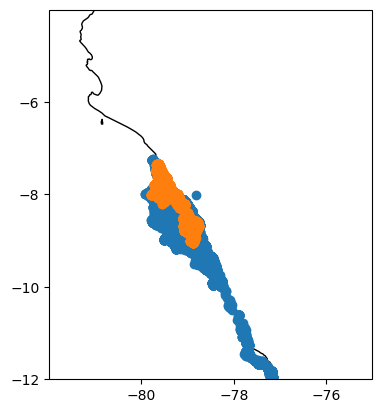

In [12]:
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs.lon,ds_obs.lat,'o')
plt.plot(ds_obs1.lon,ds_obs1.lat,'o')

ax.coastlines()
ax.set_xlim(-82,-75)
ax.set_ylim(-12,-4)
ax.set_xticks(np.arange(-80,-75,2), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-12,-4,2), crs=ccrs.PlateCarree())
# ax.legend(loc = "upper left")

## Define GEO box

In [13]:
ds_obs_peru_box = ds_obs.where((ds_obs.lon>x_geobox[0])&(ds_obs.lon<x_geobox[1])&(ds_obs.lat>y_geobox[0])&(ds_obs.lat<y_geobox[1]),drop=True)
ds_obs_peru_box

<xarray.Dataset>
Dimensions:   (t: 121540)
Coordinates:
  * t         (t) datetime64[ns] 2025-01-15T19:08:26 ... 2025-05-26T12:08:46....
Data variables:
    id        (t) float64 2.257e+05 2.257e+05 2.257e+05 ... 2.257e+05 2.257e+05
    accx      (t) float64 -94.0 14.0 -1.0 -275.0 39.0 ... 13.0 78.0 -74.0 -69.0
    accy      (t) float64 382.0 -759.0 -768.0 -781.0 ... -862.0 -899.0 -219.0
    accz      (t) float64 975.0 624.0 622.0 501.0 ... 327.0 491.0 413.0 826.0
    lon       (t) float64 -78.97 -78.97 -78.97 -78.97 ... -78.62 -78.62 -78.64
    lat       (t) float64 -8.566 -8.566 -8.566 -8.566 ... -9.14 -9.141 -9.15
    datatype  (t) object GPS GPS GPS GPS GPS GPS GPS ... GPS GPS GPS GPS GPS GPS

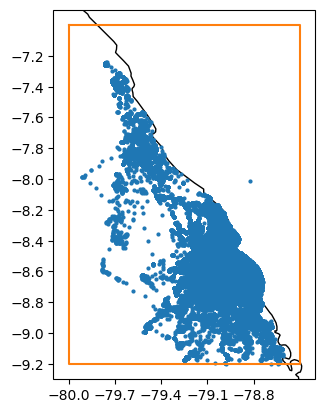

In [14]:
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs_peru_box.lon,ds_obs_peru_box.lat,'o',markersize=2)
plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])

ax.coastlines()
ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
ax.set_xticks(np.arange(x_geobox[0],x_geobox[1],0.3), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(y_geobox[0],y_geobox[1],0.2), crs=ccrs.PlateCarree())
# ax.legend(loc = "upper left")

## plotting locations by device id

### 1. find tag IDs and their locations

In [15]:
print( 'tags in the box:' , np.unique(ds_obs_peru_box.id))

tags in the box: [225660. 225661. 225663. 225665.]


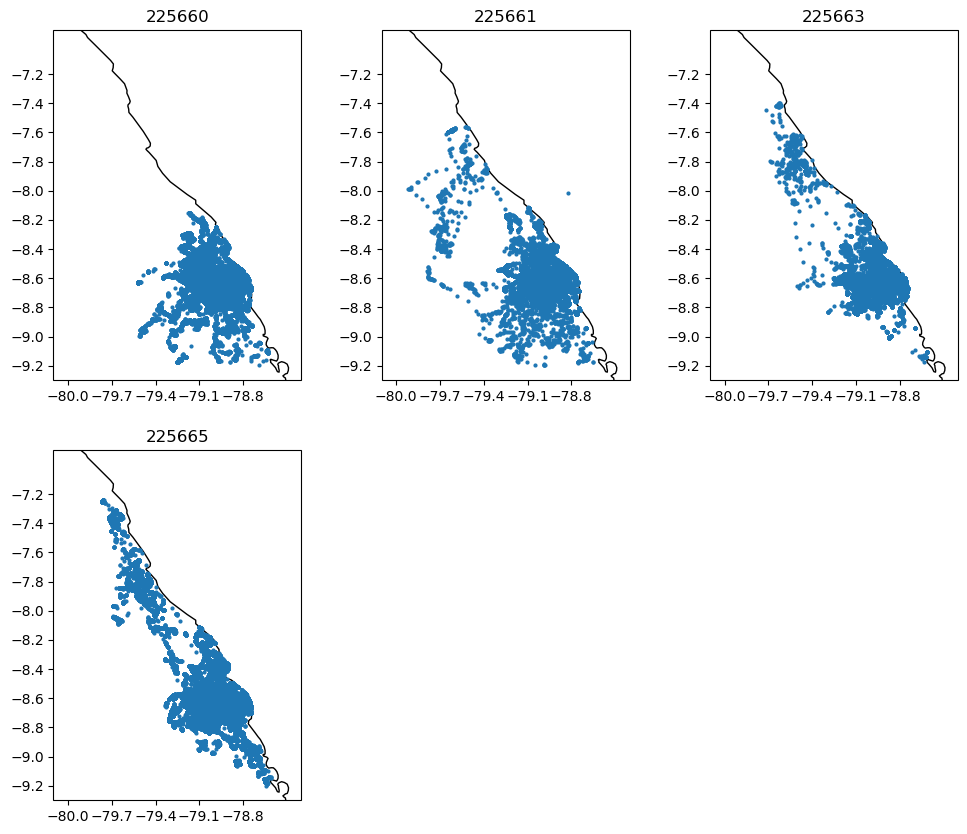

In [16]:
# ax = plt.axes(projection=ccrs.PlateCarree())
# plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])

# ax.coastlines()
# ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
# ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
fig = plt.figure(figsize=(12,10))
kk=1
for idnn in np.unique(ds_obs.id):
    ax = fig.add_subplot(2,3,kk,projection=ccrs.PlateCarree())
    kk = kk+1
    # plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])
    
    ax.coastlines()
    ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
    ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
    ax.set_xticks(np.arange(x_geobox[0],x_geobox[1],0.3), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(y_geobox[0],y_geobox[1],0.2), crs=ccrs.PlateCarree())
    plt.plot(ds_obs_peru_box.lon.where(ds_obs_peru_box.id==idnn),ds_obs_peru_box.lat,'o',markersize=2)
    plt.title(f'{idnn}')
    

### data in this region

In [17]:
for id in np.unique(ds_obs_peru_box.id):

    ds_obs_peru_box_singetag = ds_obs_peru_box.where(ds_obs_peru_box.id==id,drop=True)
    print(f'ID= {id} GPS signals {ds_obs_peru_box_singetag.accx.size}')

ID= 225660.0 GPS signals 34758
ID= 225661.0 GPS signals 22261
ID= 225663.0 GPS signals 17671
ID= 225665.0 GPS signals 46850


# Process all tags //// 

In [18]:
# Create a new integer coordinate
new_t = np.arange(len(ds_obs['t']))

# Optionally, store the original time as a data variable for reference
ds_obs = ds_obs.assign(original_time=('time_index', ds_obs['t'].values))

# Assign the new integer coordinate while keeping the original as a variable
ds_obs = ds_obs.assign_coords(t=new_t).rename({'t': 'time_index'})

# assign a new variable 'mask' (with NaNs)
ds_obs = ds_obs.assign(mask=(('time_index',), np.full(ds_obs.dims['time_index'], np.nan)))

In [19]:
len(ds_obs['time_index'])

5710996

In [20]:
# Create a new integer coordinate
new_t1 = np.arange(len(ds_obs1['t']))+len(ds_obs['time_index'])

# Optionally, store the original time as a data variable for reference
ds_obs1 = ds_obs1.assign(original_time=('time_index', ds_obs1['t'].values))

# Assign the new integer coordinate while keeping the original as a variable
ds_obs1 = ds_obs1.assign_coords(t=new_t1).rename({'t': 'time_index'})

# assign a new variable 'mask' (with NaNs)
ds_obs1 = ds_obs1.assign(mask=(('time_index',), np.full(ds_obs1.dims['time_index'], np.nan)))

In [21]:
ds_obs = xr.concat([ds_obs, ds_obs1], dim='time_index')

In [22]:
# add a new variable 'mask'. the values are 0,1,2,3,... for each gap (between GPS signals)
gps_indices_a = ds_obs.time_index.where(ds_obs.datatype == 'GPS', drop=True).values.astype(int)
# print(gps_indices[:400])

indices = [(i, j, j-i) for i, j in zip(gps_indices_a[:-1], gps_indices_a[1:]) if j - i > 10]
imask = 0
for idx in indices:
    # print(idx)
    ds_obs['mask'].loc[dict(time_index=slice(idx[0], idx[1]))] = imask
    imask = imask+1

print(f'total gaps between GPS: {imask}')

total gaps between GPS: 8128


In [23]:
## find tag location inside the [x_geobox, y_geobox] 

######
lon_lat_indices_1 = ds_obs.isel(time_index=np.array(indices)[:,0])
lon_lat_indices_1 = lon_lat_indices_1.assign_coords(index_local=("time_index", np.arange(len(lon_lat_indices_1["time_index"]))))

lon_lat_indices_2 = ds_obs.isel(time_index=np.array(indices)[:,1])
lon_lat_indices_2 = lon_lat_indices_2.assign_coords(index_local=("time_index", np.arange(len(lon_lat_indices_2["time_index"]))))

lon_lat_indices_1_in_box = lon_lat_indices_1.where(
    (lon_lat_indices_1.lon > x_geobox[0]) & (lon_lat_indices_1.lon < x_geobox[1]) &
    (lon_lat_indices_1.lat > y_geobox[0]) & (lon_lat_indices_1.lat < y_geobox[1]),
    drop=True
)
lon_lat_indices_2_in_box = lon_lat_indices_2.where(
    (lon_lat_indices_2.lon > x_geobox[0]) & (lon_lat_indices_2.lon < x_geobox[1]) &
    (lon_lat_indices_2.lat > y_geobox[0]) & (lon_lat_indices_2.lat < y_geobox[1]),
    drop=True
)
# lon_lat_indices_1_in_box

common_indices = np.intersect1d(lon_lat_indices_1_in_box.index_local, lon_lat_indices_2_in_box.index_local)

# print(lon_lat_indices_1_in_box.where(lon_lat_indices_1_in_box.index_local==common_indices[1],drop=True).time_index.values)
# print(lon_lat_indices_2_in_box.where(lon_lat_indices_2_in_box.index_local==common_indices[1],drop=True).time_index.values)
######
print(f'number of GPS signals in the box: {len(common_indices)}')


number of GPS signals in the box: 7571


In [24]:
np.unique(ds_obs.datatype)

array(['GPS', 'GPSD', 'GPSS', 'NOTE_DIVING', 'SEND_ALL2_1Hz_START_END',
       'SEND_ALL2_5Hz', 'SEND_ALL2_5Hz_END', 'SEND_ALL2_5Hz_START',
       'SEND_ALL_1Hz', 'SEND_ALL_1Hz_END', 'SEND_ALL_1Hz_START',
       'SEND_ALL_1Hz_START_END', 'SEND_ALL_5Hz', 'SEND_ALL_5Hz_END',
       'SEND_ALL_5Hz_START', 'SEN_ACC_5Hz', 'SEN_ACC_5Hz_END',
       'SEN_ACC_5Hz_ENDINT', 'SEN_ACC_5Hz_START', 'SEN_ALL_5Hz',
       'SEN_ALL_5Hz_END', 'SEN_ALL_5Hz_ENDINT', 'SEN_ALL_5Hz_START'],
      dtype=object)

10 (14531, 15252) 225660 -78.84529876708984 -8.543925285339355 -78.79754638671875 -8.557049751281738
11 (15252, 15743) 225660 -78.79754638671875 -8.557049751281738 -78.77991485595702 -8.628883361816406
12 (15743, 16510) 225660 -78.77991485595702 -8.628883361816406 -78.78689575195312 -8.660750389099121
13 (16510, 16586) 225660 -78.78689575195312 -8.660750389099121 -78.96578216552734 -8.567707061767578
14 (16597, 17853) 225660 -78.94004058837889 -8.599138259887695 -78.94307708740233 -8.658644676208496
15 (17853, 18314) 225660 -78.94307708740233 -8.658644676208496 -78.96807861328125 -8.56633472442627
16 (18339, 19118) 225660 -78.99421691894531 -8.347405433654785 -78.98587799072266 -8.333548545837402
17 (19118, 19279) 225660 -78.98587799072266 -8.333548545837402 -78.97128295898438 -8.331831932067871
18 (19279, 19691) 225660 -78.97128295898438 -8.331831932067871 -79.00323486328125 -8.361358642578125
19 (19716, 20456) 225660 -79.04627990722656 -8.627248764038086 -79.1129150390625 -8.70664501

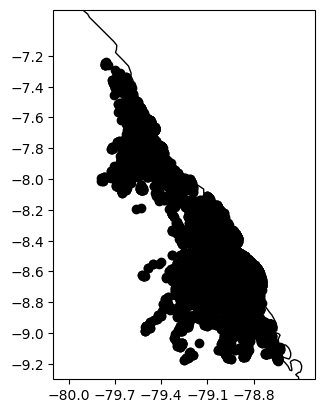

In [25]:
# add variable 'mask2' to ds_obs (sub chunks in a chunk between GPS signals)
# add variables 'x1', 'y1', 'x2', 'y2' to ds_obs (lon, lat of the GPS signals before and after the chunk)
# Define indices_inbox list
indices_inbox_a = []
ds_obs['mask2'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['x1'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['y1'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['x2'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
ds_obs['y2'] = xr.DataArray(np.zeros(ds_obs.dims['time_index']), dims='time_index')
imask = 0

ax = plt.axes(projection=ccrs.PlateCarree())
# first find the indices whose GPS location is in the box
# for idx in indices:
for idx2 in common_indices:
#     print(idx2)
    idx = (lon_lat_indices_1_in_box.where(lon_lat_indices_1_in_box.index_local==idx2,drop=True).time_index.values[0],
            lon_lat_indices_2_in_box.where(lon_lat_indices_2_in_box.index_local==idx2,drop=True).time_index.values[0])
    # p1 = ds_obs.isel(time_index=idx[0])
    p1 = ds_obs.isel(time_index=idx[0])
    p2 = ds_obs.isel(time_index=idx[1])

    # if (x_geobox[0] < p1.lon.values < x_geobox[1]) & (y_geobox[0] < p1.lat.values < y_geobox[1]) & \
    #    (x_geobox[0] < p2.lon.values < x_geobox[1]) & (y_geobox[0] < p2.lat.values < y_geobox[1]):
    #         indices_inbox_a.append(idx)
            # Check if records between idx[0] and idx[1] have the datatype SEN_ALL_1Hz_START and SEN_ALL_1Hz_END
    if 'SEN_ACC_5Hz' in ds_obs.datatype.isel(time_index=slice(idx[0], idx[1])).values:
        ds_obs['mask2'].loc[dict(time_index=slice(idx[0], idx[1]))] = xr.where(
            ds_obs.datatype.isin(['SEN_ACC_5Hz', 'SEN_ACC_5Hz_START', 'SEN_ACC_5Hz_END', 'SEN_ACC_5Hz_ENDINT']).loc[dict(time_index=slice(idx[0], idx[1]))],
            imask,
            ds_obs['mask2'].loc[dict(time_index=slice(idx[0], idx[1]))]
        )
        ds_obs['x1'].loc[dict(time_index=slice(idx[0], idx[1]))] = p1.lon.values
        ds_obs['y1'].loc[dict(time_index=slice(idx[0], idx[1]))] = p1.lat.values
        ds_obs['x2'].loc[dict(time_index=slice(idx[0], idx[1]))] = p2.lon.values
        ds_obs['y2'].loc[dict(time_index=slice(idx[0], idx[1]))] = p2.lat.values
        imask += 1
        print(idx2, idx,p1.id.values,p1.lon.values, p1.lat.values,p2.lon.values, p2.lat.values)
        plt.plot([p1.lon.values,p2.lon.values], [p1.lat.values,p2.lat.values],'ok')

ax.coastlines()
# ax.set_xlim(-125,-123)
# ax.set_ylim(44,47)
# ax.set_xticks(np.arange(-124.7,-124,0.3), crs=ccrs.PlateCarree())
# ax.set_yticks(np.arange(46,47,0.2), crs=ccrs.PlateCarree())
ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)
ax.set_xticks(np.arange(x_geobox[0],x_geobox[1],0.3), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(y_geobox[0],y_geobox[1],0.2), crs=ccrs.PlateCarree())
# ax.legend(loc = "upper left")

# for idx in indices:
#     # print(dfs.loc[idx[0]:idx[1]])
#     dfs_chunk = dfs.loc[idx[0]:idx[1]]
#     sen_start = dfs_chunk[(dfs_chunk['datatype'] == 'SEN_ALL_1Hz_START')]
#     sen_end = dfs_chunk[(dfs_chunk['datatype'] == 'SEN_ALL_1Hz_END')]
#     print(sen_start,sen_end)

#     if not sen_start.empty and not sen_end.empty:
#         chunk_acc = dfs_chunk.loc[sen_start.index[0]:sen_end.index[0]]
#         if 'chunk_acc' in locals():
#             chunk_acc = pd.concat([chunk_acc, dfs_chunk.loc[sen_start.index[0]:sen_end.index[0]]])
#         else:
#             chunk_acc = dfs_chunk.loc[sen_start.index[0]:sen_end.index[0]]

#  sub-chunks divided by START and END signals

In [26]:
### total number of chunks (THIS "chunk" is coarsely divided by GPS signals) in the box for acc data
len(np.unique(ds_obs.mask2))

7514

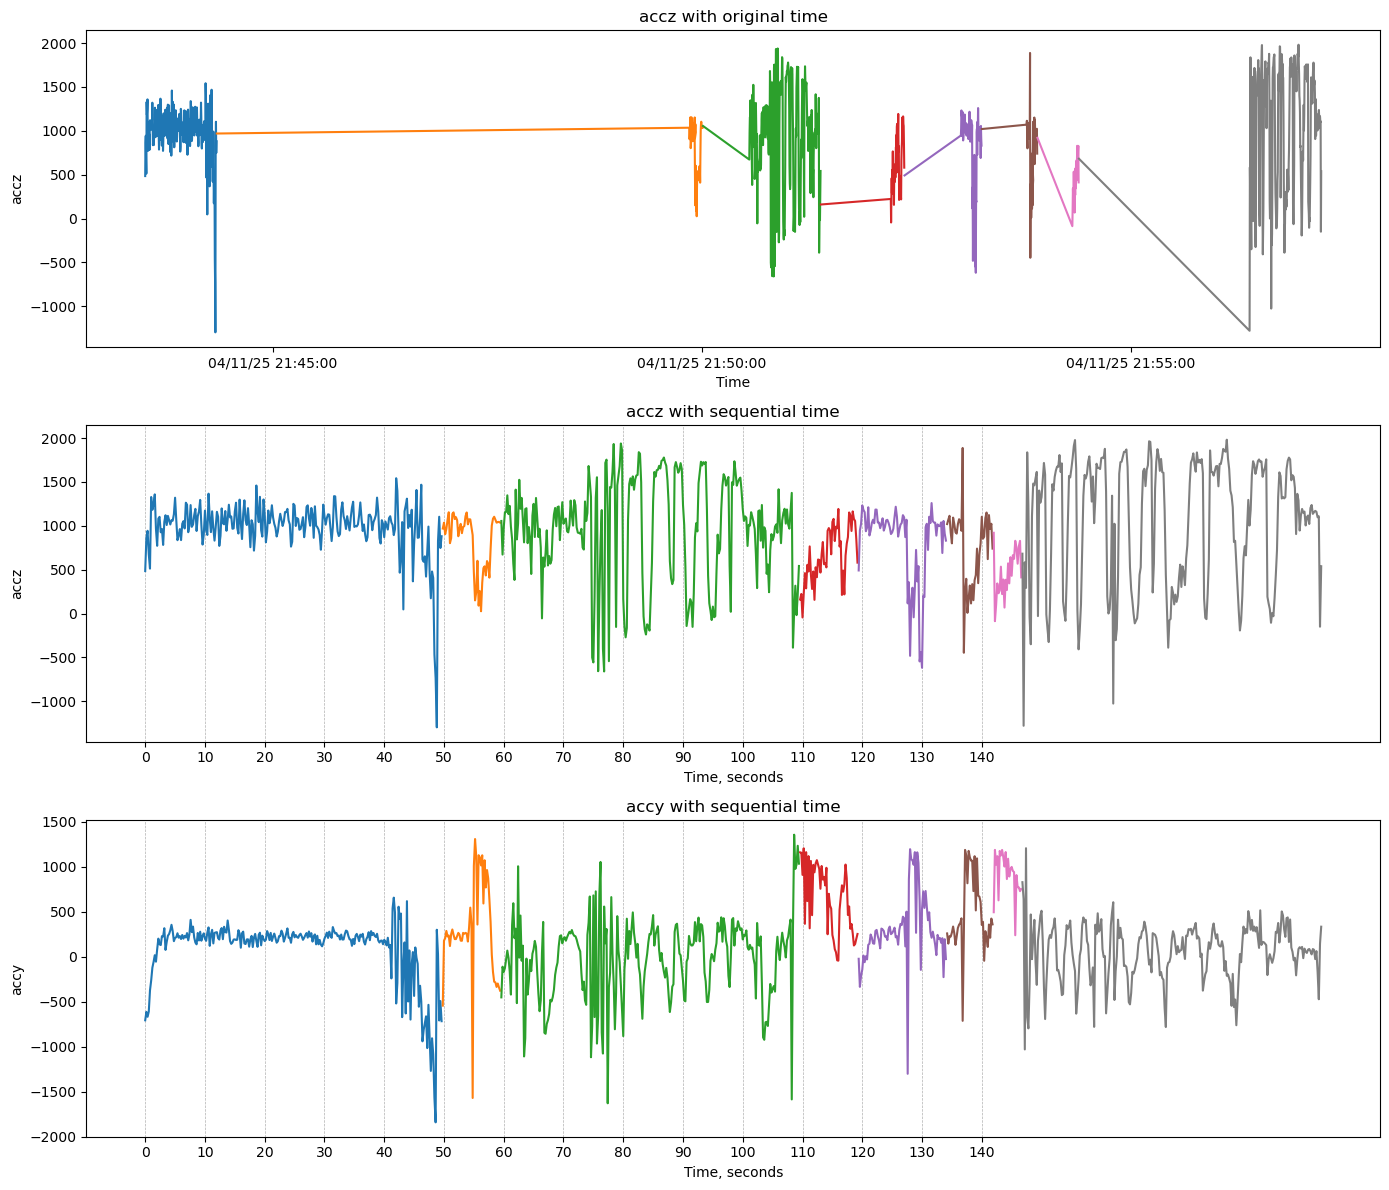

In [27]:
ik = 1000

data_chunk_8 = ds_obs.where(ds_obs.mask2 == ik + 1, drop=True)

# Calculate the time difference between consecutive points
time_diff = data_chunk_8.original_time.diff(dim='time_index').astype('timedelta64[s]')

# Find the indices where the time difference is greater than 2 seconds
cut_indices = np.where(time_diff > np.timedelta64(2, 's'))[0]

# Split the data_chunk_8 into pieces based on the cut_indices
data_pieces = [data_chunk_8.isel(time_index=slice(start, end)) for start, end in zip(np.r_[0, cut_indices], np.r_[cut_indices, len(data_chunk_8.time_index)])]

fig, axs = plt.subplots(3, 1, figsize=(14, 12))

# Plot accz with original time
colors = plt.cm.viridis(np.linspace(0, 1, len(data_pieces)))
for i, piece in enumerate(data_pieces):
    axs[0].plot(piece['original_time'], piece['accz'])
axs[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%D %H:%M:%S'))
axs[0].set_xlabel('Time')
axs[0].set_ylabel('accz')
axs[0].set_title('accz with original time')

# Plot accz with sequential time
xstart = 0
for i, piece in enumerate(data_pieces):
    axs[1].plot(np.arange(xstart, xstart + len(piece['original_time'])) / 5, piece['accz'])
    xstart = xstart + len(piece['original_time'])
axs[1].grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
axs[1].set_xticks(np.arange(0, 145, 10))
axs[1].set_xlabel('Time, seconds')
axs[1].set_ylabel('accz')
axs[1].set_title('accz with sequential time')

# Plot accy with sequential time
xstart = 0
for i, piece in enumerate(data_pieces):
    axs[2].plot(np.arange(xstart, xstart + len(piece['original_time'])) / 5, piece['accy'])
    xstart = xstart + len(piece['original_time'])
axs[2].grid(True, which='both', axis='x', linestyle='--', linewidth=0.5)
axs[2].set_xticks(np.arange(0, 145, 10))
axs[2].set_xlabel('Time, seconds')
axs[2].set_ylabel('accy')
axs[2].set_title('accy with sequential time')

plt.tight_layout()
plt.show()


# get Chunks by searching continous ACC singals in the box
# calculate general parameters of each chunk (record length, x,y, ...)

In [29]:
# Split the data_chunk_8 into pieces based on the cut_indices
# store the data longer than 40s in a pandas dataframe

data_length = []
data_time_length = []
data_time_length_df = pd.DataFrame(columns=["data_time_length", "mask_ik"])
data_40s_df = pd.DataFrame(columns=["mask_ik","accz","bird_id","lon","lat","original_time","chunk_id"])

# for ik in [8,9,10]:
ichunk_nogap=0
ichunk_nogap_20250211=0
# for ik in range(188,189):
for ik in np.unique(ds_obs.mask2)[1:]:

    if ik % 100 == 0:
        print(ik)

    data_chunk_8 = ds_obs.where(ds_obs.mask2 == ik, drop=True)

    # Calculate the time difference between consecutive points
    time_diff = data_chunk_8.original_time.diff(dim='time_index').astype('timedelta64[s]')

    # Find the indices where the time difference is greater than 2 seconds
    cut_indices = np.where(time_diff > np.timedelta64(2, 's'))[0]

    # Split the data_chunk_8 into pieces based on the cut_indices
    data_pieces = [data_chunk_8.isel(time_index=slice(start, end)) for start, end in zip(np.r_[0, cut_indices+1], np.r_[cut_indices+1, len(data_chunk_8.time_index)+1])]
    data_length = [len(piece['original_time']) for piece in data_pieces]
    data_time_length = [(piece['original_time'][-1].values - piece['original_time'][0].values).astype('timedelta64[s]') for piece in data_pieces]
    data_time = [piece['original_time'][0].values for piece in data_pieces]
    for i, piece in enumerate(data_pieces):
        # print(i,data_time_length[i])
        if data_time_length[i]>39:
            data_40s_df = pd.concat([data_40s_df, pd.DataFrame({"mask_ik": [ik]*(data_length[i]),
                                                                 "accz": piece['accz'].values,
                                                                 "accy": piece['accy'].values,
                                                                 "accx": piece['accx'].values,
                                                                 "bird_id": [data_chunk_8.id[0].values]*(data_length[i]),
                                                                 "lon":[piece['x1'][0].values]*(data_length[i]),
                                                                 "lat":[piece['y1'][0].values]*(data_length[i]),
                                                                 "original_time":piece['original_time'].values,
                                                                 "chunk_id":[ichunk_nogap]*(data_length[i])})], ignore_index=True)
        ichunk_nogap = ichunk_nogap+1
        if data_time[i]> pd.to_datetime('2025-2-11'):
            ichunk_nogap_20250211 = ichunk_nogap_20250211+1
    # print(len(data_time_length))
    # Store data_time_length in a xarray DataArray with mask_ik
    data_time_length_df = pd.concat([data_time_length_df, pd.DataFrame({"data_time_length": data_time_length,"original_time":data_time, "mask_ik": [ik] * len(data_time_length),"bird_id": [data_chunk_8.id[0].values]*len(data_time_length)})], ignore_index=True)

    # data_time_length = [(piece['original_time'][-1].values - piece['original_time'][0].values).astype('timedelta64[s]') for piece in data_pieces]
    # print(data_time_length)
    # data_length
    # data_time = [piece['original_time'] for piece in data_pieces]
    # for i, piece in enumerate(data_pieces):
    #     print(i, len(piece['original_time']), piece['original_time'][0], piece['original_time'][-1])


100.0
200.0
300.0
400.0
500.0
600.0
700.0
800.0
900.0
1000.0
1100.0
1200.0
1300.0
1400.0
1500.0
1600.0
1700.0
1800.0
1900.0
2000.0
2100.0
2200.0
2300.0
2400.0
2500.0
2600.0
2700.0
2800.0
2900.0
3000.0
3100.0
3200.0
3300.0
3400.0
3500.0
3600.0
3700.0
3800.0
3900.0
4000.0
4100.0
4200.0
4300.0
4400.0
4500.0
4600.0
4700.0
4800.0
4900.0
5000.0
5100.0
5200.0
5300.0
5400.0
5500.0
5600.0
5700.0
5800.0
5900.0
6000.0
6100.0
6200.0
6300.0
6400.0
6500.0
6600.0
6700.0
6800.0
6900.0
7000.0
7100.0
7200.0
7300.0
7400.0
7500.0


In [ ]:
# XXXXXXX
for i in data_40s_df["chunk_id"].unique():
    fig = plt.figure(figsize=(12,3),constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
    axs1 = fig.add_subplot(gs[0])
    axs2 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
    axs1.plot(data_40s_df[data_40s_df["chunk_id"]==i]['accz'].values,label='accz')
    axs1.plot(data_40s_df[data_40s_df["chunk_id"]==i]['accy'].values,label='accy')
    axs1.plot(data_40s_df[data_40s_df["chunk_id"]==i]['accx'].values,label='accx')
    axs1.set_ylim(-1000,2000)
    axs1.set_title(f'chunk_id={i},STD={np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values)}, MEAN_accz={np.mean(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values):.3f}, STD_accy={np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accy"].values):.3f}, STD_accx={np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accx"].values):.3f}')
    axs1.text(0,1700, f'{data_40s_df[data_40s_df["chunk_id"]==i]["original_time"].values[0]}')
    axs1.legend(loc='upper right')

    # axs2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
    axs2.plot(data_40s_df[data_40s_df["chunk_id"]==i]['lon'].iloc[0], data_40s_df[data_40s_df["chunk_id"]==i]['lat'].iloc[0], 'o')
    axs2.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
    axs2.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
    axs2.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
    axs2.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
    # ax2.set_xticks(np.arange(-124.7, -124, 0.3), crs=ccrs.PlateCarree())
    # ax2.set_yticks(np.arange(46, 47, 0.2), crs=ccrs.PlateCarree())
    axs2.coastlines()
    axs2.set_title('Location')
    axs2.set_xlabel('Longitude')
    axs2.set_ylabel('Latitude')
    
    plt.savefig(f'chunk_40s_225662/chunk_{i}.png')
    plt.close()

# Count GOOD data / total (by the STD of the chunks)

In [ ]:
# get standard deviation of accz for each chunk
time_accz = pd.DataFrame(columns=["time_accz","std_accz"])
for i in data_40s_df["chunk_id"].unique():
    std_accz=np.std(data_40s_df[data_40s_df["chunk_id"]==i]["accz"].values)
    time_accz = pd.concat([time_accz, pd.DataFrame({"time_accz": [data_40s_df[data_40s_df["chunk_id"]==i]['original_time'].iloc[0]],
                                                    "std_accz":std_accz})], ignore_index=True)

In [ ]:
# Group time_accz by date and count number of records in each group with std_accz < 400 (good data)
time_accz['date'] = time_accz['time_accz'].dt.date
filtered_time_accz = time_accz[time_accz['std_accz'] < 400]
grouped_time_accz = filtered_time_accz.groupby('date').size()
grouped_time_accz_total = time_accz.groupby('date').size()
grouped_time_accz_df = grouped_time_accz.reset_index(name='good data')
# Add the total count to the dataframe
grouped_time_accz_df['total'] = grouped_time_accz_df['date'].map(grouped_time_accz_total)
# grouped_time_accz_df['total'] = grouped_time_accz_total.values
print(grouped_time_accz_df)
# print(grouped_time_accz)
plt.bar(grouped_time_accz_df['date'], grouped_time_accz_df['total'], alpha=0.5, label='Total')
plt.bar(grouped_time_accz_df['date'], grouped_time_accz_df['good data'], label='STD_accz < 400')
plt.xticks(rotation=45)
plt.legend()
# plt.show()

## plot all the chunks longer than 40s, adding a map for the locations

In [ ]:
# Filter the data for the specific date
# just for 2025-02-18
filtered_chunks = data_40s_df[data_40s_df['original_time'].dt.date == datetime.date(2025, 2, 18)]

# Get the unique chunk IDs for the filtered data
unique_chunks = filtered_chunks['chunk_id'].unique()

# Plot the chunks
for chunk_id in unique_chunks:
    chunk_data = filtered_chunks[filtered_chunks['chunk_id'] == chunk_id]
    if np.std(chunk_data['accz'])<400: # only plot the data with std < 400 (good data)
        # plt.figure(figsize=(12, 4))
        # fig, axs = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
        fig = plt.figure(figsize=(14, 4), constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
        ax1 = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
        # Plot the acceleration data
        ax1.plot(chunk_data['original_time'], chunk_data['accz'], label='accz')
        ax1.plot(chunk_data['original_time'], chunk_data['accy'], label='accy')
        ax1.plot(chunk_data['original_time'], chunk_data['accx'], label='accx')
        ax1.set_title(f"Chunk ID: {chunk_id} on 2025-02-18, std= {np.std(chunk_data['accz'])}")
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Acceleration')
        ax1.set_ylim(-1000, 2000)
        ax1.legend()
        
        # Plot the position on the map
        # ax_map = axs[1]
        # Add topography contour
        ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10),extend='both', transform=ccrs.PlateCarree())
        plt.colorbar(ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10), transform=ccrs.PlateCarree()), pad=0.05, label='Depth (m)')
        ax_map.plot(chunk_data['lon'].iloc[0], chunk_data['lat'].iloc[0], 'ro')
        ax_map.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
        ax_map.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
        ax_map.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
        ax_map.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
        ax_map.coastlines()
        ax_map.set_title('Location')
        ax_map.set_xlabel('Longitude')
        ax_map.set_ylabel('Latitude')
        # plt.show()
        plt.savefig(f'chunk_plots/chunk_2025-02-18_{chunk_id}.png')
        plt.close()
    else: # save the chunks with std>400 (bad data)
        plt.figure(figsize=(12, 4))
        # fig, axs = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
        fig = plt.figure(figsize=(14, 4), constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
        ax1 = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
        # Plot the acceleration data
        ax1.plot(chunk_data['original_time'], chunk_data['accz'], label='accz')
        ax1.plot(chunk_data['original_time'], chunk_data['accy'], label='accy')
        ax1.plot(chunk_data['original_time'], chunk_data['accx'], label='accx')
        ax1.set_title(f"Chunk ID: {chunk_id} on 2025-02-18, std= {np.std(chunk_data['accz'])}")
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Acceleration')
        ax1.set_ylim(-1000, 2000)
        ax1.legend()
        
        # Plot the position on the map
        # ax_map = axs[1]
        # Add topography contour
        ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10),extend='both', transform=ccrs.PlateCarree())
        plt.colorbar(ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10), transform=ccrs.PlateCarree()), pad=0.05, label='Depth (m)')
        ax_map.plot(chunk_data['lon'].iloc[0], chunk_data['lat'].iloc[0], 'ro')
        ax_map.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
        ax_map.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
        ax_map.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
        ax_map.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
        ax_map.coastlines()
        ax_map.set_title('Location')
        ax_map.set_xlabel('Longitude')
        ax_map.set_ylabel('Latitude')
        # plt.show()
        plt.savefig(f'chunk_plots_2/chunk_2025-02-18_{chunk_id}.png')
        plt.close()
        # break

# for chunk > 100 s

In [34]:
icount=0
for chunk_id in data_40s_df.chunk_id.unique():
    # print(ik)
    # Display the rows for the first chunk_id in the dataframe
    chunk_data = data_40s_df[data_40s_df["chunk_id"]==chunk_id]
    
    # Display basic info about the chunk
    if len(chunk_data) > 500:

        # plt.figure(figsize=(12, 4))
        # fig, axs = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [3, 1]})
        fig = plt.figure(figsize=(14, 4), constrained_layout=True)
        gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
        ax1 = fig.add_subplot(gs[0])
        ax_map = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())
        # Plot the acceleration data
        ax1.plot(chunk_data['original_time'], chunk_data['accz'], label='accz')
        ax1.plot(chunk_data['original_time'], chunk_data['accy'], label='accy')
        ax1.plot(chunk_data['original_time'], chunk_data['accx'], label='accx')
        ax1.set_title(f"Chunk ID: {chunk_id} on {chunk_data['original_time'].values[0]}, std= {np.std(chunk_data['accz'])}")
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Acceleration')
        ax1.set_ylim(-1000, 2000)
        ax1.legend()
        
        # Plot the position on the map
        # ax_map = axs[1]
        # Add topography contour
        ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10),extend='both', transform=ccrs.PlateCarree())
        plt.colorbar(ax_map.contourf(lon_bath, lat_bath, depth_bath, levels=np.arange(-100,10,10), transform=ccrs.PlateCarree()), pad=0.05, label='Depth (m)')
        ax_map.plot(chunk_data['lon'].iloc[0], chunk_data['lat'].iloc[0], 'ro')
        ax_map.set_xlim(x_geobox[0] - 0.1, x_geobox[1] + 0.1)
        ax_map.set_ylim(y_geobox[0] - 0.1, y_geobox[1] + 0.1)
        ax_map.set_xticks(np.arange(x_geobox[0], x_geobox[1], 0.3))
        ax_map.set_yticks(np.arange(y_geobox[0], y_geobox[1], 0.2))
        ax_map.coastlines()
        ax_map.set_title('Location')
        ax_map.set_xlabel('Longitude')
        ax_map.set_ylabel('Latitude')
        # plt.show()
        plt.savefig(f'chunk_plots_100s_all_tags_v4/chunk_2025-06-27_{chunk_id}.png')
        plt.close()

# print(icount)


## Pick up good data from 100s chunks

### (1) load Era5 Hs and spectrum data

In [31]:
era5_wave = xr.open_dataset('ERA5-download/era5_wave_statistics_3parameters_202502_202505.nc')
era5_wave2 = xr.open_dataset('ERA5-download/era5_wave_parameters_202505.nc')
era5_wave3 = xr.open_dataset('ERA5-download/wave_parameters_2025_04_05_06.nc')
# era5_wave

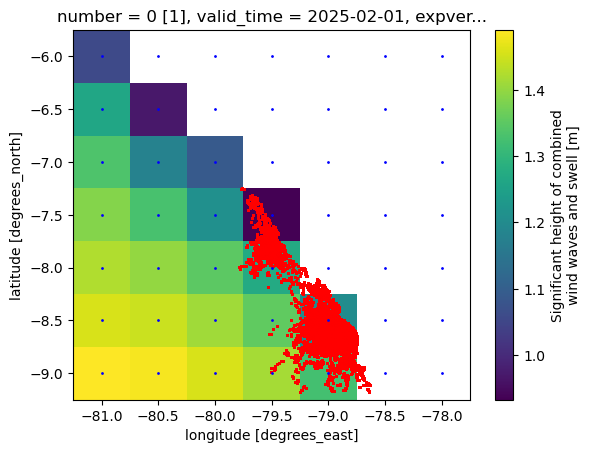

In [32]:
era5_wave.isel(valid_time=0).swh.plot()
plt.plot(data_40s_df['lon'], data_40s_df['lat'], 'o', color='red', markersize=1)

lon_era,lat_era = np.meshgrid(era5_wave.longitude.values, era5_wave.latitude.values)
plt.plot(lon_era, lat_era, 'o', color='blue', markersize=1)

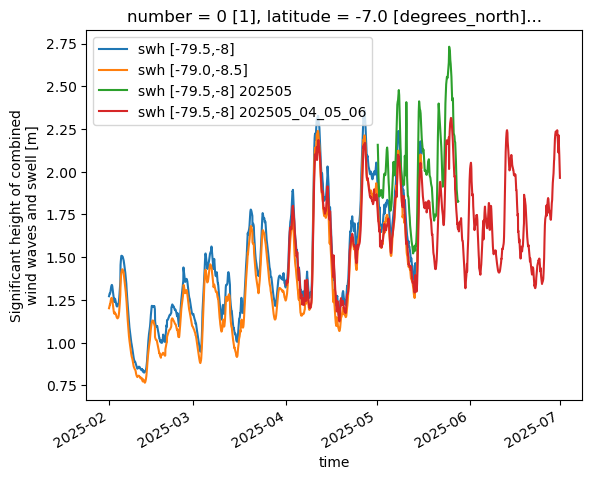

In [33]:
era5_wave.isel(longitude=3, latitude=4).swh.plot(label='swh [-79.5,-8]')
era5_wave.isel(longitude=4, latitude=5).swh.plot(label='swh [-79.0,-8.5]')
era5_wave2.isel(longitude=3, latitude=4).swh.plot(label='swh [-79.5,-8] 202505')
era5_wave3.isel(longitude=3, latitude=4).swh.plot(label='swh [-79.5,-8] 202505_04_05_06')
plt.legend()

In [35]:
spectrum2 = xr.open_dataset('ERA5-download/era5_wave_spectrum_20250501_20250620.nc')
spectrum2

<xarray.Dataset>
Dimensions:    (longitude: 5, latitude: 6, direction: 36, frequency: 29,
                time: 408)
Coordinates:
  * longitude  (longitude) float32 -82.0 -81.0 -80.0 -79.0 -78.0
  * latitude   (latitude) float32 -5.0 -6.0 -7.0 -8.0 -9.0 -10.0
  * direction  (direction) int32 1 2 3 4 5 6 7 8 9 ... 29 30 31 32 33 34 35 36
  * frequency  (frequency) int32 1 2 3 4 5 6 7 8 9 ... 22 23 24 25 26 27 28 29
  * time       (time) datetime64[ns] 2025-05-01 ... 2025-06-20T21:00:00
Data variables:
    d2fd       (time, frequency, direction, latitude, longitude) float32 ...
Attributes:
    Conventions:  CF-1.6
    history:      Tue Jul  8 12:14:19 2025: ncrcat era5_wave_spectrum_2025050...
    NCO:          netCDF Operators version 5.0.7 (Homepage = http://nco.sf.ne...

### (2) LOAD ERA5 spectrum  

In [36]:
np.full(30, 0.03453) * (1.1 ** np.arange(0, 30))

array([0.03453   , 0.037983  , 0.0417813 , 0.04595943, 0.05055537,
       0.05561091, 0.061172  , 0.0672892 , 0.07401812, 0.08141993,
       0.08956193, 0.09851812, 0.10836993, 0.11920693, 0.13112762,
       0.14424038, 0.15866442, 0.17453086, 0.19198394, 0.21118234,
       0.23230057, 0.25553063, 0.28108369, 0.30919206, 0.34011127,
       0.3741224 , 0.41153464, 0.4526881 , 0.49795691, 0.5477526 ])

In [180]:
# era5_wave_spectrum = xr.open_dataset('ERA5-download/era5_wave_spectrum_20250501_20250526.nc')

era5_wave_spectrum = xr.open_dataset('ERA5-download/era5_wave_spectrum_20250501_20250620_VER2_RIGHT.nc')


era5_wave_spectrum = era5_wave_spectrum.assign_coords(direction=np.arange(5, 355 + 10, 10))
era5_wave_spectrum = era5_wave_spectrum.assign_coords(frequency=np.full(29, 0.037983) * (1.1 ** np.arange(0, 29)))
# era5_peru.d2fd.values[0,:]

era5_wave_spectrum = 10 ** era5_wave_spectrum
era5_wave_spectrum = era5_wave_spectrum.fillna(0)
era5_wave_spectrum

<xarray.Dataset>
Dimensions:    (time: 408, frequency: 29, direction: 36, latitude: 6,
                longitude: 5)
Coordinates:
  * longitude  (longitude) float32 -82.0 -81.0 -80.0 -79.0 -78.0
  * latitude   (latitude) float32 -5.0 -6.0 -7.0 -8.0 -9.0 -10.0
  * direction  (direction) int64 5 15 25 35 45 55 65 ... 305 315 325 335 345 355
  * frequency  (frequency) float64 0.03798 0.04178 0.04596 ... 0.498 0.5478
  * time       (time) datetime64[ns] 2025-05-01 ... 2025-06-20T21:00:00
Data variables:
    d2fd       (time, frequency, direction, latitude, longitude) float32 0.0 ...
Attributes:
    Conventions:  CF-1.6
    history:      2025-05-29 21:54:54 GMT by grib_to_netcdf-2.35.3: /opt/ecmw...

In [181]:
era5_wave_spectrum_sum = era5_wave_spectrum.d2fd.sum(dim='direction')*(10/180*np.pi)

era5_wave_spectrum_sum_1pt = era5_wave_spectrum_sum.isel(longitude=2, latitude=3) # -80, -8
# era5_wave_spectrum_sum_1pt

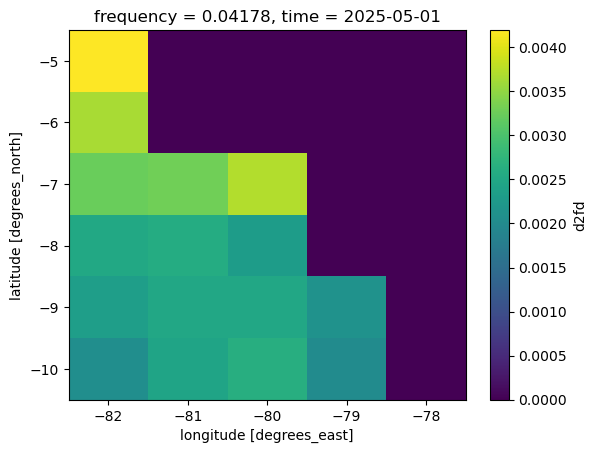

In [182]:
era5_wave_spectrum_sum.isel(frequency=1, time=0).plot()
# plt.plot(Hs_df['lon'], Hs_df['lat'], 'o', color='red', markersize=1)

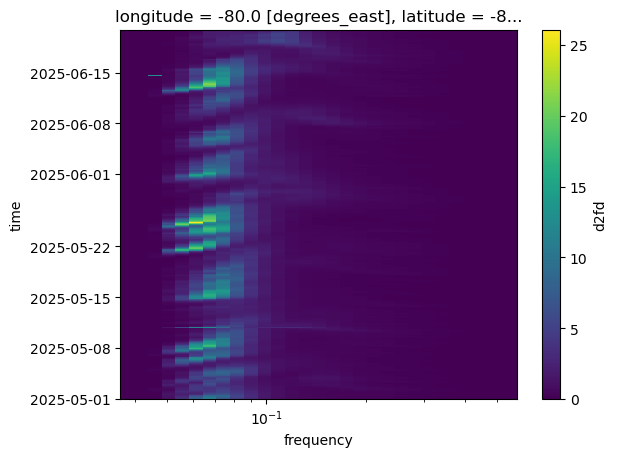

In [183]:
era5_wave_spectrum_sum.isel(longitude=2, latitude=3).plot(label='d2fd sum [-79.5,-8]')
plt.xscale('log')

## Cut the data larger than 1 min

In [ ]:
# era5_wave.isel(valid_time=0).swh.plot()
# plt.plot(Hs_df['lon'], Hs_df['lat'], 'o', color='red', markersize=1)

# lon_era,lat_era = np.meshgrid(era5_wave.longitude.values, era5_wave.latitude.values)
# plt.plot(lon_era, lat_era, 'o', color='blue', markersize=1)

In [ ]:
# era5_wave.isel(valid_time=0).swh.plot()
# plt.scatter(Hs_df_dmean['lon'], Hs_df['lat'],  s=15, c=Hs_df['Hs_band'],cmap='Reds')
# plt.colorbar(label='Hs from accz')

# lon_era,lat_era = np.meshgrid(era5_wave.longitude.values, era5_wave.latitude.values)
# plt.plot(lon_era, lat_era, 'o', color='blue', markersize=1)

## using records that are partially good

600


Text(0.5, 1.0, 'Chunk ID: 8110, Time: 2025-05-09T22:34:38.200000000')

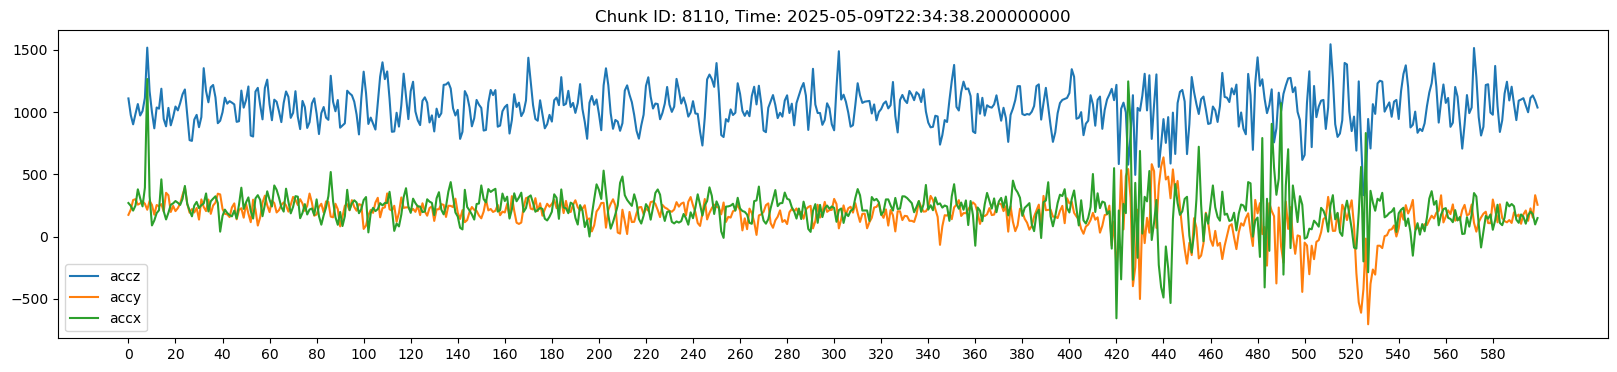

In [ ]:
# record list 
rec_list2_ok = [7502, 7581, 7583, 7673, 7740, 7872, 7883, 7887, 8053, 8109, 
               8110, 8155, 8212, 8289, 8291, 8297, 8326, 8378, 8422, 8621, 
               8622, 8697, 8739, 34616, 34921, 35092, 35100, 35156, 35171, 35510, 
               35519,35567, 35584, 35586, 35707, 35724, 36337, 36468, 36496, 
               36640, 36800, 7292, 7349, 7457, 7469, 7613, 7705, 7777, 7832,
               7849, 7856, 7884, 7991, 8034, 8056, 8077, 8146, 8154, 8160,
               8163, 8187, 8200, 8215, 8216, 8277, 8278, 8284, 8309, 8314,
               8315, 8441, 8443, 8444, 8449, 8453, 8503, 8517, 8519, 8525, 
               8538, 8585, 8612, 8615, 8616, 8618, 8627, 8628, 8630, 8631, 
               8632, 8634, 8655, 8660, 8691, 8738, 8745, 8747, 8760, 8762,
               8765, 8843, 8864, 8865, 8911, 8920, 45798, 46223, 46225, 46227,
               46232, 46238, 46240, 46251, 46259, 46261, 46266, 46268, 46270, 46296,
               46340, 46342, 46343, 46345, 46353, 46358, 46360, 46370, 46376, 46377,
               46392, 46393, 46400, 46402, 46410, 46426, 46427, 46429, 46431, 46432,
               46441, 46442, 46443, 46465, 46501, 46526, 46533, 46565, 46566, 46575,
               46618, 46680, 46755, 46781, 46783, 46794, 46808, 46820, 46822, 46823, #16
               46825, 46870, 46873, 46874, 46887, 46890, 46915, 46916, 46929, 46932,
               46952, 46953, 46965, 46995, 47003, 47007, 47018, 47026, 47034, 47051, #18 
               47055, 47070, 47071, 47073, 47075, 47079, 47083, 47099, 47100, 47104,
               47110, 47111, 47114, 47115, 47116, 47120, 47135, 47151, 47166, 47189, #20
               47193, 47204, 47205, 47212, 47216, 47239, 47244, 47296, 47300, 47324,
               47338, 47339, 47353, 47413, 47434, 47463, 47464, 47473, 47477, 47478, #22
               47543, 47546, 47547, 47551, 47555, 47556, 47596, 47622, 47655, 47661,
               8951, 8959, 8960, 8962, 8964, 8968, 8969, 8985, 9057, 
               9066, 9067, 9095, 9098, 9109, 9110, 9138, 9139, 9154, 9155, 
               9161, 9163, 9167, 9171, 9172, 9178, 9181, 9182, 9183, 9190, 
               9192, 9201, 9216, 9217, 9218, 9221, 9222, 9267, 9335, 9337, 
               9340, 9341, 9342, 9370, 9375, 9379, 9383, 9387, 9416, 9423, 
               9427, 9429, 9437, 9445, 9449, 9458, 9460, 9490, 9494, 9495, 
               9496, 9498, 9506, 9509, 9510, 9514, 9516, 9527, 9529, 9530, 
               9532, 9536, 9537, 9542, 9547, 9554, 9555, 9556, 9557, 9559, 
               9566, 9571, 9574, 9575, 9577, 9581, 9584, 9586, 9614, 9622, 
               9623, 9624, 9629, 9642, 9651, 9655, 9659, 9661, 9665, 9668, 
               9670, 9672, 9673, 9677, 9680, 9683, 9684, 9690, 9691, 9698, 
               9700, 9702, 9703, 9705, 9708, 9711, 9717, 9718, 9751, 9756, 
               9757, 9758, 9762, 9764, 9765, 9771, 9779, 9781, 9805, 9815, 
               9820, 9824, 9836, 9846, 9848, 9856, 9892, 9923, 9926, 9927, 
               9939, 9949, 9952, 10004, 10022, 10024, 10036, 10041, 10042, 10067, 
               10094, 10100, 10106, 10113, 10119, 10135, 10162, 10170, 10194, 10200, 
               10252, 10260, 10274, 10296, 10299, 10350, 10361, 10362, 10363, 10366,
               10372, 10374, 10389, 10392, 10403, 10423, 10431, 10438, 10445, 10455, 
               10465, 10474, 10497, 10500, 10519, 10521, 10525, 10536, 10539, 10541, 
               10547, 10554, 10557, 10562, 10563, 10568, 10595, 10596, 10597, 10599, 
               10606, 10607, 10610, 10611, 10652, 10654, 10659, 10664, 10665, 10669, 
               10674, 10693, 10712, 10714, 10719, 10751, 10829, 10902, 36801, 36818, 
               36888, 36904, 36910, 36911, 36999, 37019, 37032, 37050, 37053, 
               37069, 37083, 37163, 37168, 37202, 37204, 37209, 37246, 37256, 37386, 
               37413, 37414, 37429, 37474, 37546, 37549, 37582, 37597, 37603, 
               37605, 37669, 37684, 37693, 37716, 37767, 37769, 37783,  ]

rec_list2_ok_start = [0, 0, 70, 0, 0, 0, 20, 50, 0, 30, 
               10, 50, 100, 10, 300, 80, 60, 0, 0, 0, 
               30, 280, 0, 0, 0, 0, 20, 0, 0, 0, 
               0, 0, 0, 160, 0, 0, 10, 50, 10, 
               0, 0, 0, 75, 0, 0, 75, 225, 0, 0,
               0, 0, 220, 0, 0, 0, 0, 0, 80, 300,
               0, 250, 0, 0, 0, 280, 300, 75, 0, 100,
               200, 25, 200, 170, 75, 50, 100, 0, 0, 85,
               50, 200, 215, 225, 0, 125, 150, 160, 290, 100,
               150, 175, 200, 100, 50, 250, 100, 50, 85, 180,
               0, 300, 50, 50, 0, 70, 105, 300, 250, 225, 
               70,180, 225, 175, 110, 70, 90, 100, 250, 0, 
               50, 225, 160, 0, 200, 20, 100, 230, 90, 0,  #13
               0, 0, 75, 200, 125, 0, 0, 0, 130, 225,
               120, 175, 175, 0, 0, 50, 225, 225, 0, 0,
               120, 0, 290, 50, 285, 75, 250, 180, 220, 225, #16
               80, 0, 0, 175, 225, 0, 0, 300, 175, 75,
               0, 0, 260, 80, 0, 0, 0, 150, 200, 0, #18
               0, 200, 300, 160, 180, 200, 80, 180, 30, 40,
               200, 0, 60, 140, 120, 0, 0, 300, 0, 25,       #20
               0, 150, 0, 100, 0, 0, 240, 0, 200, 175,
               0, 275, 75, 240, 0, 100, 130, 180, 0, 200,    #22
               0, 250, 0, 150, 0, 100, 50, 160, 200, 0,
               50, 175, 150, 0, 0, 300, 0, 0, 0, 
               125, 225, 75, 300, 25, 0, 150, 50, 100, 70,
               0, 250, 50, 190, 0, 0, 150, 200, 0, 250, 
               0, 0, 75, 60, 0, 125, 25, 0, 75, 175, 
               200, 275, 220, 150, 0, 0, 200, 0, 0, 125, 
               25, 0, 0, 50, 150, 225, 50, 125, 0, 0, 
               75, 0, 225, 200, 50, 200, 200, 0, 265, 250, 
               25, 200, 200, 135, 165, 125, 250, 0, 0, 275, 
               175, 0, 0, 250, 150, 60, 0, 75, 125, 150, 
               25, 275, 275, 175, 0, 125, 290, 140, 0, 250, 
               75, 275, 0, 25, 0, 80, 225, 25, 0, 0, 
               0, 0, 0, 0, 0, 15, 50, 100, 50, 0, 
               40, 10, 125, 250, 50, 0, 0, 225, 265, 25, 
               0, 0, 0, 120, 200, 0, 90, 300, 10, 150, 
               120, 0, 170, 40, 160, 0, 0, 220, 0, 250, 
               0, 0, 120, 200, 0, 210, 0, 160, 120, 120, 
               20, 20, 220, 130, 200, 160, 50, 20, 230, 50, 
               0, 260, 0, 40, 220, 60, 140, 140, 0, 160,
               0, 170, 220, 270, 0, 90, 30, 170, 0, 280, 
               80, 10, 0, 80, 20, 0, 0, 170, 240, 0, 
               40, 0, 0, 0, 0, 0, 80, 0, 0, 0, 
               0, 10, 260, 20, 190, 120, 0, 120, 80, 0, 
               0, 190, 80, 170, 60, 20, 100, 110, 50, 
               180, 190, 130, 90, 160, 0, 190, 150, 120, 0, 
               60, 60, 220, 0, 260, 80, 0, 40, 270, 
               0, 140, 0, 210, 160, 80, 220, 60, ]
rec_list2_ok_end = [600, 450, 506, 340, 340, 580, 600, 470, 490, 440, 
               410, 540, 600, 600, 600, 600, 380, 540, 400, 600, 
               600, 600, 600, 600, 600, 600, 420, 600, 600, 540, 
               600, 600, 460, 600, 340, 600, 520, 600, 600, 
               600, 600, 525, 375, 310, 375, 375, 530, 350, 310,
               325, 450, 600, 480, 330, 350, 390, 400, 460, 600,
               325, 600, 310, 475, 550, 600, 600, 425, 450, 425,
               525, 350, 560, 600, 475, 575, 550, 600, 350, 410, 
               500, 500, 515, 600, 550, 400, 500, 480, 600, 600,
               580, 600, 580, 425, 450, 575, 450, 475, 600, 480,
               325, 600, 425, 600, 300, 375, 470, 600, 600, 600, 
               600, 600, 600, 575, 460, 425, 560, 510, 600, 310,
               475, 600, 600, 600, 600, 600, 600, 600, 490, 525, #13
               390, 400, 525, 600, 450, 470, 560, 375, 450, 550,
               450, 510, 530, 500, 325, 600, 600, 600, 550, 400,
               450, 600, 600, 350, 600, 500, 600, 600, 560, 600, #16
               475, 325, 410, 600, 600, 600, 600, 600, 600, 600,
               600, 320, 600, 540, 600, 450, 500, 600, 600, 425, #18 
               425, 600, 600, 600, 600, 600, 475, 600, 575, 475,
               600, 600, 525, 600, 525, 500, 500, 600, 475, 500, #20
               600, 575, 600, 600, 575, 600, 575, 450, 600, 600,
               400, 600, 525, 600, 350, 525, 600, 600, 560, 500, #22
               450, 600, 425, 600, 425, 600, 600, 600, 600, 500, 
               600, 600, 550, 340, 600, 600, 500, 300, 330, 
               500, 550, 600, 600, 400, 350, 600, 525, 550, 380,
               310, 600, 400, 550, 475, 400, 600, 600, 510, 600, 
               410, 600, 600, 475, 580, 525, 400, 350, 525, 600,
               600, 586, 530, 600, 580, 600, 575, 600, 475, 600, 
               600, 500, 475, 450, 460, 600, 370, 500, 425, 600, 
               600, 600, 575, 570, 375, 600, 600, 475, 565, 600,
               350, 600, 600, 600, 600, 550, 600, 600, 305, 600, 
               575, 600, 500, 600, 490, 600, 300, 450, 600, 600, 
               475, 600, 580, 475, 596, 600, 600, 600, 360, 600, 
               600, 600, 340, 600, 550, 600, 600, 375, 301, 375,
               425, 600, 500, 600, 325, 400, 575, 425, 550, 440, 
               600, 600, 460, 580, 600, 410, 350, 600, 580, 405,
               350, 420, 540, 600, 600, 370, 440, 600, 520, 600, 
               600, 600, 600, 460, 600, 500, 540, 600, 520, 600, 
               600, 400, 520, 600, 580, 600, 360, 600, 600, 600, 
               390, 600, 600, 600, 600, 600, 500, 480, 600, 390, 
               550, 600, 600, 400, 600, 500, 560, 520, 370, 600,
               600, 600, 580, 600, 600, 550, 360, 600, 600, 600, 
               600, 600, 510, 600, 600, 490, 600, 600, 600, 560, 
               600, 600, 340, 600, 350, 600, 530, 310, 500, 440, 
               570, 410, 600, 521, 600, 540, 600, 510, 600, 360, 
               500, 570, 600, 490, 540, 600, 600, 600, 600, 
               600, 550, 530, 520, 500, 600, 570, 600, 600, 600, 
               530, 600, 600, 360, 600, 490, 420, 600, 600, 
               320, 560, 600, 575, 600, 410, 600, 470, ]

# chunk_id = rec_list2_ok[229]   
chunk_id = 8110
chunk_data = data_40s_df[data_40s_df["chunk_id"] == chunk_id]

# Plot the acceleration data
fig = plt.figure(figsize=(20, 4))
ax = plt.gca()  # Get current axes
print(len(chunk_data))
plt.plot(range(len(chunk_data)), chunk_data['accz'], label='accz')
plt.plot(range(len(chunk_data)), chunk_data['accy'], label='accy')
plt.plot(range(len(chunk_data)), chunk_data['accx'], label='accx')
ax.set_xticks(np.arange(0, len(chunk_data), 20))
plt.legend()
plt.title(f'Chunk ID: {chunk_id}, Time: {chunk_data["original_time"].values[0]}')

In [ ]:
### For reformatting the array output
# XXXXXXXXXXXXX

def format_array(arr, first_line_items=4, other_lines_items=10):
    """Format an array with specified number of elements in first line and other lines."""
    result = []
    
    # Handle first line specially
    first_chunk = arr[:first_line_items]
    result.append(", ".join(map(str, first_chunk)))
    
    # Handle remaining lines
    for i in range(first_line_items, len(arr), other_lines_items):
        chunk = arr[i:i+other_lines_items]
        result.append(", ".join(map(str, chunk)))
    
    return "[\n" + ",\n".join(result) + "\n]"

# Use the function to display rec_list2_ok with 4 elements in first line, 10 in others
formatted_array = format_array(np.array([42804, 43229, 43231, 43233, 
             43238, 43244, 43246, 43257, 43265, 43267, 43272, 43274, 43276, 43302, 
             43346, 43348, 43349, 43351, 43359, 43364, 43366, 43376, 43382, 43383, 
             43398, 43399, 43406, 43408, 43416, 43432, 43433, 43435, 43437, 
             43438, 43447, 43448, 43449, 43471, 43507, 43532, 43539, 43571, 43572, 
             43581, 43624, 43686, 43761, 43787, 43789, 43800, 43814, 43826, 43828, 
             43829, 43831, 43876, 43879, 43880, 43893, 43896, 43921, 43922, 43935, 
             43938, 43958, 43959, 43971, 44001, 44009, 44013, 44024, 44032, 44040, 
             44057, 44061, 44076, 44077, 44079, 44081, 44085, 44089, 44105, 44106, 
             44110, 44116, 44117, 44120, 44121, 44122, 44126, 44141, 44157, 44172, 
             44195, 44199, 44210, 44211, 44218, 44222, 44245, 44250, 44302, 44306, 
             44330, 44344, 44345, 44359, 44419, 44440, 44469, 44470, 44479, 44483, 
             44484, 44549, 44552, 44553, 44557, 44561, 44562, 44602, 44628, 44661, 
             44667])+2994, first_line_items=4, other_lines_items=10)

print(formatted_array)

formatted_array2 = format_array(np.array([390, 400, 525, 600, 450, 470, 560, 375, 450, 
                 550, 450, 510, 530, 500, 325, 600, 600, 600, 550, 
                 400, 450, 600, 600, 350, 600, 500, 600, 600, 560,
                 600, 475, 325, 410, 600, 600, 600, 600, 600, 600,
                 600, 600, 320, 600, 500, 600, 450, 500, 600, 600, 
                 425, 425, 600, 600, 600, 600, 600, 475, 600, 575,
                 475, 600, 600, 525, 600, 525, 500, 500, 600, 475,
                 500, 600, 575, 600, 600, 575, 600, 575, 450, 600, 
                 600, 400, 600, 525, 600, 350, 525, 600, 600, 550,
                 500, 450, 600, 425, 600, 425, 600, 600, 600, 600, 
                 500]), first_line_items=10, other_lines_items=10)

print(formatted_array2)

In [409]:
# chunk_id = rec_list2[2]
# print(chunk_id) 

icount = 0
for chunk_id in rec_list2_ok:

    fig = plt.figure(figsize=(20, 4))

    chunk_data = data_40s_df[data_40s_df["chunk_id"] == chunk_id]

    # Plot the acceleration data
    # plt.plot(chunk_data['original_time'], chunk_data['accz'], label='accz')
    # plt.plot(chunk_data['original_time'], chunk_data['accy'], label='accy')
    # plt.plot(chunk_data['original_time'], chunk_data['accx'], label='accx')

    plt.plot(np.arange(len(chunk_data)), chunk_data['accz'], label='accz', color='tab:blue')
    plt.plot(np.arange(rec_list2_ok_start[icount], rec_list2_ok_end[icount]),
             chunk_data['accz'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]], 
              color='tab:orange')
    plt.plot(np.arange(len(chunk_data)), chunk_data['accy'], label='accy',color='skyblue')
    plt.plot(np.arange(rec_list2_ok_start[icount], rec_list2_ok_end[icount]),
             chunk_data['accy'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]], 
              color='blue')
    plt.plot(np.arange(len(chunk_data)), chunk_data['accx'], label='accx',color='pink')
    plt.plot(np.arange(rec_list2_ok_start[icount], rec_list2_ok_end[icount]),
             chunk_data['accx'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]], 
              color='tab:red')
    plt.legend()
    plt.title(f'Chunk ID: {chunk_id}, Time: {chunk_data["original_time"].values[0]}, length: {len(chunk_data)}')
    fig.savefig(f'chunk_plots_100s_all_tags_v4/cut_001/chunk_raw_{chunk_id}.png')
    plt.close()
    icount += 1

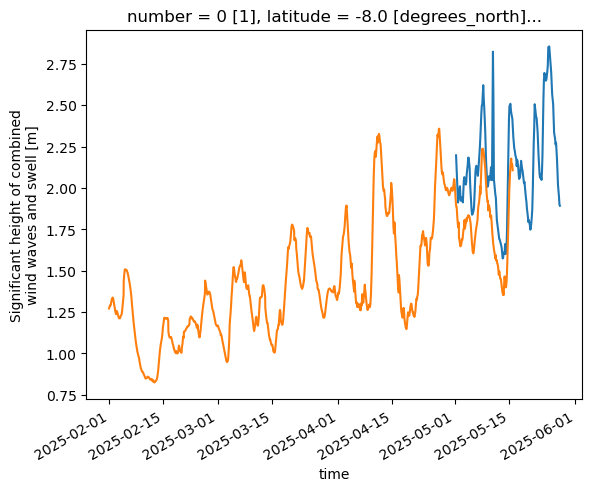

In [44]:
era5_wave2.isel(longitude=2, latitude=3).swh.plot()
era5_wave.isel(longitude=3, latitude=4).swh.plot()

## backup code for plotting chunks
## XXXXXXXXXX

In [ ]:
# swh_era5_1pt = era5_wave.isel(longitude=3, latitude=4)
# swh_era5_1pt2 = era5_wave.isel(longitude=4, latitude=5)
swh_era5_2 = era5_wave2.isel(longitude=2, latitude=3)

# from scipy.signal import welch
sample_rate = 5
order=4
icount=0
for i in rec_list2_ok:
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]

    # if (np.max(chunk00['accz'].values)<1500)&(np.min(chunk00['accz'].values)>500):
    accz_1 = chunk00["accz"].values/1000*9.81
    accx_1 = chunk00["accx"].values/1000*9.81
    accy_1 = chunk00["accy"].values/1000*9.81
    accz_1_sub = chunk00['accz'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accx_1_sub = chunk00['accx'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accy_1_sub = chunk00['accy'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    t_acc = np.arange(len(accz_1))/5
    accx_rotated_nosmoo,accy_rotated_nosmoo,accz_rotated_nosmoo = rotation_3d(accx_1_sub, accy_1_sub, accz_1_sub)
    # accx_rotated, accy_rotated,accz_rotated,_ = analyze_chunk_with_rotation(chunk00, fs=5, plot=False)

    # accz_1_detrended = signal.detrend(accz_rotated[50:-51])
    # accx_1_detrended = signal.detrend(accx_rotated[50:-51])
    # accy_1_detrended = signal.detrend(accy_rotated[50:-51])
    f_accz_ro0, Pxx_accz_ro0 = power_spectral_density_fft(signal.detrend(accz_rotated_nosmoo))
    f_accx_ro0, Pxx_accx_ro0 = power_spectral_density_fft(signal.detrend(accx_rotated_nosmoo))
    f_accy_ro0, Pxx_accy_ro0 = power_spectral_density_fft(signal.detrend(accy_rotated_nosmoo))

    f_accz_detrend, Pxx_accz_detrend = power_spectral_density_fft(signal.detrend(accz_1_sub))
    f_accx_detrend, Pxx_accx_detrend = power_spectral_density_fft(signal.detrend(accz_1_sub))
    f_accy_detrend, Pxx_accy_detrend = power_spectral_density_fft(signal.detrend(accz_1_sub))

    # Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
    # Pxx_z_eta = np.where(f_accz>0, Pxx_z_eta, 0)
    Pxx_z_eta_ro0 = Pxx_accz_ro0/(2*np.pi*f_accz_ro0)**4
    Pxx_z_eta_ro0 = np.where(f_accz_ro0>0, Pxx_z_eta_ro0, 0)
    Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_d = np.where(f_accz_detrend>0, Pxx_z_eta_d, 0)

    Pxx_accz_whitenoise = Pxx_accz_detrend*0+ 0.1
    Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_whitenoise = np.where(f_accz_detrend>0, Pxx_z_eta_whitenoise, 0)

    Pxx_accz_dewhitenoise = Pxx_z_eta_ro0-Pxx_z_eta_whitenoise
    # Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
    # Pxx_x_eta = np.where(f_accx>0, Pxx_x_eta, 0)
    Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
    Pxx_x_eta_d = np.where(f_accx_detrend>0, Pxx_x_eta_d, 0)
    # Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
    # Pxx_y_eta = np.where(f_accy>0, Pxx_y_eta, 0)
    Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4
    Pxx_y_eta_d = np.where(f_accy_detrend>0, Pxx_y_eta_d, 0)
    # mwp_chunk = ds_era5_hor_may01.mwp.sel(longitude=chunk00['lon'].iloc[0], latitude=chunk00['lat'].iloc[0], valid_time=chunk00["original_time"].values[0], method='nearest').values
    # mwp_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    # swh_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    # mwd_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values
    # mwp_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    # swh_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    # mwd_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    # if chunk00.iloc[0].original_time>pd.to_datetime('2025-05-15T23:00:00'):
    #     mwp_chunk = swh_era5_2.sel(time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    #     swh_chunk = swh_era5_2.sel(time = chunk00.iloc[0].original_time,method='nearest').swh.values
    #     mwd_chunk = swh_era5_2.sel(time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    # spectrum_chunk = era5_peru_mean.sel(time=chunk00.iloc[0].original_time,method='nearest')
    spectrum_chunk = era5_wave_spectrum_sum_1pt.sel(time=chunk00.iloc[0].original_time,method='nearest')

    # diff_accz_rolling_avg = pd.Series(accz_rotated[50:-50]-accz_1[50:-50]).rolling(50,center=True).mean()
    # diff_accz_rolling_avg = diff_accz_rolling_avg.values
    # diff_accx_rolling_avg = pd.Series(accx_rotated[50:-50]-accx_1[50:-50]).rolling(50,center=True).mean()
    # diff_accx_rolling_avg = diff_accx_rolling_avg.values
    # diff_accy_rolling_avg = pd.Series(accy_rotated[50:-50]-accy_1[50:-50]).rolling(50,center=True).mean()
    # diff_accy_rolling_avg = diff_accy_rolling_avg.values
    if icount == 0:
        PSD_acc = [Pxx_accz_detrend]
        f_accz_all = [f_accz_detrend]
        PSD_eta = [Pxx_z_eta_d]
        PSD_eta_ro0 = [Pxx_z_eta_ro0]
        t_april = [chunk00['original_time'].iloc[0]]
        x_april = [chunk00['lon'].iloc[0]]
        y_april = [chunk00['lat'].iloc[0]]
        mwp_all = [mwp_chunk]
        swh_all = [swh_chunk]
        mwd_all = [mwd_chunk]
        mwp_all2 = [mwp_chunk2]
        swh_all2 = [swh_chunk2]
        mwd_all2 = [mwd_chunk2]
        chunk_id_all = [i]
    else:
        PSD_acc.append(Pxx_accz_detrend)
        f_accz_all.append(f_accz_detrend)
        PSD_eta.append(Pxx_z_eta_d)
        PSD_eta_ro0.append(Pxx_z_eta_ro0)
        t_april.append(chunk00['original_time'].iloc[0])
        x_april.append(chunk00['lon'].iloc[0])
        y_april.append(chunk00['lat'].iloc[0])
        mwp_all.append(mwp_chunk)
        swh_all.append(swh_chunk)
        mwd_all.append(mwd_chunk)
        mwp_all2.append(mwp_chunk2)
        swh_all2.append(swh_chunk2)
        mwd_all2.append(mwd_chunk2)
        chunk_id_all.append(i)
    icount += 1

    fig = plt.figure(figsize=(12,3),constrained_layout=True)

    gs = fig.add_gridspec(1, 3, width_ratios=[3, 1, 1])
    axs1 = fig.add_subplot(gs[0,0])
    axs2 = fig.add_subplot(gs[0,1])
    axs3 = fig.add_subplot(gs[0,2])
    axs1.plot(np.arange(len(accz_1_sub))/5,accz_1_sub,label = 'RAW accz')
    # axs1.plot(np.arange(len(accz_1[50:-51]))/5,accz_rotated[50:-51],label = 'Rotated accz')
    # axs1.plot(t_acc[50:-50],accz_rotated[50:-50]-accz_1[50:-50],label = 'diff accz')
    # axs1.plot(t_acc[50:-50],diff_accz_rolling_avg,label = 'diff accz rolling avg')
    axs1.set_xlabel('Time [s]')
    axs1.set_ylabel('accz [m/s^2]')
    axs1.legend()
    axs1.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    # axs1.set_ylim(-1,2)

    # axs2.plot(f_accz, Pxx_accz,label='Rotated accz (FFT)')
    axs2.plot(f_accz_detrend, Pxx_accz_detrend,label='Non-rot accz (FFT)')
    axs2.plot(f_accz_ro0, Pxx_accz_ro0,'r',label='Non-rot accz (FFT rotated)')
    axs2.plot(f_accz_detrend, Pxx_accz_whitenoise,'g',label='Non-rot accz (FFT rotated)')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs2.axvline(x=0.05, color='r', linestyle='--')
    axs2.axvline(x=0.2, color='r', linestyle='--')
    # axs2.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs2.set_xscale('log')
    axs2.set_xlabel('Freq [Hz]')
    axs2.set_ylabel('Power spectral density [acc**2/Hz]')
    axs2.set_title(f'SH = {swh_chunk:.2f} m')
    axs2.set_ylim(0,8)
    # axs2.set_yscale('log')
    axs2.legend()
    # axs22 = axs2.twinx()
    # axs2.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'g',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs22.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    # axs3.plot(f_accz, Pxx_z_eta,label='PSD eta')
    axs3.plot(f_accz_detrend, Pxx_z_eta_d,label='FFT eta')
    axs3.plot(f_accz_ro0, Pxx_z_eta_ro0,'r',label='FFT eta rotated')
    axs3.plot(f_accz_detrend, Pxx_accz_dewhitenoise,'g',label='FFT eta whitenoise')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs3.axvline(x=0.05, color='r', linestyle='--')
    axs3.axvline(x=0.2, color='r', linestyle='--')
    # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--',linewidth=2)
    # axs3.plot(da.frequency, mean_power[0].values,color = 'orange',label='mean_power')
    axs3.plot(spectrum_chunk.frequency, spectrum_chunk,color='orange',label='era5 spectrum')
    # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs3.axhline(y=swh_chunk**2, color='b', linestyle='--', label='swh',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs3.set_xscale('log')
    axs3.set_xlabel('Freq [Hz]')
    axs3.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs3.set_yscale('log')
    axs3.set_ylim(0,50)
    axs3.legend()
    fig.savefig(f'chunk_frequency_100s_all_tags_v3/add_rotation/chunk_spectrum_accz_{i}.png')
    plt.close()

Mean acceleration: x = 2.0550, y = 2.5934, z = 10.1119
Mean vector: [ 2.05498245  2.59342065 10.1118537 ], norm: 10.639472204383923
Rotation axis: [ 0.24375463 -0.19314703  0.        ], norm: 0.31100176268790886
Rotation angle: 18.12 degrees
Mean before rotation: x = 2.0550, y = 2.5934, z = 10.1119
Mean after rotation: x = 0.0000, y = 0.0000, z = 10.6395


/tmp/ipykernel_974960/2351636085.py:36: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_ro0 = Pxx_accz_ro0/(2*np.pi*f_accz_ro0)**4
/tmp/ipykernel_974960/2351636085.py:38: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_974960/2351636085.py:42: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_974960/2351636085.py:48: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
/tmp/ipykernel_974960/2351636085.py:52: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4


Mean acceleration: x = 2.6419, y = 1.9803, z = 10.1390
Mean vector: [ 2.6419202  1.9803338 10.1390056], norm: 10.663062358413827
Rotation axis: [ 0.18571905 -0.24776374  0.        ], norm: 0.3096424317564089
Rotation angle: 18.04 degrees
Mean before rotation: x = 2.6419, y = 1.9803, z = 10.1390
Mean after rotation: x = 0.0000, y = 0.0000, z = 10.6631
Mean acceleration: x = 2.1847, y = 1.9780, z = 10.2374
Mean vector: [ 2.1847275  1.977975  10.2373875], norm: 10.6531461162906
Rotation axis: [ 0.1856705  -0.20507815  0.        ], norm: 0.2766416155802113
Rotation angle: 16.06 degrees
Mean before rotation: x = 2.1847, y = 1.9780, z = 10.2374
Mean after rotation: x = -0.0000, y = -0.0000, z = 10.6531
Mean acceleration: x = 2.1223, y = 1.9187, z = 10.2446
Mean vector: [ 2.12233579  1.91866288 10.24455415], norm: 10.63656270376535
Rotation axis: [ 0.18038373 -0.19953211  0.        ], norm: 0.2689820694807556
Rotation angle: 15.60 degrees
Mean before rotation: x = 2.1223, y = 1.9187, z = 10.2

/tmp/ipykernel_974960/2351636085.py:38: RuntimeWarning: invalid value encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_974960/2351636085.py:48: RuntimeWarning: invalid value encountered in divide
  Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
/tmp/ipykernel_974960/2351636085.py:52: RuntimeWarning: invalid value encountered in divide
  Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4


Mean acceleration: x = -3.0385, y = 1.4611, z = 9.2821
Mean vector: [-3.03846861  1.46113602  9.28212967], norm: 9.875481821437837
Rotation axis: [ 0.14795592  0.30767801 -0.        ], norm: 0.3414040332574125
Rotation angle: 19.96 degrees
Mean before rotation: x = -3.0385, y = 1.4611, z = 9.2821
Mean after rotation: x = 0.0000, y = -0.0000, z = 9.8755
Mean acceleration: x = -2.9735, y = 1.4582, z = 9.3290
Mean vector: [-2.97350256  1.4581584   9.3290484 ], norm: 9.899448845433755
Rotation axis: [ 0.14729693  0.30037052 -0.        ], norm: 0.33454272058868806
Rotation angle: 19.54 degrees
Mean before rotation: x = -2.9735, y = 1.4582, z = 9.3290
Mean after rotation: x = -0.0000, y = 0.0000, z = 9.8994
Mean acceleration: x = -3.0622, y = 1.5344, z = 9.2801
Mean vector: [-3.0621588  1.5344148  9.2800965], norm: 9.891988492926421
Rotation axis: [ 0.15511692  0.30955948 -0.        ], norm: 0.34624894228786596
Rotation angle: 20.26 degrees
Mean before rotation: x = -3.0622, y = 1.5344, z = 

## plotting and calculating (with ERA5 filter)

In [ ]:
swh_era5_1pt = era5_wave.isel(longitude=3, latitude=4)
swh_era5_1pt2 = era5_wave.isel(longitude=4, latitude=5)
swh_era5_2 = era5_wave2.isel(longitude=2, latitude=3)

# from scipy.signal import welch
sample_rate = 5
order=4
icount=0
for i in rec_list2_ok:
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]

    # if (np.max(chunk00['accz'].values)<1500)&(np.min(chunk00['accz'].values)>500):
    accz_1 = chunk00["accz"].values/1000*9.81
    accx_1 = chunk00["accx"].values/1000*9.81
    accy_1 = chunk00["accy"].values/1000*9.81
    accz_1_sub = chunk00['accz'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accx_1_sub = chunk00['accx'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accy_1_sub = chunk00['accy'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    t_acc = np.arange(len(accz_1))/5
    accx_rotated_nosmoo,accy_rotated_nosmoo,accz_rotated_nosmoo = rotation_3d(accx_1_sub, accy_1_sub, accz_1_sub)
    # accx_rotated, accy_rotated,accz_rotated,_ = analyze_chunk_with_rotation(chunk00, fs=5, plot=False)

    # accz_1_detrended = signal.detrend(accz_rotated[50:-51])
    # accx_1_detrended = signal.detrend(accx_rotated[50:-51])
    # accy_1_detrended = signal.detrend(accy_rotated[50:-51])
    f_accz_ro0, Pxx_accz_ro0 = power_spectral_density_fft(signal.detrend(accz_rotated_nosmoo))
    f_accx_ro0, Pxx_accx_ro0 = power_spectral_density_fft(signal.detrend(accx_rotated_nosmoo))
    f_accy_ro0, Pxx_accy_ro0 = power_spectral_density_fft(signal.detrend(accy_rotated_nosmoo))

    f_accz_detrend, Pxx_accz_detrend = power_spectral_density_fft(signal.detrend(accz_1_sub))
    f_accx_detrend, Pxx_accx_detrend = power_spectral_density_fft(signal.detrend(accz_1_sub))
    f_accy_detrend, Pxx_accy_detrend = power_spectral_density_fft(signal.detrend(accz_1_sub))

    # Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
    # Pxx_z_eta = np.where(f_accz>0, Pxx_z_eta, 0)
    Pxx_z_eta_ro0 = Pxx_accz_ro0/(2*np.pi*f_accz_ro0)**4
    Pxx_z_eta_ro0 = np.where(f_accz_ro0>0, Pxx_z_eta_ro0, 0)
    Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_d = np.where(f_accz_detrend>0, Pxx_z_eta_d, 0)

    Pxx_accz_whitenoise = Pxx_accz_detrend*0+ 0.1
    Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_whitenoise = np.where(f_accz_detrend>0, Pxx_z_eta_whitenoise, 0)

    Pxx_accz_dewhitenoise = Pxx_z_eta_ro0-Pxx_z_eta_whitenoise
    # Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
    # Pxx_x_eta = np.where(f_accx>0, Pxx_x_eta, 0)
    Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
    Pxx_x_eta_d = np.where(f_accx_detrend>0, Pxx_x_eta_d, 0)
    # Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
    # Pxx_y_eta = np.where(f_accy>0, Pxx_y_eta, 0)
    Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4
    Pxx_y_eta_d = np.where(f_accy_detrend>0, Pxx_y_eta_d, 0)
    # mwp_chunk = ds_era5_hor_may01.mwp.sel(longitude=chunk00['lon'].iloc[0], latitude=chunk00['lat'].iloc[0], valid_time=chunk00["original_time"].values[0], method='nearest').values
    mwp_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    swh_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    mwd_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values
    mwp_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    swh_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    mwd_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    if chunk00.iloc[0].original_time>pd.to_datetime('2025-05-15T23:00:00'):
        mwp_chunk = swh_era5_2.sel(time = chunk00.iloc[0].original_time,method='nearest').mwp.values
        swh_chunk = swh_era5_2.sel(time = chunk00.iloc[0].original_time,method='nearest').swh.values
        mwd_chunk = swh_era5_2.sel(time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    # spectrum_chunk = era5_peru_mean.sel(time=chunk00.iloc[0].original_time,method='nearest')
    spectrum_chunk = era5_wave_spectrum_sum_1pt.sel(time=chunk00.iloc[0].original_time,method='nearest')    
    spectrum_chunk_interpolated = spectrum_chunk.interp(frequency=f_accz_detrend, method='linear')
    spectrum_chunk_interpolated_normolized = spectrum_chunk_interpolated/np.nansum(spectrum_chunk_interpolated.values)
    spectrum_chunk_interpolated_stepwize = np.zeros_like(spectrum_chunk_interpolated.values)
    spectrum_chunk_interpolated_stepwize[spectrum_chunk_interpolated.values >= 10e-2] = 1
    # print(spectrum_chunk_interpolated_normolized)
    PSD_eta_ro0_filtered = Pxx_z_eta_ro0*spectrum_chunk_interpolated_normolized.values
    PSD_eta_ro0_stepwize = Pxx_z_eta_ro0*spectrum_chunk_interpolated_stepwize

    # acc_spectrum_era5 = spectrum_chunk*(2*np.pi*spectrum_chunk.frequency)**4

    # diff_accz_rolling_avg = pd.Series(accz_rotated[50:-50]-accz_1[50:-50]).rolling(50,center=True).mean()
    # diff_accz_rolling_avg = diff_accz_rolling_avg.values
    # diff_accx_rolling_avg = pd.Series(accx_rotated[50:-50]-accx_1[50:-50]).rolling(50,center=True).mean()
    # diff_accx_rolling_avg = diff_accx_rolling_avg.values
    # diff_accy_rolling_avg = pd.Series(accy_rotated[50:-50]-accy_1[50:-50]).rolling(50,center=True).mean()
    # diff_accy_rolling_avg = diff_accy_rolling_avg.values
    if icount == 0:
        PSD_acc = [Pxx_accz_detrend]
        f_accz_all = [f_accz_detrend]
        PSD_eta = [Pxx_z_eta_d]
        PSD_eta_ro0 = [Pxx_z_eta_ro0]
        PSD_eta_ro0_filtered_all = [PSD_eta_ro0_filtered]
        PSD_eta_ro0_stepwize_all = [PSD_eta_ro0_stepwize]
        t_april = [chunk00['original_time'].iloc[0]]
        x_april = [chunk00['lon'].iloc[0]]
        y_april = [chunk00['lat'].iloc[0]]
        mwp_all = [mwp_chunk]
        swh_all = [swh_chunk]
        mwd_all = [mwd_chunk]
        mwp_all2 = [mwp_chunk2]
        swh_all2 = [swh_chunk2]
        mwd_all2 = [mwd_chunk2]
        chunk_id_all = [i]
    else:
        print('ccc',PSD_eta_ro0_filtered.shape)
        print('ddd',Pxx_z_eta_ro0.shape)
        PSD_acc.append(Pxx_accz_detrend)
        f_accz_all.append(f_accz_detrend)
        PSD_eta.append(Pxx_z_eta_d)
        PSD_eta_ro0.append(Pxx_z_eta_ro0)
        PSD_eta_ro0_filtered_all.append(PSD_eta_ro0_filtered)
        PSD_eta_ro0_stepwize_all.append(PSD_eta_ro0_stepwize)
        t_april.append(chunk00['original_time'].iloc[0])
        x_april.append(chunk00['lon'].iloc[0])
        y_april.append(chunk00['lat'].iloc[0])
        mwp_all.append(mwp_chunk)
        swh_all.append(swh_chunk)
        mwd_all.append(mwd_chunk)
        mwp_all2.append(mwp_chunk2)
        swh_all2.append(swh_chunk2)
        mwd_all2.append(mwd_chunk2)
        chunk_id_all.append(i)
    icount += 1

    fig = plt.figure(figsize=(12,3),constrained_layout=True)

    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1])
    # axs1 = fig.add_subplot(gs[0,0])
    axs2 = fig.add_subplot(gs[0,0])
    axs3 = fig.add_subplot(gs[0,1])
    # axs1.plot(np.arange(len(accz_1_sub))/5,accz_1_sub,label = 'RAW accz')
    # # axs1.plot(np.arange(len(accz_1[50:-51]))/5,accz_rotated[50:-51],label = 'Rotated accz')
    # # axs1.plot(t_acc[50:-50],accz_rotated[50:-50]-accz_1[50:-50],label = 'diff accz')
    # # axs1.plot(t_acc[50:-50],diff_accz_rolling_avg,label = 'diff accz rolling avg')
    # axs1.set_xlabel('Time [s]')
    # axs1.set_ylabel('accz [m/s^2]')
    # axs1.legend()
    # axs1.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
    # axs1.set_ylim(-1,2)

    # axs2.plot(f_accz, Pxx_accz,label='Rotated accz (FFT)')
    axs2.plot(f_accz_detrend, Pxx_accz_detrend,label='Non-rot accz')
    axs2.plot(f_accz_ro0, Pxx_accz_ro0,'r',label='rotated accz')
    axs2.plot(f_accz_detrend, Pxx_accz_whitenoise,'g',label='whitenoise ')
    axs2.plot(acc_spectrum_era5.frequency, acc_spectrum_era5,color='k',label='ERA5 accz')
    # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs2.axvline(x=0.05, color='r', linestyle='--')
    axs2.axvline(x=0.2, color='r', linestyle='--')
    # axs2.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs2.set_xscale('log')
    axs2.set_xlabel('Freq [Hz]')
    axs2.set_ylabel('Power spectral density [acc**2/Hz]')
    axs2.set_title(f'SH = {swh_chunk:.2f} m')
    axs2.set_ylim(0,8)
    # axs2.set_yscale('log')
    axs2.legend()
    # axs22 = axs2.twinx()
    # axs2.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'g',label='mean_power')
    # To set the color of the tick labels, we need to get the current labels first
    # axs22.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

    # axs3.plot(f_accz, Pxx_z_eta,label='PSD eta')
    axs3.plot(f_accz_detrend, Pxx_z_eta_d,label='FFT eta')
    axs3.plot(f_accz_ro0, Pxx_z_eta_ro0,'r',label='FFT eta rotated')
    # axs3.plot(f_accz_detrend, Pxx_accz_dewhitenoise,'g',label='FFT eta whitenoise')
    # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
    # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
    # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
    axs3.axvline(x=0.05, color='r', linestyle='--')
    axs3.axvline(x=0.2, color='r', linestyle='--')
    # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--',linewidth=2)
    # axs3.plot(da.frequency, mean_power[0].values,color = 'orange',label='mean_power')
    axs3.plot(spectrum_chunk.frequency, spectrum_chunk,color='orange',label='era5 spectrum')
    axs3.plot(f_accz_detrend, spectrum_chunk_interpolated_normolized*Pxx_z_eta_ro0,'g',label='FFT eta(era5 spectrum filtered)')
    axs3.plot(f_accz_detrend, spectrum_chunk_interpolated_stepwize,'c',label='stepwize filter')
    axs3.plot(f_accz_detrend, PSD_eta_ro0_stepwize,'m',label='FFT eta (accz (spectrum filtered)')
    # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
    # axs3.axhline(y=swh_chunk**2, color='b', linestyle='--', label='swh',linewidth=2)
    # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
    axs3.set_xscale('log')
    axs3.set_xlabel('Freq [Hz]')
    axs3.set_ylabel('Power spectral density [acc**2/Hz]')
    # axs3.set_yscale('log')
    axs3.set_ylim(0,20)
    axs3.legend()
    fig.savefig(f'chunk_frequency_100s_all_tags_v4/add_rotation_02/chunk_spectrum_accz_{i}.png')
    plt.close()

Mean acceleration: x = 2.0550, y = 2.5934, z = 10.1119
Mean vector: [ 2.05498245  2.59342065 10.1118537 ], norm: 10.639472204383923
Rotation axis: [ 0.24375463 -0.19314703  0.        ], norm: 0.31100176268790886
Rotation angle: 18.12 degrees
Mean before rotation: x = 2.0550, y = 2.5934, z = 10.1119
Mean after rotation: x = 0.0000, y = 0.0000, z = 10.6395


/tmp/ipykernel_2866727/3117469824.py:36: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_ro0 = Pxx_accz_ro0/(2*np.pi*f_accz_ro0)**4
/tmp/ipykernel_2866727/3117469824.py:38: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:42: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:48: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:52: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4


Mean acceleration: x = 2.6419, y = 1.9803, z = 10.1390
Mean vector: [ 2.6419202  1.9803338 10.1390056], norm: 10.663062358413827
Rotation axis: [ 0.18571905 -0.24776374  0.        ], norm: 0.3096424317564089
Rotation angle: 18.04 degrees
Mean before rotation: x = 2.6419, y = 1.9803, z = 10.1390
Mean after rotation: x = 0.0000, y = 0.0000, z = 10.6631
ccc (225,)
ddd (225,)


/tmp/ipykernel_2866727/3117469824.py:36: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_ro0 = Pxx_accz_ro0/(2*np.pi*f_accz_ro0)**4
/tmp/ipykernel_2866727/3117469824.py:38: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:42: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:48: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:52: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4


Mean acceleration: x = 2.1847, y = 1.9780, z = 10.2374
Mean vector: [ 2.1847275  1.977975  10.2373875], norm: 10.6531461162906
Rotation axis: [ 0.1856705  -0.20507815  0.        ], norm: 0.2766416155802113
Rotation angle: 16.06 degrees
Mean before rotation: x = 2.1847, y = 1.9780, z = 10.2374
Mean after rotation: x = -0.0000, y = -0.0000, z = 10.6531
ccc (218,)
ddd (218,)


...

/tmp/ipykernel_2866727/3117469824.py:36: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_ro0 = Pxx_accz_ro0/(2*np.pi*f_accz_ro0)**4
/tmp/ipykernel_2866727/3117469824.py:38: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:42: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:48: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:52: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4


Mean acceleration: x = -0.6436, y = 0.8704, z = 10.0486
Mean vector: [-0.64361345  0.87043097 10.04856371], norm: 10.106706733357246
Rotation axis: [ 0.0861241   0.06368182 -0.        ], norm: 0.10711084720090037
Rotation angle: 6.15 degrees
Mean before rotation: x = -0.6436, y = 0.8704, z = 10.0486
Mean after rotation: x = 0.0000, y = -0.0000, z = 10.1067
ccc (190,)
ddd (190,)


/tmp/ipykernel_2866727/3117469824.py:36: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_ro0 = Pxx_accz_ro0/(2*np.pi*f_accz_ro0)**4
/tmp/ipykernel_2866727/3117469824.py:38: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:42: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:48: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:52: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4


Mean acceleration: x = -0.5723, y = 0.1650, z = 10.0862
Mean vector: [-0.57225798  0.16497549 10.08618739], norm: 10.103755350033994
Rotation axis: [ 0.01632814  0.05663815 -0.        ], norm: 0.05894478476652857
Rotation angle: 3.38 degrees
Mean before rotation: x = -0.5723, y = 0.1650, z = 10.0862
Mean after rotation: x = 0.0000, y = -0.0000, z = 10.1038
ccc (205,)
ddd (205,)


/tmp/ipykernel_2866727/3117469824.py:36: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_ro0 = Pxx_accz_ro0/(2*np.pi*f_accz_ro0)**4
/tmp/ipykernel_2866727/3117469824.py:38: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:42: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:48: RuntimeWarning: divide by zero encountered in divide
  Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
/tmp/ipykernel_2866727/3117469824.py:52: RuntimeWarning: divide by zero encountered in divide
  Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4


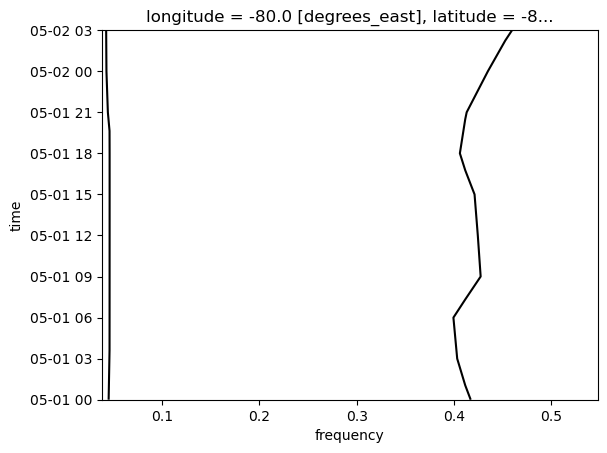

In [46]:
# era5_wave_spectrum_sum_1pt.isel(time=slice(0,10)).plot.contourf(levs=np.arange(0,0.1,0.01), vmax=0.1,cmap='viridis', add_colorbar=True, figsize=(10, 5))
era5_wave_spectrum_sum_1pt.isel(time=slice(0,10)).plot.contour(levels=[5e-2], colors='k')

acc_spectrum_era5 = era5_wave_spectrum_sum_1pt*(2*np.pi*era5_wave_spectrum_sum_1pt.frequency)**4

# plt.axhline(y=2e-2, color='r', linestyle='--', label='1e-2')
# plt.ylim(0,0.1)
# acc_spectrum_era5.isel(time=1).plot()

# plt.xscale('log')

In [450]:
m0 = np.zeros(len(PSD_eta))
m0_band = np.zeros(len(PSD_eta))
m0_band2 = np.zeros(len(PSD_eta))
m0_interpolated = np.zeros(len(PSD_eta))
m0_stepwize = np.zeros(len(PSD_eta))
Hs = np.zeros(len(PSD_eta))
Hs_band = np.zeros(len(PSD_eta))
Hs_band2 = np.zeros(len(PSD_eta))
Hs_interpolated = np.zeros(len(PSD_eta))
Hs_stepwize = np.zeros(len(PSD_eta))
for i in range(len(PSD_eta)):
    PSD_eta0 = PSD_eta[i]
    f_accz0 = f_accz_all[i]
    # Compute significant wave height
    # Integrate the PSD between 0.05 Hz and 0.2 Hz (typical wave frequency range)
    mask = (f_accz0 >= 0.05) & (f_accz0 <= 0.2)
    mask2 = (f_accz0 >= 0.05) & (f_accz0 <= 0.15)
    m0[i] = np.trapz(PSD_eta0, f_accz0)
    m0_band[i] = np.trapz(PSD_eta0[mask], f_accz0[mask])
    m0_band2[i] = np.trapz(PSD_eta0[mask2], f_accz0[mask2])
    m0_interpolated[i] = np.trapz(np.nan_to_num(PSD_eta_ro0_filtered_all[i]), f_accz0)
    m0_stepwize[i] = np.trapz(np.nan_to_num(PSD_eta_ro0_stepwize_all[i]), f_accz0)
    Hs[i] = 4 * np.sqrt(m0[i])
    Hs_band[i] = 4 * np.sqrt(m0_band[i])
    Hs_band2[i] = 4 * np.sqrt(m0_band2[i])
    Hs_interpolated = 4 * np.sqrt(m0_interpolated)
    Hs_stepwize = 4 * np.sqrt(m0_stepwize)
    # print(f"Significant Wave Height: {Hs[i]:.2f} m, filtered: {Hs_band[i]:.2f} m")

# create a dataframe with the results
Hs_df1 = pd.DataFrame({
    'time': t_april,
    'Hs': Hs,
    'Hs_band': Hs_band,
    'Hs_band2': Hs_band2,
    'Hs_interpolated': Hs_interpolated,
    'Hs_stepwize': Hs_stepwize,
    'lon': x_april,
    'lat': y_april,
    'era5_wmp': mwp_all,
    'era5_swh': swh_all,
    'era5_mwd': mwd_all,
    'era5_wmp2': mwp_all2,
    'era5_swh2': swh_all2,
    'era5_mwd2': mwd_all2,
    'chunk_id': chunk_id_all,
})
Hs_df1


,time,Hs,Hs_band,Hs_band2,Hs_interpolated,Hs_stepwize,lon,lat,era5_wmp,era5_swh,era5_mwd,era5_wmp2,era5_swh2,era5_mwd2,chunk_id
0,2025-04-29 20:59:11.200,21.309132,2.396203,2.319191,0.880573,2.445537,-79.09223175048828,-8.592782020568848,11.117854,1.9774408,198.5363,11.389583,1.8668451,201.17693,7502
1,2025-05-01 16:03:05.200,25.001313,2.052575,1.917936,0.946588,2.767777,-79.1068344116211,-8.686763763427734,11.198185,1.8321257,196.48676,11.423283,1.7210417,199.18988,7581
2,2025-05-01 16:07:23.200,8.951001,1.414291,1.370478,0.719717,1.899023,-79.1068344116211,-8.686763763427734,11.198185,1.8321257,196.48676,11.423283,1.7210417,199.18988,7583
3,2025-05-03 16:03:03.200,14.894299,1.462205,1.412740,0.668033,1.813651,-79.08097076416014,-8.482622146606445,10.129773,1.7575655,197.90717,10.407849,1.652585,201.61029,7673
4,2025-05-04 15:39:10.610,6.630859,1.381520,1.338157,0.677337,1.534741,-78.884765625,-8.666779518127441,10.947377,1.8283339,198.82312,11.08727,1.7350721,201.1278,7740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,2025-05-24 17:43:00.200,10.734618,2.946800,2.920297,1.965183,3.967776,-78.89055633544923,-8.899245262145996,14.844208,2.654954,213.3675,12.33904,2.0232353,209.73634,37693
480,2025-05-25 12:39:28.670,11.171702,2.040035,2.028850,1.418442,2.951577,-78.66999053955078,-9.086188316345217,15.317144,2.8158376,210.36899,12.33904,2.0232353,209.73634,37716
481,2025-05-25 14:39:22.200,8.066239,1.672460,1.599613,0.704757,1.665244,-78.6428985595703,-9.171944618225098,15.185534,2.7817137,210.26808,12.33904,2.0232353,209.73634,37767
482,2025-05-25 14:57:24.140,11.521886,2.242807,2.177573,1.246278,2.230984,-78.64190673828125,-9.173443794250488,15.185534,2.7817137,210.26808,12.33904,2.0232353,209.73634,37769


In [451]:
# plt.plot(Hs_df[Hs_df['time']<=pd.to_datetime('2025-05-15')]['Hs_band'],Hs_df[Hs_df['time']<=pd.to_datetime('2025-05-15')]['era5_swh'],'.')
# plt.plot(Hs_df['Hs_band'],Hs_df['era5_swh'],'.')
# plt.plot(Hs_df['Hs_stepwize'],Hs_df['era5_swh'],'.',color='blue')
plt.plot(Hs_df['Hs_stepwize'],Hs_df['era5_swh'],'.',color='tab:blue')
# plt.plot(Hs_df['Hs_band2'],Hs_df['era5_swh'],'.',color='orange')
# plt.plot(Hs_df['Hs_band'],Hs_df['era5_swh2'],'.',color='orange')
plt.plot([1,5],[1,5],'--',color = 'grey')
plt.xlabel('Hs from accz')
plt.ylabel('Hs from era5')
plt.xlim(0,5)
plt.ylim(0,5)
plt.title('Hs stepwize filtered')

KeyError: 'Hs_stepwize'

In [447]:
depth00 = get_depths_at_locations(Hs_df1['lon'], Hs_df1['lat'], bath1_region)
Hs_df1['depth'] = depth00
depth1 = 158
g=9.81

# Add the 'Hs0' column to the DataFrame if it doesn't exist
if 'Hs0' not in Hs_df1.columns:
    Hs_df1['Hs0'] = np.nan

for k in range(len(Hs_df1)):
# for k in [3]:
    t_bird = Hs_df1['time'].iloc[k]
    # h_bird = -Hs_df['depth'].iloc[k]
    h_bird = -Hs_df1['depth'].iloc[k]

    # # depth1 = ds_era5_hor.wmb.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # swh1 = ds_era5_hor.swh.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # mwd1 = ds_era5_hor.mwd.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # mwp1 = ds_era5_hor.mwp.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # print(k,swh1,mwd1,mwp1)
    swh1 = Hs_df1['era5_swh'].iloc[k]
    mwd1 = Hs_df1['era5_mwd'].iloc[k]
    mwp1 = Hs_df1['era5_wmp'].iloc[k]

    k1 = wavenumber(mwp1,depth1,g)
    cel1 = waveCel(k1,mwp1)
    n1 = nRatio(k1,depth1)
    cg1 = waveGroupSpeed(cel1,n1)

    k2 = wavenumber(mwp1,h_bird,g)
    cel2 = waveCel(k2,mwp1)
    n2 = nRatio(k2,h_bird)
    cg2 = waveGroupSpeed(cel2,n2)

    theta1 = 240-mwd1
    theta_bird = Snell(theta1,cel1,cel2)

    h2 = swh1*np.sqrt(cg1*np.cos(np.radians(theta1))/(cg2*np.cos(np.radians(theta_bird))))
    # print(k1,k2,cel1,cel2,n1,n2,cg1,cg2,theta1,theta_bird,h_bird,swh1,mwd1,mwp1,h2)
    print(depth1, h_bird,k1,k2,cel1, cel2, theta1,theta_bird,mwd1,cg1,cg2,h2)
    print(n1,n2)
    print(h2,swh1)
    # Hs_df.at[k, 'Hs'] = h2
    Hs_df1.at[k, 'Hs0'] = h2

NameError: name 'Hs_df1' is not defined

In [446]:
# Convert time to date for grouping
Hs_df1['date'] = Hs_df1['time'].dt.date

# Group by date and calculate daily averages
daily_avg1 = Hs_df1.groupby('date').agg({
    'Hs': 'mean',
    'Hs_band': 'mean',
    'Hs_band2': 'mean',
    'Hs_interpolated': 'mean',
    'Hs_stepwize': 'mean',
    'Hs0': 'mean',  # Uncomment if you have Hs0 in your DataFrame
    'era5_swh': 'mean',
    'era5_wmp': 'mean',
    'era5_mwd': 'mean',
    'era5_swh2': 'mean',
    'era5_wmp2': 'mean',
    'era5_mwd2': 'mean',
    'lon': 'mean',
    'lat': 'mean',
    # 'depth': 'mean'
}).reset_index()
# Calculate standard deviation (variance) for each day
daily_variance = Hs_df1.groupby('date').agg({
    'Hs': 'std',
    'Hs0': 'std',  # Uncomment if you have Hs0 in your DataFrame
    'Hs_band': 'std',
    'Hs_band2': 'std',
    'Hs_interpolated': 'std',
    'Hs_stepwize': 'std',
    'era5_swh': 'std'
}).reset_index()

# Rename columns to make it clear they are standard deviations
daily_variance = daily_variance.rename(columns={
    'Hs': 'Hs_std',
    'Hs0': 'Hs0_std',  # Uncomment if you have Hs0 in your DataFrame
    'Hs_band': 'Hs_band_std',
    'Hs_band2': 'Hs_band2_std',
    'Hs_interpolated': 'Hs_interpolated_std',
    'Hs_stepwize': 'Hs_stepwize_std',
    'era5_swh': 'era5_swh_std'
})

# Merge the variance data with the average data
daily_avg1 = daily_avg1.merge(daily_variance, on='date')
# Calculate number of observations per day
obs_count = Hs_df1.groupby('date').size().reset_index(name='count')
daily_avg1 = daily_avg1.merge(obs_count, on='date')

# Calculate correlation between bird-derived Hs and ERA5 Hs
# corr_hs_era5 = Hs_df['Hs_band'].corr(Hs_df['era5_swh'])
# corr_hs0_era5 = Hs_df['Hs0'].corr(Hs_df['era5_swh'])

# Plot daily averages
fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(daily_avg1['date'], daily_avg1['Hs_interpolated'], 
            yerr=daily_avg1['Hs_interpolated_std'], fmt='o-', label='Hs from bird (band-filtered)', capsize=5)

ax.errorbar(daily_avg1['date'], daily_avg1['Hs_stepwize'], 
            yerr=daily_avg1['Hs_stepwize_std'], fmt='o-', label='Hs from bird (stepwize-filtered)', capsize=5)
# ax.plot(daily_avg['date'], daily_avg['Hs_interpolated'], 'o-', label='Hs from bird (era5-filtered)')
# ax.plot(daily_avg['date'], daily_avg['Hs0'], 's-', label='Hs from ERA5')
ax.plot(daily_avg1['date'], daily_avg1['era5_swh'], '^-', label='Hs from ERA5 (raw)')
ax.plot(daily_avg1['date'], daily_avg1['Hs0'], '^-', label='Hs adjusted by shoaling')

# Add count as text above each point
for i, row in daily_avg1.iterrows():
    ax.annotate(f"n={row['count']}", 
                (row['date'], max(row['Hs_interpolated'], row['Hs_interpolated'])+0.1), 
                ha='center')

ax.set_xlabel('Date')
ax.set_ylabel('Significant Wave Height (m)')
# ax.set_title(f'Daily Average Significant Wave Height\nCorrelation: {corr_hs_era5:.2f} (raw), {corr_hs0_era5:.2f} (depth-adjusted)')
ax.legend()
ax.grid(True)

# Rotate date labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()

NameError: name 'Hs_df1' is not defined

[[1.         0.65561198]
 [0.65561198 1.        ]]
[[1.         0.69428666]
 [0.69428666 1.        ]]


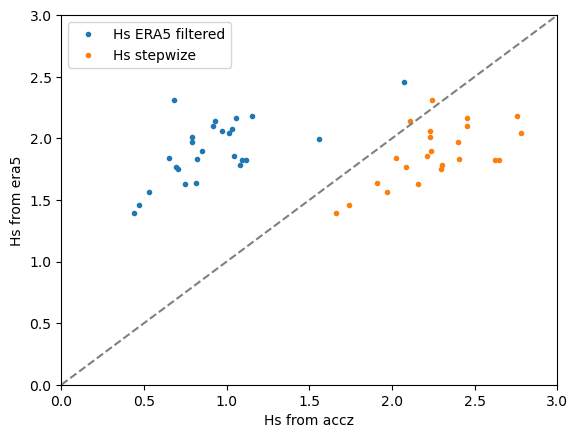

In [917]:
plt.plot(daily_avg['Hs_interpolated'], daily_avg['era5_swh'],'.',color='tab:blue', label='Hs ERA5 filtered')
plt.plot(daily_avg['Hs_stepwize'], daily_avg['era5_swh'],'.',color='tab:orange',label='Hs stepwize')
plt.plot([0,3],[0,3],'--',color = 'grey')
plt.xlim(0,3)
plt.ylim(0,3)
plt.legend()
plt.xlabel('Hs from accz')
plt.ylabel('Hs from era5')

print(np.corrcoef(daily_avg['Hs_interpolated'], daily_avg['era5_swh']))
print(np.corrcoef(daily_avg['Hs_stepwize'], daily_avg['era5_swh']))

[[1.         0.66559212]
 [0.66559212 1.        ]]
[[1.         0.70384558]
 [0.70384558 1.        ]]


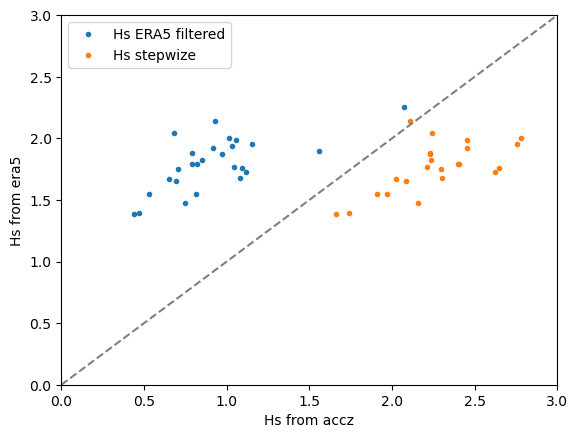

In [918]:
plt.plot(daily_avg['Hs_interpolated'], daily_avg['Hs0'],'.',color='tab:blue', label='Hs ERA5 filtered')
plt.plot(daily_avg['Hs_stepwize'], daily_avg['Hs0'],'.',color='tab:orange',label='Hs stepwize')
plt.plot([0,3],[0,3],'--',color = 'grey')
plt.xlim(0,3)
plt.ylim(0,3)
plt.legend()
plt.xlabel('Hs from accz')
plt.ylabel('Hs from era5')

print(np.corrcoef(daily_avg['Hs_interpolated'], daily_avg['Hs0']))
print(np.corrcoef(daily_avg['Hs_stepwize'], daily_avg['Hs0']))

## Apply a filter from Jim Moum (2023)

In [469]:
era5_wave3.isel(longitude=4, latitude=6).swh
# era5_wave2.isel(longitude=2, latitude=3).swh

<xarray.DataArray 'swh' (valid_time: 2184)>
array([1.486094, 1.494362, 1.498517, ..., 2.264892, 2.228335, 2.196894],
      dtype=float32)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2025-04-01 ... 2025-06-30T23:00:00
    latitude    float64 -8.0
    longitude   float64 -80.0
    expver      (valid_time) object ...
Attributes: (12/32)
    GRIB_paramId:                             140229
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      99
    GRIB_typeOfLevel:                         meanSea
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Significant height of combined ...
    units:                                    m
    standard_name:                            unknown
    GRIB_meanSea:                             0.0

In [130]:
plt_flg = 0

grav0 = 9.81  # m/s^2
# swh_era5_1pt = era5_wave.isel(longitude=3, latitude=4)
# swh_era5_1pt2 = era5_wave.isel(longitude=4, latitude=5)
swh_era5_2 = era5_wave2.isel(longitude=2, latitude=3)
swh_era5_3 = era5_wave3.isel(longitude=4, latitude=6)

# from scipy.signal import welch
sample_rate = 5
order=4
icount=0
for i in rec_list2_ok:
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]

    # if (np.max(chunk00['accz'].values)<1500)&(np.min(chunk00['accz'].values)>500):
    accz_1 = chunk00["accz"].values/1000*9.81
    accx_1 = chunk00["accx"].values/1000*9.81
    accy_1 = chunk00["accy"].values/1000*9.81
    accz_1_sub = chunk00['accz'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accx_1_sub = chunk00['accx'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accy_1_sub = chunk00['accy'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    # t_acc = np.arange(len(accz_1))/5
    # accx_rotated_nosmoo,accy_rotated_nosmoo,accz_rotated_nosmoo = rotation_3d(accx_1_sub, accy_1_sub, accz_1_sub)
    # accx_rotated, accy_rotated,accz_rotated,_ = analyze_chunk_with_rotation(chunk00, fs=5, plot=False)

    accz_wave = accz_1_sub - grav0*np.sqrt(1-(accx_1_sub/grav0)**2 - (accy_1_sub/grav0)**2)

    f_accz_detrend, Pxx_accz_detrend = power_spectral_density_fft(signal.detrend(accz_1_sub))
    f_accx_detrend, Pxx_accx_detrend = power_spectral_density_fft(signal.detrend(accx_1_sub))
    f_accy_detrend, Pxx_accy_detrend = power_spectral_density_fft(signal.detrend(accy_1_sub))

    f_accz_moum, Pxx_accz_moum = power_spectral_density_fft(accz_wave)

    # Calculate low frequency components (f < 0.05 Hz) for Moum's method
    f_low_indices = np.where(f_accz_moum < 0.05)[0]
    Pxx_accz_moum_low = Pxx_accz_moum[f_low_indices]
    f_accz_moum_low = f_accz_moum[f_low_indices]

    # Calculate mean power in the low frequency band
    mean_power_low = np.mean(Pxx_accz_moum_low)
    print(Pxx_accz_moum_low)
    max_power_low = np.max(Pxx_accz_moum_low)

    # # Pxx_z_eta = Pxx_accz/(2*np.pi*f_accz)**4
    # # Pxx_z_eta = np.where(f_accz>0, Pxx_z_eta, 0)
    # Pxx_z_eta_ro0 = Pxx_accz_ro0/(2*np.pi*f_accz_ro0)**4
    # Pxx_z_eta_ro0 = np.where(f_accz_ro0>0, Pxx_z_eta_ro0, 0)

    Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_d = np.where(f_accz_detrend>0, Pxx_z_eta_d, 0)
    Pxx_z_eta_moum = Pxx_accz_moum/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_moum = np.where(f_accz_detrend>0, Pxx_z_eta_moum, 0)
    transfunc = (1-1/(1+(f_accz_detrend/(1/27))**4))**6  # transfer function for 23s filter (Moum et al. 2023)
    Pxx_z_eta_d_filtered1 = Pxx_z_eta_d * transfunc
    Pxx_z_eta_d_filtered2 = Pxx_z_eta_moum * transfunc

    Pxx_accz_whitenoise = Pxx_accz_detrend*0+ 0.1
    Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
    # Pxx_z_eta_whitenoise = np.where(f_accz_detrend>0, Pxx_z_eta_whitenoise, 0)

    # Pxx_accz_dewhitenoise = Pxx_z_eta_ro0-Pxx_z_eta_whitenoise
    # # Pxx_x_eta = Pxx_accx/(2*np.pi*f_accx)**4
    # # Pxx_x_eta = np.where(f_accx>0, Pxx_x_eta, 0)
    # Pxx_x_eta_d = Pxx_accx_detrend/(2*np.pi*f_accx_detrend)**4
    # Pxx_x_eta_d = np.where(f_accx_detrend>0, Pxx_x_eta_d, 0)
    # # Pxx_y_eta = Pxx_accy/(2*np.pi*f_accy)**4
    # # Pxx_y_eta = np.where(f_accy>0, Pxx_y_eta, 0)
    # Pxx_y_eta_d = Pxx_accy_detrend/(2*np.pi*f_accy_detrend)**4
    # Pxx_y_eta_d = np.where(f_accy_detrend>0, Pxx_y_eta_d, 0)
    # # mwp_chunk = ds_era5_hor_may01.mwp.sel(longitude=chunk00['lon'].iloc[0], latitude=chunk00['lat'].iloc[0], valid_time=chunk00["original_time"].values[0], method='nearest').values
    # mwp_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    # swh_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    # mwd_chunk = swh_era5_1pt.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values
    # mwp_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    # swh_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    # mwd_chunk2 = swh_era5_1pt2.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    # if chunk00.iloc[0].original_time>pd.to_datetime('2025-05-15T23:00:00'):
    #     mwp_chunk = swh_era5_2.sel(time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    #     swh_chunk = swh_era5_2.sel(time = chunk00.iloc[0].original_time,method='nearest').swh.values
    #     mwd_chunk = swh_era5_2.sel(time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    mwp_chunk = swh_era5_3.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    swh_chunk = swh_era5_3.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    mwd_chunk = swh_era5_3.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    # # spectrum_chunk = era5_peru_mean.sel(time=chunk00.iloc[0].original_time,method='nearest')
    spectrum_chunk = era5_wave_spectrum_sum_1pt.sel(time=chunk00.iloc[0].original_time,method='nearest')    
    spectrum_chunk_interpolated = spectrum_chunk.interp(frequency=f_accz_detrend, method='linear')
    # spectrum_chunk_interpolated_normolized = spectrum_chunk_interpolated/np.nansum(spectrum_chunk_interpolated.values)
    # spectrum_chunk_interpolated_stepwize = np.zeros_like(spectrum_chunk_interpolated.values)
    # spectrum_chunk_interpolated_stepwize[spectrum_chunk_interpolated.values >= 10e-2] = 1
    # print(spectrum_chunk_interpolated_stepwize)
    # # print(spectrum_chunk_interpolated_normolized)
    # PSD_eta_ro0_filtered = Pxx_z_eta_ro0*spectrum_chunk_interpolated_normolized.values
    # PSD_eta_ro0_stepwize = Pxx_z_eta_ro0*spectrum_chunk_interpolated_stepwize

    # acc_spectrum_era5 = spectrum_chunk*(2*np.pi*spectrum_chunk.frequency)**4

    # diff_accz_rolling_avg = pd.Series(accz_rotated[50:-50]-accz_1[50:-50]).rolling(50,center=True).mean()
    # diff_accz_rolling_avg = diff_accz_rolling_avg.values
    # diff_accx_rolling_avg = pd.Series(accx_rotated[50:-50]-accx_1[50:-50]).rolling(50,center=True).mean()
    # diff_accx_rolling_avg = diff_accx_rolling_avg.values
    # diff_accy_rolling_avg = pd.Series(accy_rotated[50:-50]-accy_1[50:-50]).rolling(50,center=True).mean()
    # diff_accy_rolling_avg = diff_accy_rolling_avg.values
    if icount == 0:
        PSD_acc = [Pxx_accz_detrend]
        f_accz_all = [f_accz_detrend]
        PSD_eta = [Pxx_z_eta_d]
        PSD_eta_wave_all = [Pxx_z_eta_moum]
        PSD_eta_moum_filtered1_all = [Pxx_z_eta_d_filtered1]
        PSD_eta_moum_filtered2_all = [Pxx_z_eta_d_filtered2]
        # PSD_eta_ro0 = [Pxx_z_eta_ro0]
        # PSD_eta_ro0_filtered_all = [PSD_eta_ro0_filtered]
        # PSD_eta_ro0_stepwize_all = [PSD_eta_ro0_stepwize]
        t_april = [chunk00['original_time'].iloc[0]]
        x_april = [chunk00['lon'].iloc[0]]
        y_april = [chunk00['lat'].iloc[0]]
        mwp_all = [mwp_chunk]
        swh_all = [swh_chunk]
        mwd_all = [mwd_chunk]
        # mwp_all2 = [mwp_chunk2]
        # swh_all2 = [swh_chunk2]
        # mwd_all2 = [mwd_chunk2]
        chunk_id_all = [i]
    else:
        PSD_acc.append(Pxx_accz_detrend)
        f_accz_all.append(f_accz_detrend)
        PSD_eta.append(Pxx_z_eta_d)
        PSD_eta_wave_all.append(Pxx_z_eta_moum)
        PSD_eta_moum_filtered1_all.append(Pxx_z_eta_d_filtered1)
        PSD_eta_moum_filtered2_all.append(Pxx_z_eta_d_filtered2)
        # PSD_eta_ro0.append(Pxx_z_eta_ro0)
        # PSD_eta_ro0_filtered_all.append(PSD_eta_ro0_filtered)
        # PSD_eta_ro0_stepwize_all.append(PSD_eta_ro0_stepwize)
        t_april.append(chunk00['original_time'].iloc[0])
        x_april.append(chunk00['lon'].iloc[0])
        y_april.append(chunk00['lat'].iloc[0])
        mwp_all.append(mwp_chunk)
        swh_all.append(swh_chunk)
        mwd_all.append(mwd_chunk)
        # mwp_all2.append(mwp_chunk2)
        # swh_all2.append(swh_chunk2)
        # mwd_all2.append(mwd_chunk2)
        chunk_id_all.append(i)
    icount += 1
    if plt_flg == 1:
        fig = plt.figure(figsize=(12,3),constrained_layout=True)

        gs = fig.add_gridspec(1, 3, width_ratios=[1, 2, 2])
        axs1 = fig.add_subplot(gs[0,0])
        axs2 = fig.add_subplot(gs[0,1])
        axs3 = fig.add_subplot(gs[0,2])
        axs1.plot(np.arange(len(accz_1_sub))/5,accz_1_sub-9.81,label = 'RAW accz-g')
        # axs1.plot(np.arange(len(accx_1_sub))/5,accx_1_sub,label = 'RAW accx')
        # axs1.plot(np.arange(len(accy_1_sub))/5,accy_1_sub,label = 'RAW accy')
        axs1.plot(np.arange(len(accz_wave))/5,accz_wave,label = 'acc wave')
        axs1.plot(np.arange(len(accz_wave))/5,accz_1_sub-9.81-accz_wave,label = 'RAW_accz-acc_wave')
        # axs1.plot(np.arange(len(accz_1[50:-51]))/5,accz_rotated[50:-51],label = 'Rotated accz')
        # axs1.plot(t_acc[50:-50],accz_rotated[50:-50]-accz_1[50:-50],label = 'diff accz')
        # axs1.plot(t_acc[50:-50],diff_accz_rolling_avg,label = 'diff accz rolling avg')
        axs1.set_xlabel('Time [s]')
        axs1.set_ylabel('accz [m/s^2]')
        axs1.legend()
        axs1.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')
        # axs1.set_ylim(-1,2)

        # axs2.plot(f_accz, Pxx_accz,label='Rotated accz (FFT)')
        axs2.plot(f_accz_detrend, Pxx_accz_detrend,'b',label='Non-rot accz (FFT)')
        # axs2.plot(f_accz_ro0, Pxx_accz_ro0,'r',label='Non-rot accz (FFT rotated)')
        axs2.plot(f_accz_detrend, Pxx_accz_whitenoise,'g',label='whitenoise accz (FFT)')
        axs2.plot(f_accz_moum, Pxx_accz_moum,'r',label='Rotated accz (Moum)')
        axs2.plot(acc_spectrum_era5.frequency, acc_spectrum_era5,color='orange',label='ERA5 spectrum')
        # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
        # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
        axs2.axvline(x=0.05, color='r', linestyle='--')
        axs2.axvline(x=0.2, color='r', linestyle='--')
        axs2.axhline(y=mean_power_low, color='k', linestyle='--', label='mean power low freq band')
        # axs2.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
        # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
        axs2.set_xscale('log')
        axs2.set_xlabel('Freq [Hz]')
        axs2.set_ylabel('Power spectral density [acc**2/Hz]')
        axs2.set_title(f'SH = {swh_chunk:.2f} m')
        axs2.set_ylim(0,1)
        # axs2.set_yscale('log')
        axs2.legend(loc='upper right')
        # axs22 = axs2.twinx()
        # axs2.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'g',label='mean_power')
        # To set the color of the tick labels, we need to get the current labels first
        # axs22.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

        # axs3.plot(f_accz, Pxx_z_eta,label='PSD eta')
        axs3.plot(f_accz_detrend, Pxx_z_eta_d,label='FFT eta')
        axs3.plot(f_accz_moum, Pxx_z_eta_moum,'r',label='FFT eta (Rotation)')
        # axs3.plot(f_accz_detrend, Pxx_z_eta_d_filtered1,'g',label='FFT eta (transfer function')
        axs3.plot(f_accz_detrend, Pxx_z_eta_d_filtered2,'b',label='FFT eta (Rotation+transfunc)')
        # axs3.plot(f_accz_ro0, Pxx_z_eta_ro0,'r',label='FFT eta rotated')
        axs3.plot(f_accz_detrend, Pxx_z_eta_whitenoise,'g',label='FFT eta whitenoise')
        # # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
        # # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
        # # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
        axs3.axvline(x=0.05, color='r', linestyle='--')
        axs3.axvline(x=0.2, color='r', linestyle='--')
        # # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--',linewidth=2)
        # # axs3.plot(da.frequency, mean_power[0].values,color = 'orange',label='mean_power')
        axs3.plot(spectrum_chunk.frequency, spectrum_chunk,'--',color='k',label='era5 spectrum')
        # axs3.plot(f_accz_detrend, spectrum_chunk_interpolated_normolized*Pxx_z_eta_ro0,'g',label='FFT eta (era5 spectrum filtered)')
        # axs3.plot(f_accz_detrend, spectrum_chunk_interpolated_stepwize,'c',label='Filter (era5 spectrum filtered)')
        # axs3.plot(f_accz_detrend, PSD_eta_ro0_stepwize,'m',label='FFT eta (era5 spectrum stepwize filtered)')
        # # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
        # # axs3.axhline(y=swh_chunk**2, color='b', linestyle='--', label='swh',linewidth=2)
        # # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
        axs3.set_xscale('log')
        axs3.set_xlabel('Freq [Hz]')
        axs3.set_ylabel('Power spectral density [acc**2/Hz]')
        # axs3.set_yscale('log')
        axs3.set_ylim(0,10)
        axs3.legend(loc='upper right')
        fig.savefig(f'chunk_frequency_100s_all_tags_v4/add_moum_05/chunk_spectrum_accz_{i}.png')
        plt.close()

In [138]:
del PSD_eta_moum_filtered1_all_int

In [140]:
from scipy.interpolate import interp1d

# faccz_max=[]
# for i in range(len(PSD_eta)):
#     f_accz0 = f_accz_all[i]
#     faccz_max.append(np.max(f_accz0))
#     print(f_accz0.shape)
#     print(np.max(f_accz0),np.min(f_accz0))

# print(np.max(faccz_max))

f_accz_int = f_accz_all[0]
PSD_eta_moum_filtered1_all_int = [PSD_eta_moum_filtered1_all[0]]
PSD_eta_moum_filtered2_all_int = [PSD_eta_moum_filtered2_all[0]]
PSD_eta_wave_all_int = [PSD_eta_wave_all[0]]
for i in range(len(PSD_eta)):
    f_accz0 = f_accz_all[i]
    # Skip the first iteration since we're already using it as reference
    if i == 0:
        continue
        
    # Interpolate PSD_eta_moum_filtered1_all[i] to match the frequency points in f_accz_int
    
    # Create interpolation function (use 'linear' for linear interpolation)
    interp_func = interp1d(f_accz0, PSD_eta_moum_filtered1_all[i], 
                          bounds_error=False, fill_value=0)
    
    # Replace the original array with the interpolated version
    PSD_eta_moum_filtered1_all_int.append(interp_func(f_accz_int))

    # Do the same for PSD_eta_moum_filtered2_all if needed
    interp_func2 = interp1d(f_accz0, PSD_eta_moum_filtered2_all[i], 
                           bounds_error=False, fill_value=0)
    PSD_eta_moum_filtered2_all_int.append(interp_func2(f_accz_int))


    interp_func3 = interp1d(f_accz0, PSD_eta_wave_all[i], 
                           bounds_error=False, fill_value=0)
    PSD_eta_wave_all_int.append(interp_func3(f_accz_int))

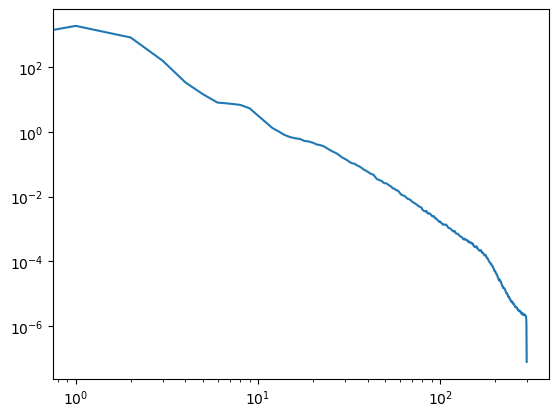

In [693]:
PSD_eta_wave_all_int_mean = np.mean(np.array(PSD_eta_wave_all_int), axis=0)
plt.plot(PSD_eta_wave_all_int_mean)
plt.xscale('log')
plt.yscale('log')

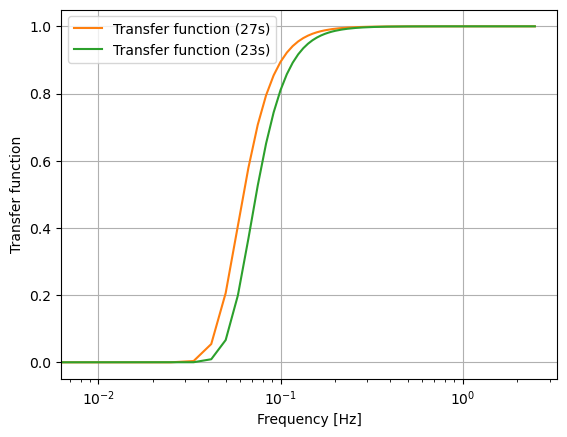

In [132]:
transfunc_plt_27 = (1-1/(1+(f_accz_int/(1/27))**4))**6  # transfer function for 23s filter (Moum et al. 2023)
transfunc_plt_23 = (1-1/(1+(f_accz_int/(1/23))**4))**6  # transfer function for 23s filter (Moum et al. 2023)
plt.plot(f_accz_int,transfunc_plt_27,label='Transfer function (27s)', color='tab:orange')
plt.plot(f_accz_int,transfunc_plt_23,label='Transfer function (23s)', color='tab:green')
plt.xscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Transfer function')
plt.legend()
plt.grid()

In [141]:
PSD_df = pd.DataFrame({
    'time': t_april,
    'PSD_filter1': PSD_eta_moum_filtered1_all_int,
    'PSD_filter2': PSD_eta_moum_filtered2_all_int,
})
PSD_df['date'] = PSD_df['time'].dt.date
PSD_df
PSD_daily_avg = PSD_df.groupby('date').agg({
    'PSD_filter1': 'mean',
    'PSD_filter2': 'mean',}).reset_index()
PSD_daily_avg

,date,PSD_filter1,PSD_filter2
0,2025-04-25,"[0.0, 2.3575231566706604e-08, 0.00013059375481...","[0.0, 1.5916332370843758e-08, 0.00352493224788..."
1,2025-04-26,"[0.0, 2.0043161963568574e-12, 3.91396909241464...","[0.0, 6.395417836248754e-11, 1.168646629535068..."
2,2025-04-27,"[0.0, 4.0484512149141793e-07, 8.42387740726006...","[0.0, 3.982440453656868e-08, 1.43223370599576e..."
3,2025-04-28,"[0.0, 5.457543019949087e-07, 0.000477921916975...","[0.0, 1.6240570177126288e-06, 0.00284618337394..."
4,2025-04-29,"[0.0, 4.945322469832711e-09, 0.000503224106073...","[0.0, 6.8626501313641396e-09, 0.00068262996220..."
5,2025-04-30,"[0.0, 3.564254484670686e-12, 3.558501822290559...","[0.0, 3.5677829845035577e-12, 2.82744819199822..."
6,2025-05-01,"[0.0, 1.6580729550645906e-07, 0.00014179490323...","[0.0, 1.5311671353155529e-07, 4.92098118334413..."
7,2025-05-03,"[0.0, 1.6117796597619223e-07, 0.00146738921846...","[0.0, 1.9736129419858213e-07, 0.00060201764546..."
8,2025-05-04,"[0.0, 2.205562262549278e-08, 0.001406829089781...","[0.0, 2.7979893602813723e-08, 0.00105200465695..."
9,2025-05-05,"[0.0, 9.765703884473281e-08, 0.003835034023176...","[0.0, 7.931258123605227e-08, 0.001963458194642..."


/tmp/ipykernel_375203/802059848.py:27: RuntimeWarning: divide by zero encountered in log10
  plt.pcolor(time_values, f_accz_int, np.log10(np.array([psd for psd in PSD_df_sorted['PSD_filter2']]).T),
/tmp/ipykernel_375203/802059848.py:33: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='Power Spectral Density (m²/Hz)')


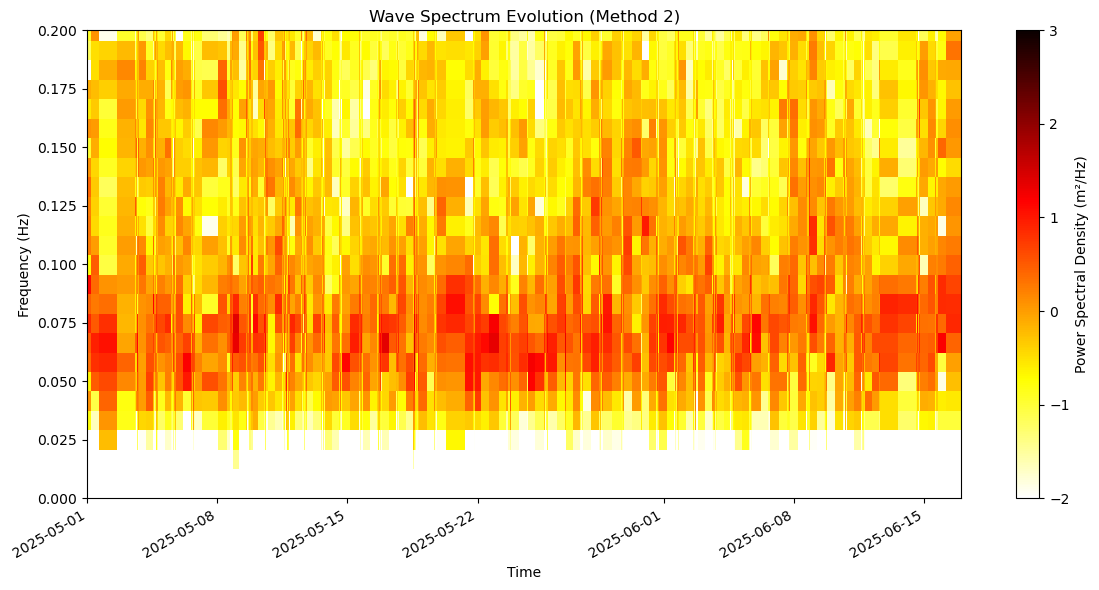

In [187]:
# Sort the PSD dataframe by time to ensure chronological order
PSD_df_sorted = PSD_df.sort_values(by='time')

# Convert the time values to a format suitable for plotting
time_values = pd.to_datetime(PSD_df_sorted['time'])

# Create the frequency-time heatmap plot
# plt.figure(figsize=(12, 6))
# plt.pcolor(time_values, f_accz_int, np.array([psd for psd in PSD_df_sorted['PSD_filter1']]).T, 
#            cmap='viridis', vmax=15, shading='auto')

# # Customize the plot
# plt.ylim(0, 0.2)  # Focus on the frequency range of interest
# plt.colorbar(label='Power Spectral Density (m²/Hz)')
# plt.xlabel('Time')
# plt.ylabel('Frequency (Hz)')
# plt.title('Wave Spectrum Evolution (Moum Filtered)')

# # Format the time axis to show dates clearly
# plt.gcf().autofmt_xdate()
# plt.tight_layout()

# Create a second plot for comparison with the second filter method
plt.figure(figsize=(12, 6))
# plt.pcolor(time_values, f_accz_int, np.array([psd for psd in PSD_df_sorted['PSD_filter2']]).T, 
#            cmap='hot_r', vmax=15, shading='auto')
plt.pcolor(time_values, f_accz_int, np.log10(np.array([psd for psd in PSD_df_sorted['PSD_filter2']]).T), 
           cmap='hot_r', vmin=-2, vmax=3, shading='auto')

# Customize the second plot
plt.ylim(0, 0.2)
plt.xlim(pd.to_datetime('2025-05-01'), pd.to_datetime('2025-06-17'))  # Adjust the x-axis limits as needed
plt.colorbar(label='Power Spectral Density (m²/Hz)')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Wave Spectrum Evolution (Method 2)')
plt.gcf().autofmt_xdate()
plt.tight_layout()

In [166]:
psd1_values = np.array([psd for psd in PSD_daily_avg['PSD_filter1']])
psd2_values = np.array([psd for psd in PSD_daily_avg['PSD_filter2']])

psd_df1_values = np.array([psd for psd in PSD_df['PSD_filter1']])
psd_df2_values = np.array([psd for psd in PSD_df['PSD_filter2']])


/tmp/ipykernel_375203/2431477972.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.pcolor(PSD_daily_avg.date, f_accz_int, np.log10(psd2_values.T) , cmap='hot_r',vmin=-2, vmax=3)
/tmp/ipykernel_375203/2431477972.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='PSD (m^2/Hz)')


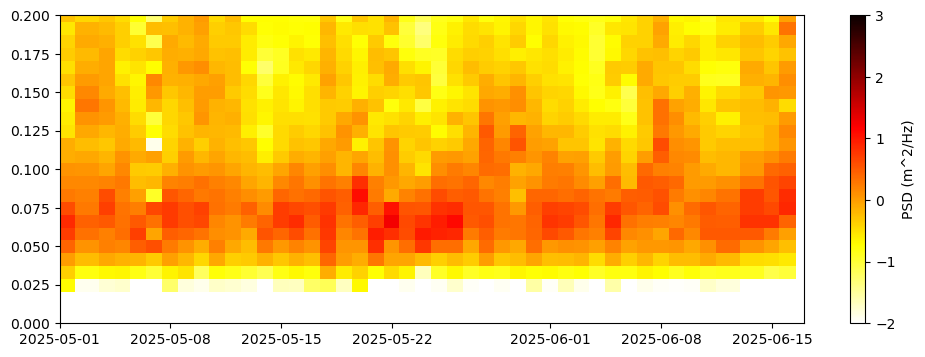

In [178]:
plt.figure(figsize=(12, 4))
plt.pcolor(PSD_daily_avg.date, f_accz_int, np.log10(psd2_values.T) , cmap='hot_r',vmin=-2, vmax=3)
# plt.pcolor(PSD_daily_avg.date, f_accz_int,  psd2_values.T, cmap='hot_r', vmax=15,)
# plt.pcolor(time_values, f_accz_int,   np.array([psd for psd in PSD_df_sorted['PSD_filter2']]).T, cmap='hot_r', vmax=15,)
plt.ylim(0,0.2)
# plt.xlim(pd.to_datetime('2025-05-01'), pd.to_datetime('2025-05-27'))
plt.xlim(pd.to_datetime('2025-05-01'), pd.to_datetime('2025-06-17'))
plt.colorbar(label='PSD (m^2/Hz)')
# plt.xscale('log')

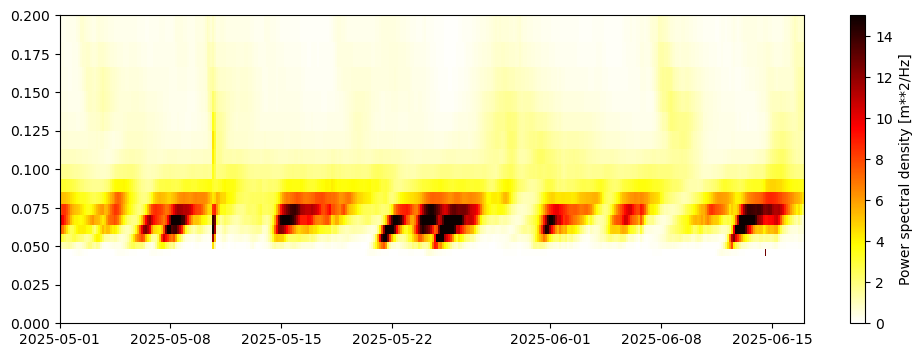

In [221]:
plt.figure(figsize=(12, 4))
# plt.pcolor(era5_wave_spectrum_sum_1pt.time, era5_wave_spectrum_sum_1pt.frequency, np.log10(era5_wave_spectrum_sum_1pt.values.T), shading='auto', cmap='hot_r', vmin=-2, vmax=3)
plt.pcolor(era5_wave_spectrum_sum_1pt.time, era5_wave_spectrum_sum_1pt.frequency, era5_wave_spectrum_sum_1pt.values.T, shading='auto', cmap='hot_r', vmax=15,)
plt.ylim(0,0.2)
plt.xlim(pd.to_datetime('2025-05-01'), pd.to_datetime('2025-06-17'))
plt.colorbar(label='Power spectral density [m**2/Hz]')

In [143]:
m0 = np.zeros(len(PSD_eta))
m0_band = np.zeros(len(PSD_eta))
# m0_band2 = np.zeros(len(PSD_eta))
m0_moum1 = np.zeros(len(PSD_eta_wave_all))
m0_moum_filtered1 = np.zeros(len(PSD_eta_moum_filtered1_all))
m0_moum_filtered2 = np.zeros(len(PSD_eta_moum_filtered2_all))
# m0_stepwize = np.zeros(len(PSD_eta))
Hs = np.zeros(len(PSD_eta))
Hs_band = np.zeros(len(PSD_eta))
# Hs_band2 = np.zeros(len(PSD_eta))
Hs_moum1 = np.zeros(len(PSD_eta_wave_all))
Hs_moum_filtered1 = np.zeros(len(PSD_eta_moum_filtered1_all))
Hs_moum_filtered2 = np.zeros(len(PSD_eta_moum_filtered2_all))
# Hs_band2 = np.zeros(len(PSD_eta))
# Hs_interpolated = np.zeros(len(PSD_eta))
# Hs_stepwize = np.zeros(len(PSD_eta))
for i in range(len(PSD_eta)):
    PSD_eta0 = PSD_eta[i]
    f_accz0 = f_accz_all[i]
    # Compute significant wave height
    # Integrate the PSD between 0.05 Hz and 0.2 Hz (typical wave frequency range)
    mask = (f_accz0 >= 0.05) & (f_accz0 <= 0.2)
    mask2 = (f_accz0 >= 0.05) & (f_accz0 <= 0.15)
    m0[i] = np.trapz(PSD_eta0, f_accz0)
    m0_band[i] = np.trapz(PSD_eta0[mask], f_accz0[mask])
    m0_moum1[i] = np.trapz(PSD_eta_wave_all[i], f_accz0)
    m0_moum_filtered1[i] = np.trapz(PSD_eta_moum_filtered1_all[i], f_accz0)
    m0_moum_filtered2[i] = np.trapz(PSD_eta_moum_filtered2_all[i], f_accz0)
    # m0_band2[i] = np.trapz(PSD_eta0[mask2], f_accz0[mask2])
    # m0_interpolated[i] = np.trapz(np.nan_to_num(PSD_eta_ro0_filtered_all[i]), f_accz0)
    # m0_stepwize[i] = np.trapz(np.nan_to_num(PSD_eta_ro0_stepwize_all[i]), f_accz0)
    Hs[i] = 4 * np.sqrt(m0[i])
    Hs_band[i] = 4 * np.sqrt(m0_band[i])
    Hs_moum1[i] = 4 * np.sqrt(m0_moum1[i])
    Hs_moum_filtered1[i] = 4 * np.sqrt(m0_moum_filtered1[i])
    Hs_moum_filtered2[i] = 4 * np.sqrt(m0_moum_filtered2[i])
    # Hs_band2[i] = 4 * np.sqrt(m0_band2[i])
    # Hs_interpolated = 4 * np.sqrt(m0_interpolated)
    # Hs_stepwize = 4 * np.sqrt(m0_stepwize)
    # print(f"Significant Wave Height: {Hs[i]:.2f} m, filtered: {Hs_band[i]:.2f} m")

# create a dataframe with the results
Hs_df = pd.DataFrame({
    'time': t_april,
    'Hs': Hs,
    'Hs_band': Hs_band,
    'Hs_moum1': Hs_moum1,
    'Hs_moum_filtered1': Hs_moum_filtered1,
    'Hs_moum_filtered2': Hs_moum_filtered2,
    # 'Hs_band2': Hs_band2,
    # 'Hs_interpolated': Hs_interpolated,
    # 'Hs_stepwize': Hs_stepwize,
    'lon': x_april,
    'lat': y_april,
    'era5_wmp': mwp_all,
    'era5_swh': swh_all,
    'era5_mwd': mwd_all,
    'chunk_id': chunk_id_all,
})
Hs_df


,time,Hs,Hs_band,Hs_moum1,Hs_moum_filtered1,Hs_moum_filtered2,lon,lat,era5_wmp,era5_swh,era5_mwd,chunk_id
0,2025-04-29 20:59:11.200,21.309132,2.396203,11.061243,2.154209,2.293821,-79.09223175048828,-8.592782020568848,11.357844,2.0902338,196.86443,7502
1,2025-05-01 16:03:05.200,25.001313,2.052575,13.803427,1.947025,2.253958,-79.1068344116211,-8.686763763427734,11.061466,1.9744596,193.36176,7581
2,2025-05-01 16:07:23.200,8.951001,1.414291,12.367972,1.453355,1.565889,-79.1068344116211,-8.686763763427734,11.061466,1.9744596,193.36176,7583
3,2025-05-03 16:03:03.200,14.894299,1.462205,13.411349,1.566415,1.726559,-79.08097076416014,-8.482622146606445,10.068494,1.9252901,194.19623,7673
4,2025-05-04 15:39:10.610,6.630859,1.381520,11.555278,1.381952,1.429183,-78.884765625,-8.666779518127441,10.9009905,1.9533339,196.71375,7740
...,...,...,...,...,...,...,...,...,...,...,...,...
479,2025-05-24 17:43:00.200,10.734618,2.946800,9.540769,2.453426,2.456880,-78.89055633544923,-8.899245262145996,13.423593,2.5015059,212.81944,37693
480,2025-05-25 12:39:28.670,11.171702,2.040035,10.369469,1.925131,2.102403,-78.66999053955078,-9.086188316345217,13.719539,2.637538,211.11206,37716
481,2025-05-25 14:39:22.200,8.066239,1.672460,2.935034,1.659629,1.501019,-78.6428985595703,-9.171944618225098,13.5798235,2.645875,210.58911,37767
482,2025-05-25 14:57:24.140,11.521886,2.242807,22.602720,1.892769,1.906824,-78.64190673828125,-9.173443794250488,13.5798235,2.645875,210.58911,37769


Text(0, 0.5, 'Hs from era5')

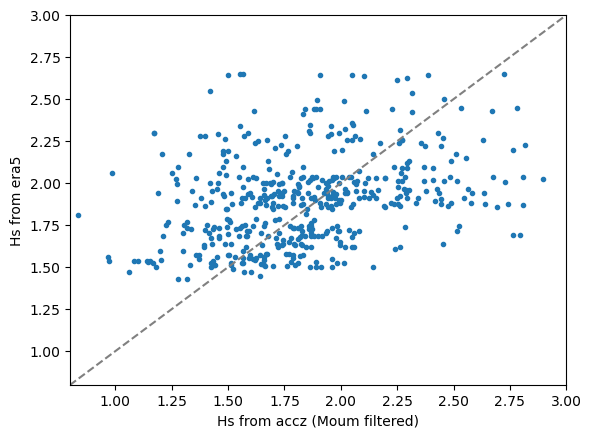

In [144]:
# plt.plot(Hs_df['Hs_moum_filtered2'], Hs_df['era5_swh'],'.',color='tab:blue')
plt.plot(Hs_df['Hs_moum_filtered2'], Hs_df['era5_swh'],'.',color='tab:blue')
plt.plot([0,3],[0,3],'--',color = 'grey')
plt.xlim(0.8,3)
plt.ylim(0.8,3)
plt.xlabel('Hs from accz (Moum filtered)')
plt.ylabel('Hs from era5')

# print(np.corrcoef(Hs_df['Hs_moum_filtered1'], Hs_df['era5_swh']))

In [145]:
depth00 = get_depths_at_locations(Hs_df['lon'], Hs_df['lat'], bath1_region)
Hs_df['depth'] = depth00

# Print the updated dataframe
print(f"Added depths to {len(Hs_df)} locations")

Added depths to 484 locations


Text(0, 0.5, 'Hs from era5')

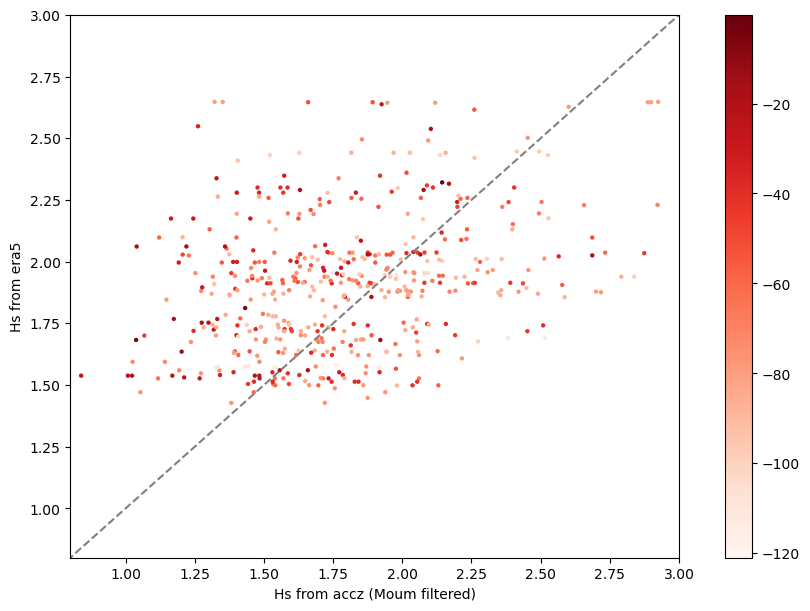

In [146]:
# plt.plot(Hs_df['Hs_band'], Hs_df['era5_swh'],'.',color='tab:blue')
fig = plt.figure(figsize=(8,6), constrained_layout=True)
plt.scatter(Hs_df['Hs_moum_filtered1'], Hs_df['era5_swh'],s=10, c=Hs_df['depth'], cmap='Reds', edgecolor='none')
plt.colorbar()
plt.plot([0,3],[0,3],'--',color = 'grey')
plt.xlim(0.8,3)
plt.ylim(0.8,3)
plt.xlabel('Hs from accz (Moum filtered)')
plt.ylabel('Hs from era5')

In [147]:
depth1 = 158
g=9.81

# Add the 'Hs0' column to the DataFrame if it doesn't exist
if 'Hs0' not in Hs_df.columns:
    Hs_df['Hs0'] = np.nan

for k in range(len(Hs_df)):
# for k in [3]:
    t_bird = Hs_df['time'].iloc[k]
    # h_bird = -Hs_df['depth'].iloc[k]
    h_bird = -Hs_df['depth'].iloc[k]

    # # depth1 = ds_era5_hor.wmb.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # swh1 = ds_era5_hor.swh.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # mwd1 = ds_era5_hor.mwd.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # mwp1 = ds_era5_hor.mwp.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # print(k,swh1,mwd1,mwp1)
    swh1 = Hs_df['era5_swh'].iloc[k]
    mwd1 = Hs_df['era5_mwd'].iloc[k]
    mwp1 = Hs_df['era5_wmp'].iloc[k]

    k1 = wavenumber(mwp1,depth1,g)
    cel1 = waveCel(k1,mwp1)
    n1 = nRatio(k1,depth1)
    cg1 = waveGroupSpeed(cel1,n1)

    k2 = wavenumber(mwp1,h_bird,g)
    cel2 = waveCel(k2,mwp1)
    n2 = nRatio(k2,h_bird)
    cg2 = waveGroupSpeed(cel2,n2)

    theta1 = 240-mwd1
    theta_bird = Snell(theta1,cel1,cel2)

    h2 = swh1*np.sqrt(cg1*np.cos(np.radians(theta1))/(cg2*np.cos(np.radians(theta_bird))))
    # print(k1,k2,cel1,cel2,n1,n2,cg1,cg2,theta1,theta_bird,h_bird,swh1,mwd1,mwp1,h2)
    print(depth1, h_bird,k1,k2,cel1, cel2, theta1,theta_bird,mwd1,cg1,cg2,h2)
    print(n1,n2)
    print(h2,swh1)
    # Hs_df.at[k, 'Hs'] = h2
    Hs_df.at[k, 'Hs0'] = h2

158 61.4033050537104 0.031199261880091388 0.032387227111688725 17.731261549544545 17.08087792267284 43.13557434082031 41.19683143382624 196.86443 8.874769301381669 9.81367886626315 1.9574997903233333
0.5005153906609443 0.5745418303842951
1.9574997903233333 2.0902338
158 71.0 0.03289212522312031 0.0334631645559892 17.26931996174543 16.974623955527765 46.63824462890625 45.612599790248034 193.36176 8.640155842803 9.183971687057493 1.897363958562057
0.5003182442587467 0.5410412455155889
1.897363958562057 1.9744596
158 71.0 0.03289212522312031 0.0334631645559892 17.26931996174543 16.974623955527765 46.63824462890625 45.612599790248034 193.36176 8.640155842803 9.183971687057493 1.897363958562057
0.5003182442587467 0.5410412455155889
1.897363958562057 1.9744596
158 56.2622985839812 0.039697652095476016 0.0405357114487733 15.719927480431858 15.394924371141924 45.80377197265625 44.598444208703775 194.19623 7.860666672560468 8.431263013547904 1.8394115747470594
0.5000447160042827 0.5476651141822

Text(0, 0.5, 'Hs from era5')

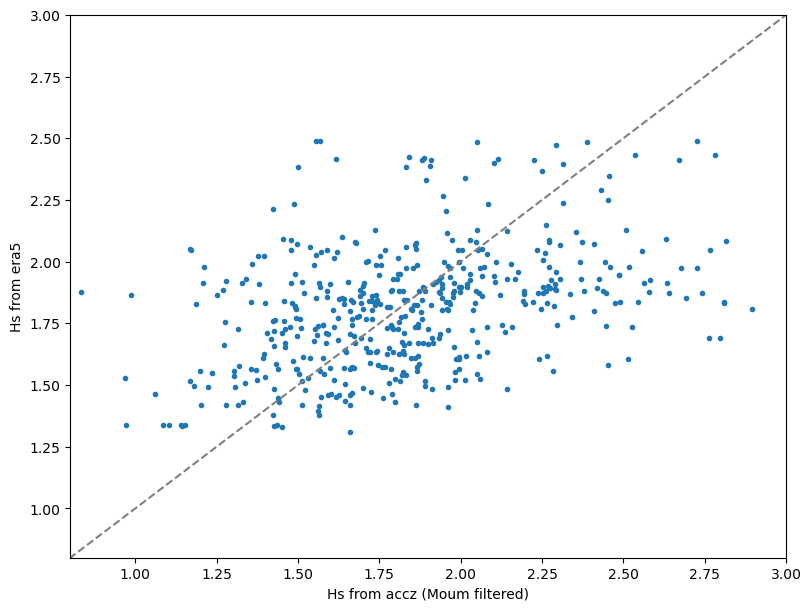

In [148]:
# plt.plot(Hs_df['Hs_band'], Hs_df['era5_swh'],'.',color='tab:blue')
fig = plt.figure(figsize=(8,6), constrained_layout=True)
plt.plot(Hs_df['Hs_moum_filtered2'], Hs_df['Hs0'],'.',color='tab:blue')
# plt.scatter(Hs_df['Hs_moum_filtered2'], Hs_df['Hs0'],s=10, c=Hs_df['depth'], cmap='Reds', edgecolor='none')
# plt.plot(Hs_df['Hs_moum_filtered'], Hs_df['era5_swh'],'.',color='tab:orange',label='Hs from accz (Moum filtered)')
# plt.plot(Hs_df['Hs_moum_filtered'], Hs_df['Hs0'],'.',color='tab:blue',label='Hs from ERA5 (depth adjusted)')
# plt.colorbar()
plt.plot([0,3],[0,3],'--',color = 'grey')
plt.xlim(0.8,3)
plt.ylim(0.8,3)
plt.xlabel('Hs from accz (Moum filtered)')
plt.ylabel('Hs from era5')

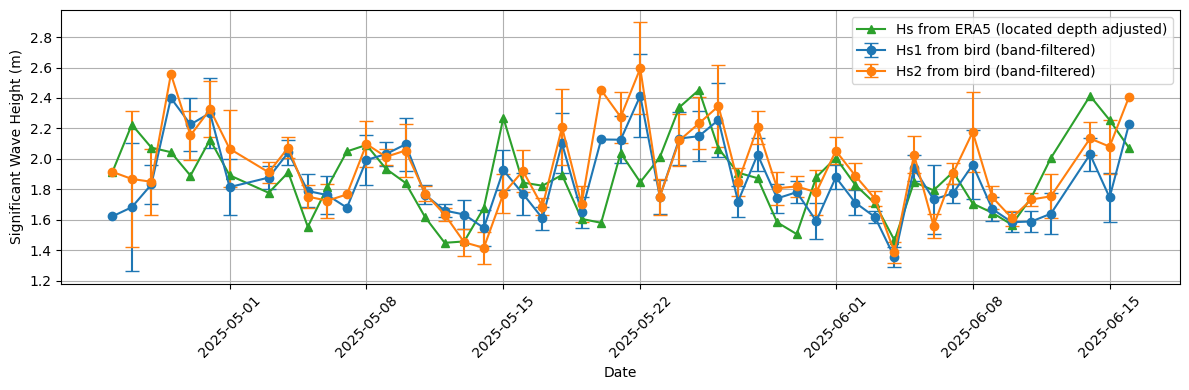

In [217]:
# Convert time to date for grouping
Hs_df['date'] = Hs_df['time'].dt.date

# Group by date and calculate daily averages
daily_avg = Hs_df.groupby('date').agg({
    'Hs': 'mean',
    'Hs_moum_filtered1': 'mean',
    'Hs_moum_filtered2': 'mean',
    # 'Hs_band2': 'mean',
    # 'Hs_interpolated': 'mean',
    # 'Hs_stepwize': 'mean',
    'Hs0': 'mean',  # Uncomment if you have Hs0 in your DataFrame
    'era5_swh': 'mean',
    'era5_wmp': 'mean',
    'era5_mwd': 'mean',
    # 'era5_swh2': 'mean',
    # 'era5_wmp2': 'mean',
    # 'era5_mwd2': 'mean',
    'lon': 'mean',
    'lat': 'mean',
    # 'depth': 'mean'
}).reset_index()
# Calculate standard deviation (variance) for each day
# daily_variance = Hs_df.groupby('date').agg({
#     'Hs': 'std',
#     'Hs_moum_filtered1':'std',
#     'Hs_moum_filtered2':'std',
#     'Hs0': 'std', 
#     'era5_swh': 'std'
# }).reset_index()
daily_variance = Hs_df.groupby('date').agg({
    'Hs': 'sem',
    'Hs_moum_filtered1':'sem',
    'Hs_moum_filtered2':'sem',
    'Hs0': 'sem', 
    'era5_swh': 'sem'
}).reset_index()


# Rename columns to make it clear they are standard deviations
# daily_variance = daily_variance.rename(columns={
#     'Hs': 'Hs_std',
#     'Hs0': 'Hs0_std',  # Uncomment if you have Hs0 in your DataFrame
#     # 'Hs_band': 'Hs_band_std',
#     # 'Hs_band2': 'Hs_band2_std',
#     'Hs_moum_filtered1': 'Hs_moum_filtered1_std',
#     'Hs_moum_filtered2': 'Hs_moum_filtered2_std',
#     # 'Hs_interpolated': 'Hs_interpolated_std',
#     # 'Hs_stepwize': 'Hs_stepwize_std',
#     'era5_swh': 'era5_swh_std'
# })
daily_variance = daily_variance.rename(columns={
    'Hs': 'Hs_sem',
    'Hs0': 'Hs0_sem',  # Uncomment if you have Hs0 in your DataFrame
    # 'Hs_band': 'Hs_band_std',
    # 'Hs_band2': 'Hs_band2_std',
    'Hs_moum_filtered1': 'Hs_moum_filtered1_sem',
    'Hs_moum_filtered2': 'Hs_moum_filtered2_sem',
    # 'Hs_interpolated': 'Hs_interpolated_std',
    # 'Hs_stepwize': 'Hs_stepwize_std',
    'era5_swh': 'era5_swh_sem'
})


# Merge the variance data with the average data
daily_avg = daily_avg.merge(daily_variance, on='date')
# Calculate number of observations per day
obs_count = Hs_df.groupby('date').size().reset_index(name='count')
daily_avg = daily_avg.merge(obs_count, on='date')

# Calculate correlation between bird-derived Hs and ERA5 Hs
# corr_hs_era5 = Hs_df['Hs_band'].corr(Hs_df['era5_swh'])
# corr_hs0_era5 = Hs_df['Hs0'].corr(Hs_df['era5_swh'])

# Plot daily averages
fig, ax = plt.subplots(figsize=(12, 4))
# ax.errorbar(daily_avg['date'], daily_avg['Hs_moum_filtered1'], 
#             yerr=daily_avg['Hs_moum_filtered1_std'], fmt='o-', label='Hs1 from bird (band-filtered)', capsize=5)
ax.errorbar(daily_avg['date'], daily_avg['Hs_moum_filtered1'], 
            yerr=daily_avg['Hs_moum_filtered1_sem'], fmt='o-', label='Hs1 from bird (band-filtered)', capsize=5)

# ax.plot(daily_avg['date'], daily_avg['Hs_moum_filtered1'], 'o-', label='Hs1 from bird (band-filtered)')
ax.errorbar(daily_avg['date'], daily_avg['Hs_moum_filtered2'], 
            yerr=daily_avg['Hs_moum_filtered2_sem'], fmt='o-', label='Hs2 from bird (band-filtered)', capsize=5)

# ax.errorbar(daily_avg['date'], daily_avg['Hs_stepwize'], 
#             yerr=daily_avg['Hs_stepwize_std'], fmt='o-', label='Hs from bird (stepwize-filtered)', capsize=5)
# ax.plot(daily_avg['date'], daily_avg['Hs_interpolated'], 'o-', label='Hs from bird (era5-filtered)')
# ax.plot(daily_avg['date'], daily_avg['Hs0'], 's-', label='Hs from ERA5')
ax.plot(daily_avg['date'], daily_avg['Hs0'], '^-', label='Hs from ERA5 (located depth adjusted)')
# ax.plot(daily_avg['date'], daily_avg['era5_swh'], 'o-', label='Hs from ERA5 (raw)', color='tab:red')
# ax.plot(daily_avg['date'], daily_avg['Hs0'], '^-', label='Hs adjusted for depth')

# Add count as text above each point
# for i, row in daily_avg.iterrows():
#     ax.annotate(f"n={row['count']}", 
#                 (row['date'], max(row['Hs_moum_filtered1'], row['Hs_moum_filtered1'])+0.1), 
#                 ha='center')

ax.set_xlabel('Date')
ax.set_ylabel('Significant Wave Height (m)')
# ax.set_title(f'Daily Average Significant Wave Height\nCorrelation: {corr_hs_era5:.2f} (raw), {corr_hs0_era5:.2f} (depth-adjusted)')
ax.legend()
ax.grid(True)

# Rotate date labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
# plt.ylim(0,5)

Text(0, 0.5, 'Hs from era5')

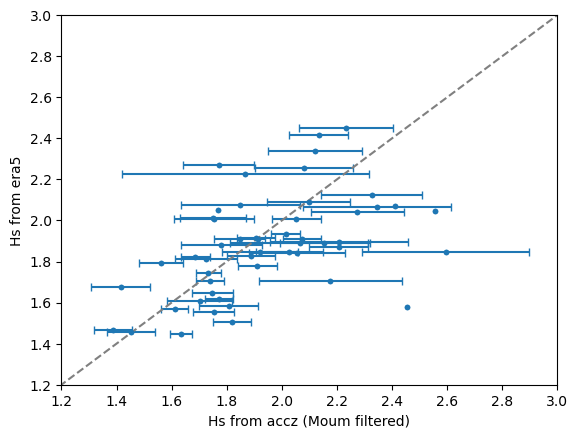

In [220]:
# plt.plot(daily_avg['Hs_moum_filtered1'], daily_avg['era5_swh'],'.',color='tab:blue')
plt.plot(daily_avg['Hs_moum_filtered2'], daily_avg['Hs0'],'.',color='tab:blue',label='Hs from accz transfer function (band-filtered)')
plt.errorbar(daily_avg['Hs_moum_filtered2'], daily_avg['Hs0'], 
             xerr=daily_avg['Hs_moum_filtered2_sem'], 
            #  yerr=daily_avg['Hs0_sem'],
             fmt='.', color='tab:blue', 
             label='Hs from accz (transfer function filtered)', 
             capsize=3)
# plt.plot(daily_avg['Hs_moum_filtered2'], daily_avg['Hs0'],'.',color='tab:red',label='Hs from ERA5 (transfer function and Rot)')
# plt.plot(daily_avg['Hs_moum_filtered2'], daily_avg['era5_swh'],'.',color='tab:orange')
plt.plot([1,3],[1,3],'--',color = 'grey')
plt.xlim(1.2,3)
plt.ylim(1.2,3)
# plt.legend()
plt.xlabel('Hs from accz (Moum filtered)')
plt.ylabel('Hs from era5')

In [497]:
np.corrcoef(daily_avg['Hs_moum_filtered2'], daily_avg['Hs0'])

array([[1.        , 0.48627132],
       [0.48627132, 1.        ]])

In [498]:
np.corrcoef(daily_avg['Hs_moum_filtered1'], daily_avg['era5_swh'])

array([[1.        , 0.44152226],
       [0.44152226, 1.        ]])

## NEW: USING ACC Whitenoise FLOOR (20250710)

In [164]:
plt_flg = 1

grav0 = 9.81  # m/s^2
# swh_era5_1pt = era5_wave.isel(longitude=3, latitude=4)
# swh_era5_1pt2 = era5_wave.isel(longitude=4, latitude=5)
swh_era5_2 = era5_wave2.isel(longitude=2, latitude=3)
swh_era5_3 = era5_wave3.isel(longitude=4, latitude=6)

# from scipy.signal import welch
sample_rate = 5
order=4
icount=0
for i in rec_list2_ok[0:10]:
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]

    # if (np.max(chunk00['accz'].values)<1500)&(np.min(chunk00['accz'].values)>500):
    accz_1 = chunk00["accz"].values/1000*9.81
    accx_1 = chunk00["accx"].values/1000*9.81
    accy_1 = chunk00["accy"].values/1000*9.81
    accz_1_sub = chunk00['accz'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accx_1_sub = chunk00['accx'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accy_1_sub = chunk00['accy'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    
    accz_wave = accz_1_sub - grav0*np.sqrt(1-(accx_1_sub/grav0)**2 - (accy_1_sub/grav0)**2)

    f_accz_detrend, Pxx_accz_detrend = power_spectral_density_fft(signal.detrend(accz_1_sub))
    # f_accx_detrend, Pxx_accx_detrend = power_spectral_density_fft(signal.detrend(accx_1_sub))
    # f_accy_detrend, Pxx_accy_detrend = power_spectral_density_fft(signal.detrend(accy_1_sub))

    f_accz_rot, Pxx_accz_rot = power_spectral_density_fft(signal.detrend(accz_wave)) #(rotation based on Moum et al. 2023)

    # Calculate low frequency components (f < 0.05 Hz) for Moum's method
    f_low_indices = np.where(f_accz_rot < 0.05)[0]
    Pxx_accz_rot_low = Pxx_accz_rot[f_low_indices]
    f_accz_rot_low = f_accz_rot[f_low_indices]

    # Calculate mean power in the low frequency band
    mean_power_low = np.mean(Pxx_accz_rot_low[1:])
    max_power_low = np.max(Pxx_accz_rot_low[1:])

    Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_d = np.where(f_accz_detrend>0, Pxx_z_eta_d, 0)
    Pxx_z_eta_rot = Pxx_accz_rot/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_rot = np.where(Pxx_z_eta_rot>0, Pxx_z_eta_rot, 0)
    # transfunc = (1-1/(1+(f_accz_detrend/(1/27))**4))**6  # transfer function for 23s filter (Moum et al. 2023)
    # Pxx_z_eta_d_filtered1 = Pxx_z_eta_d * transfunc
    # Pxx_z_eta_d_filtered2 = Pxx_z_eta_moum * transfunc

    Pxx_accz_whitenoise = Pxx_accz_detrend*0+ 0.1
    Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
    Pxx_accz_mean_power_low = Pxx_accz_detrend*0+ mean_power_low
    Pxx_z_eta_mean_power_low = Pxx_accz_mean_power_low/(2*np.pi*f_accz_detrend)**4

    Pxx_z_eta_dmean_power_low = Pxx_z_eta_rot - Pxx_z_eta_mean_power_low
    Pxx_z_eta_dmean_power_low = np.where(Pxx_z_eta_dmean_power_low>0, Pxx_z_eta_dmean_power_low, 0)
    Pxx_z_eta_dmean_power_low = np.where(f_accz_rot>0.04, Pxx_z_eta_dmean_power_low, 0)


    # Pxx_z_eta_d

    mwp_chunk = swh_era5_3.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    swh_chunk = swh_era5_3.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    mwd_chunk = swh_era5_3.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    # # spectrum_chunk = era5_peru_mean.sel(time=chunk00.iloc[0].original_time,method='nearest')
    spectrum_chunk = era5_wave_spectrum_sum_1pt.sel(time=chunk00.iloc[0].original_time,method='nearest')    
    spectrum_chunk_interpolated = spectrum_chunk.interp(frequency=f_accz_detrend, method='linear')

    if icount == 0:
        PSD_acc = [Pxx_accz_detrend]
        f_accz_all = [f_accz_detrend]
        PSD_eta = [Pxx_z_eta_d]
        PSD_eta_wave_all = [Pxx_z_eta_rot]
        PSD_eta_dmean_power_low =[Pxx_z_eta_dmean_power_low]
        # PSD_eta_moum_filtered1_all = [Pxx_z_eta_d_filtered1]
        # PSD_eta_moum_filtered2_all = [Pxx_z_eta_d_filtered2]
        t_april = [chunk00['original_time'].iloc[0]]
        x_april = [chunk00['lon'].iloc[0]]
        y_april = [chunk00['lat'].iloc[0]]
        mwp_all = [mwp_chunk]
        swh_all = [swh_chunk]
        mwd_all = [mwd_chunk]
        chunk_id_all = [i]
    else:
        PSD_acc.append(Pxx_accz_detrend)
        f_accz_all.append(f_accz_detrend)
        PSD_eta.append(Pxx_z_eta_d)
        PSD_eta_wave_all.append(Pxx_z_eta_rot)
        PSD_eta_dmean_power_low.append(Pxx_z_eta_dmean_power_low)
        # PSD_eta_moum_filtered1_all.append(Pxx_z_eta_d_filtered1)
        # PSD_eta_moum_filtered2_all.append(Pxx_z_eta_d_filtered2)
        t_april.append(chunk00['original_time'].iloc[0])
        x_april.append(chunk00['lon'].iloc[0])
        y_april.append(chunk00['lat'].iloc[0])
        mwp_all.append(mwp_chunk)
        swh_all.append(swh_chunk)
        mwd_all.append(mwd_chunk)
        chunk_id_all.append(i)
    icount += 1
    if plt_flg == 1:
        fig = plt.figure(figsize=(12,6),constrained_layout=True)

        gs = fig.add_gridspec(1, 2, width_ratios=[1,1])
        # axs1 = fig.add_subplot(gs[0,0])
        axs2 = fig.add_subplot(gs[0,0])
        axs3 = fig.add_subplot(gs[0,1])
        # axs1.plot(np.arange(len(accz_1_sub))/5,accz_1_sub-9.81,label = 'RAW accz-g')
        # axs1.plot(np.arange(len(accz_wave))/5,accz_wave,label = 'acc wave')
        # axs1.plot(np.arange(len(accz_wave))/5,accz_1_sub-9.81-accz_wave,label = 'RAW_accz-acc_wave')
        # axs1.set_xlabel('Time [s]')
        # axs1.set_ylabel('accz [m/s^2]')
        # axs1.legend()
        # axs1.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')

        # axs2.plot(f_accz, Pxx_accz,label='Rotated accz (FFT)')
        # axs2.plot(f_accz_detrend, Pxx_accz_detrend,'b',label='Non-rot accz (FFT)')
        # axs2.plot(f_accz_ro0, Pxx_accz_ro0,'r',label='Non-rot accz (FFT rotated)')
        # axs2.plot(f_accz_detrend, Pxx_accz_whitenoise,'g',label='whitenoise accz (FFT) = 0.1')
        axs2.plot(f_accz_rot, Pxx_accz_rot,'r',label='Rotated accz (Moum)')
        axs2.plot(acc_spectrum_era5.frequency, acc_spectrum_era5,'--',color='k',label='ERA5 spectrum')
        # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
        # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
        axs2.axvline(x=0.05, color='r', linestyle='--')
        axs2.axvline(x=0.2, color='r', linestyle='--')
        axs2.axhline(y=mean_power_low, color='b', label='mean power low freq band')
        # axs2.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
        # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
        axs2.set_xscale('log')
        axs2.set_xlabel('Freq [Hz]')
        axs2.set_ylabel('Power spectral density [acc**2/Hz]')
        axs2.set_title(f'WhiteNoise = {mean_power_low} ')
        axs2.set_ylim(1e-4,10)
        axs2.set_yscale('log')
        axs2.legend(loc='lower right')
        # axs22 = axs2.twinx()
        # axs2.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'g',label='mean_power')
        # To set the color of the tick labels, we need to get the current labels first
        # axs22.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

        # axs3.plot(f_accz, Pxx_z_eta,label='PSD eta')
        # axs3.plot(f_accz_detrend, Pxx_z_eta_d,label='FFT eta')
        axs3.plot(f_accz_rot, Pxx_z_eta_rot,'r',label='FFT eta (Rotation)')
        # axs3.plot(f_accz_detrend, Pxx_z_eta_d_filtered1,'g',label='FFT eta (transfer function')
        # axs3.plot(f_accz_detrend, Pxx_z_eta_d_filtered2,'b',label='FFT eta (Rotation+transfunc)')
        # axs3.plot(f_accz_ro0, Pxx_z_eta_ro0,'r',label='FFT eta rotated')
        # axs3.plot(f_accz_detrend, Pxx_z_eta_whitenoise,'g',label='FFT eta whitenoise')
        axs3.plot(f_accz_detrend, Pxx_z_eta_mean_power_low,'b',label='FFT eta mean power low freq band')
        axs3.plot(f_accz_detrend, Pxx_z_eta_dmean_power_low,'m',label='FFT eta mean power low freq band (detrended)')
        # # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
        # # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
        # # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
        axs3.axvline(x=0.05, color='r', linestyle='--')
        axs3.axvline(x=0.2, color='r', linestyle='--')
        # # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--',linewidth=2)
        # # axs3.plot(da.frequency, mean_power[0].values,color = 'orange',label='mean_power')
        axs3.plot(spectrum_chunk.frequency, spectrum_chunk,'--',color='k',label='era5 spectrum')
        # axs3.plot(f_accz_detrend, spectrum_chunk_interpolated_normolized*Pxx_z_eta_ro0,'g',label='FFT eta (era5 spectrum filtered)')
        # axs3.plot(f_accz_detrend, spectrum_chunk_interpolated_stepwize,'c',label='Filter (era5 spectrum filtered)')
        # axs3.plot(f_accz_detrend, PSD_eta_ro0_stepwize,'m',label='FFT eta (era5 spectrum stepwize filtered)')
        # # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
        # # axs3.axhline(y=swh_chunk**2, color='b', linestyle='--', label='swh',linewidth=2)
        # # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
        axs3.set_xscale('log')
        axs3.set_xlabel('Freq [Hz]')
        axs3.set_ylabel('Power spectral density [acc**2/Hz]')
        axs3.set_yscale('log')
        axs3.set_ylim(0,30000)
        axs3.legend(loc='upper right')
        fig.savefig(f'chunk_frequency_100s_all_tags_v4/add_moum_06/chunk_spectrum_accz_{i}.png')
        plt.close()

/tmp/ipykernel_375203/3962359942.py:41: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_375203/3962359942.py:43: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_rot = Pxx_accz_rot/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_375203/3962359942.py:50: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_375203/3962359942.py:52: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_mean_power_low = Pxx_accz_mean_power_low/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_375203/3962359942.py:54: RuntimeWarning: invalid value encountered in subtract
  Pxx_z_eta_dmean_power_low = Pxx_z_eta_rot - Pxx_z_eta_mean_power_low
/tmp/ipykernel_375203/3962359942.py:167: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs3.set_ylim(0,30000)
/tmp/ipykernel_375203/3962359942.py:41:

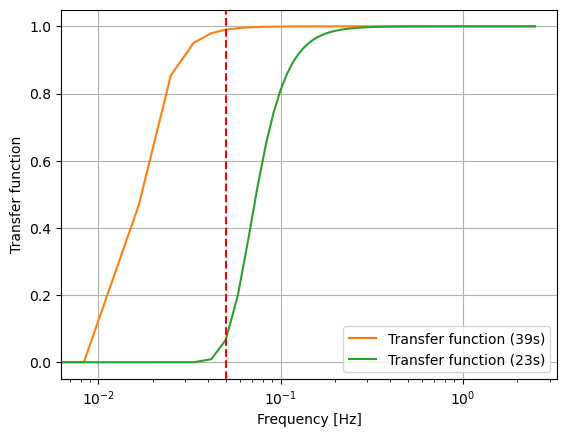

In [82]:
transfunc_plt_39 = (1-1/(1+(f_accz_int/(1/99))**4))**6  # transfer function for 39s filter (Moum et al. 2023)
transfunc_plt_23 = (1-1/(1+(f_accz_int/(1/23))**4))**6  # transfer function for 23s filter (Moum et al. 2023)
plt.plot(f_accz_int,transfunc_plt_39,label='Transfer function (39s)', color='tab:orange')
plt.plot(f_accz_int,transfunc_plt_23,label='Transfer function (23s)', color='tab:green')
plt.axvline(x=0.05, color='r', linestyle='--')
plt.xscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Transfer function')
plt.legend()
plt.grid()

In [108]:
# faccz_max=[]
# for i in range(len(PSD_eta)):
#     f_accz0 = f_accz_all[i]
#     faccz_max.append(np.max(f_accz0))
#     print(f_accz0.shape)
#     print(np.max(f_accz0),np.min(f_accz0))

# print(np.max(faccz_max))

f_accz_int = f_accz_all[0]
# PSD_eta_moum_filtered1_all_int = np.zeros((len(PSD_eta), len(f_accz_int)))
# PSD_eta_moum_filtered2_all_int = np.zeros((len(PSD_eta), len(f_accz_int)))
# PSD_eta_dmean_power_low_int = np.zeros((len(PSD_eta), len(f_accz_int)))
PSD_eta_dmean_power_low_int = [PSD_eta_dmean_power_low[0]]
for i in range(len(PSD_eta)):
    f_accz0 = f_accz_all[i]
    # Skip the first iteration since we're already using it as reference
    if i == 0:
        continue
        
    # Interpolate PSD_eta_moum_filtered1_all[i] to match the frequency points in f_accz_int
    
    # Create interpolation function (use 'linear' for linear interpolation)
    interp_func = interp1d(f_accz0, PSD_eta_dmean_power_low[i], 
                          bounds_error=False, fill_value=0)
    
    # Replace the original array with the interpolated version
    # PSD_eta_dmean_power_low_int[i] = interp_func(f_accz_int)
    PSD_eta_dmean_power_low_int.append(interp_func(f_accz_int))

    # Do the same for PSD_eta_moum_filtered2_all if needed
    # interp_func2 = interp1d(f_accz0, PSD_eta_moum_filtered2_all[i], 
    #                        bounds_error=False, fill_value=0)
    # PSD_eta_moum_filtered2_all_int[i] = interp_func2(f_accz_int)


    # interp_func3 = interp1d(f_accz0, PSD_eta_wave_all[i], 
    #                        bounds_error=False, fill_value=0)
    # PSD_eta_wave_all_int[i] = interp_func3(f_accz_int)

In [111]:
PSD_df = pd.DataFrame({
    'time': t_april,
    'PSD_dmean1': PSD_eta_dmean_power_low_int,
    # 'PSD_filter2': PSD_eta_moum_filtered2_all,
})
PSD_df['date'] = PSD_df['time'].dt.date
PSD_df
PSD_daily_avg = PSD_df.groupby('date').agg({
    'PSD_dmean1': 'mean',
    # 'PSD_filter2': 'mean',
    }).reset_index()
PSD_daily_avg

,date,PSD_dmean1
0,2025-04-25,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.32399454392641563,..."
1,2025-04-26,"[0.0, 0.0, 0.0, 0.0, 0.0, 8.093052232652997, 9..."
2,2025-04-27,"[0.0, 0.0, 0.0, 0.0, 0.0, 4.641124778112384, 1..."
3,2025-04-28,"[0.0, 0.0, 0.0, 0.0, 0.16755232232188533, 1.46..."
4,2025-04-29,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5515050805359..."
5,2025-04-30,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 18.0214367..."
6,2025-05-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.8462966164308..."
7,2025-05-03,"[0.0, 0.0, 0.0, 0.0, 0.08567973022475965, 1.34..."
8,2025-05-04,"[0.0, 0.0, 0.0, 0.0, 0.22652855013776246, 1.55..."
9,2025-05-05,"[0.0, 0.0, 0.0, 0.0, 0.15447509880453777, 1.35..."


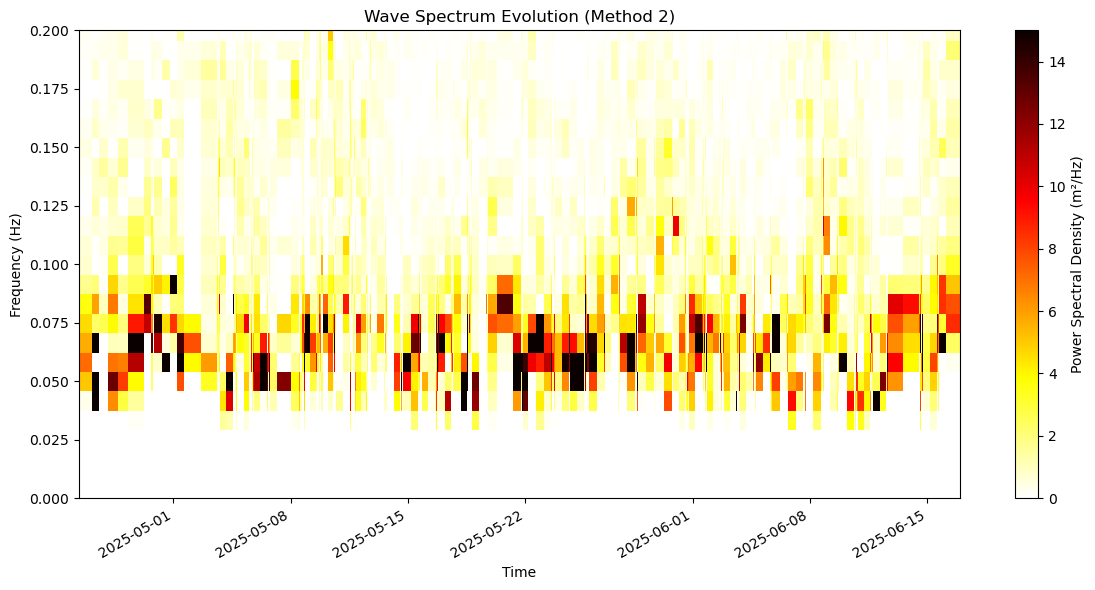

In [112]:
# Sort the PSD dataframe by time to ensure chronological order
PSD_df_sorted = PSD_df.sort_values(by='time')

# Convert the time values to a format suitable for plotting
time_values = pd.to_datetime(PSD_df_sorted['time'])

# Create the frequency-time heatmap plot
# plt.figure(figsize=(12, 6))
# plt.pcolor(time_values, f_accz_int, np.array([psd for psd in PSD_df_sorted['PSD_filter1']]).T, 
#            cmap='viridis', vmax=15, shading='auto')

# # Customize the plot
# plt.ylim(0, 0.2)  # Focus on the frequency range of interest
# plt.colorbar(label='Power Spectral Density (m²/Hz)')
# plt.xlabel('Time')
# plt.ylabel('Frequency (Hz)')
# plt.title('Wave Spectrum Evolution (Moum Filtered)')

# # Format the time axis to show dates clearly
# plt.gcf().autofmt_xdate()
# plt.tight_layout()

# Create a second plot for comparison with the second filter method
plt.figure(figsize=(12, 6))
plt.pcolor(time_values, f_accz_int, np.array([psd for psd in PSD_df_sorted['PSD_dmean1']]).T, 
           cmap='hot_r', vmax=15, shading='auto')

# Customize the second plot
plt.ylim(0, 0.2)
plt.colorbar(label='Power Spectral Density (m²/Hz)')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Wave Spectrum Evolution (Method 2)')
plt.gcf().autofmt_xdate()
plt.tight_layout()

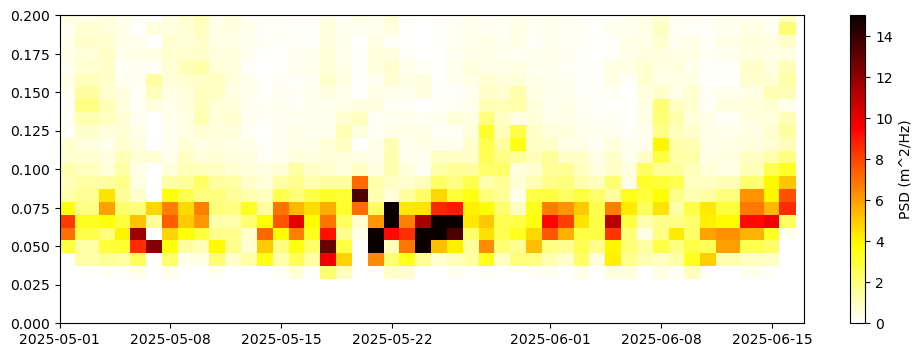

In [114]:
psd1_values = np.array([psd for psd in PSD_daily_avg['PSD_dmean1']])

plt.figure(figsize=(12, 4))
plt.pcolor(PSD_daily_avg.date, f_accz_int,  psd1_values.T, cmap='hot_r', vmax=15,)
# plt.pcolor(time_values, f_accz_int,   np.array([psd for psd in PSD_df_sorted['PSD_filter2']]).T, cmap='hot_r', vmax=15,)
plt.ylim(0,0.2)
# plt.xlim(pd.to_datetime('2025-05-01'), pd.to_datetime('2025-05-27'))
plt.xlim(pd.to_datetime('2025-05-01'), pd.to_datetime('2025-06-17'))
plt.colorbar(label='PSD (m^2/Hz)')
# plt.xscale('log')

In [124]:
m0 = np.zeros(len(PSD_eta))
m0_dmean1 = np.zeros(len(PSD_eta_dmean_power_low))
Hs = np.zeros(len(PSD_eta))
# Hs_band2 = np.zeros(len(PSD_eta))
Hs_dmean1 = np.zeros(len(PSD_eta_dmean_power_low))

for i in range(len(PSD_eta)):
    PSD_eta0 = PSD_eta[i]
    f_accz0 = f_accz_all[i]
    # Compute significant wave height
    # Integrate the PSD between 0.05 Hz and 0.2 Hz (typical wave frequency range)
    m0[i] = np.trapz(PSD_eta0, f_accz0)
    m0_dmean1[i] = np.trapz(PSD_eta_dmean_power_low[i], f_accz0)
    # m0_stepwize[i] = np.trapz(np.nan_to_num(PSD_eta_ro0_stepwize_all[i]), f_accz0)
    Hs[i] = 4 * np.sqrt(m0[i])
    Hs_dmean1[i] = 4 * np.sqrt(m0_dmean1[i])
    # Hs_band2[i] = 4 * np.sqrt(m0_band2[i])
    # Hs_interpolated = 4 * np.sqrt(m0_interpolated)
    # Hs_stepwize = 4 * np.sqrt(m0_stepwize)
    # print(f"Significant Wave Height: {Hs[i]:.2f} m, filtered: {Hs_band[i]:.2f} m")

# create a dataframe with the results
Hs_df_dmean = pd.DataFrame({
    'time': t_april,
    'Hs': Hs,
    'Hs_dmean1': Hs_dmean1,
    'lon': x_april,
    'lat': y_april,
    'era5_wmp': mwp_all,
    'era5_swh': swh_all,
    'era5_mwd': mwd_all,
    'chunk_id': chunk_id_all,
})
Hs_df_dmean


,time,Hs,Hs_dmean1,lon,lat,era5_wmp,era5_swh,era5_mwd,chunk_id
0,2025-04-29 20:59:11.200,21.309132,2.480242,-79.09223175048828,-8.592782020568848,11.357844,2.0902338,196.86443,7502
1,2025-05-01 16:03:05.200,25.001313,2.789196,-79.1068344116211,-8.686763763427734,11.061466,1.9744596,193.36176,7581
2,2025-05-01 16:07:23.200,8.951001,1.619605,-79.1068344116211,-8.686763763427734,11.061466,1.9744596,193.36176,7583
3,2025-05-03 16:03:03.200,14.894299,1.790246,-79.08097076416014,-8.482622146606445,10.068494,1.9252901,194.19623,7673
4,2025-05-04 15:39:10.610,6.630859,1.460085,-78.884765625,-8.666779518127441,10.9009905,1.9533339,196.71375,7740
...,...,...,...,...,...,...,...,...,...
479,2025-05-24 17:43:00.200,10.734618,3.992684,-78.89055633544923,-8.899245262145996,13.423593,2.5015059,212.81944,37693
480,2025-05-25 12:39:28.670,11.171702,3.001610,-78.66999053955078,-9.086188316345217,13.719539,2.637538,211.11206,37716
481,2025-05-25 14:39:22.200,8.066239,1.677102,-78.6428985595703,-9.171944618225098,13.5798235,2.645875,210.58911,37767
482,2025-05-25 14:57:24.140,11.521886,2.038257,-78.64190673828125,-9.173443794250488,13.5798235,2.645875,210.58911,37769


In [125]:
depth00 = get_depths_at_locations(Hs_df_dmean['lon'], Hs_df_dmean['lat'], bath1_region)
Hs_df_dmean['depth'] = depth00

# Print the updated dataframe
print(f"Added depths to {len(Hs_df_dmean)} locations")

Added depths to 484 locations


In [126]:
Hs_df_dmean

,time,Hs,Hs_dmean1,lon,lat,era5_wmp,era5_swh,era5_mwd,chunk_id,depth
0,2025-04-29 20:59:11.200,21.309132,2.480242,-79.09223175048828,-8.592782020568848,11.357844,2.0902338,196.86443,7502,-61.403305
1,2025-05-01 16:03:05.200,25.001313,2.789196,-79.1068344116211,-8.686763763427734,11.061466,1.9744596,193.36176,7581,-71.000000
2,2025-05-01 16:07:23.200,8.951001,1.619605,-79.1068344116211,-8.686763763427734,11.061466,1.9744596,193.36176,7583,-71.000000
3,2025-05-03 16:03:03.200,14.894299,1.790246,-79.08097076416014,-8.482622146606445,10.068494,1.9252901,194.19623,7673,-56.262299
4,2025-05-04 15:39:10.610,6.630859,1.460085,-78.884765625,-8.666779518127441,10.9009905,1.9533339,196.71375,7740,-44.843750
...,...,...,...,...,...,...,...,...,...,...
479,2025-05-24 17:43:00.200,10.734618,3.992684,-78.89055633544923,-8.899245262145996,13.423593,2.5015059,212.81944,37693,-76.151260
480,2025-05-25 12:39:28.670,11.171702,3.001610,-78.66999053955078,-9.086188316345217,13.719539,2.637538,211.11206,37716,-27.887466
481,2025-05-25 14:39:22.200,8.066239,1.677102,-78.6428985595703,-9.171944618225098,13.5798235,2.645875,210.58911,37767,-50.533417
482,2025-05-25 14:57:24.140,11.521886,2.038257,-78.64190673828125,-9.173443794250488,13.5798235,2.645875,210.58911,37769,-51.253021


In [ ]:
depth1 = 158
g=9.81

# Add the 'Hs0' column to the DataFrame if it doesn't exist
if 'Hs0' not in Hs_df_dmean.columns:
    Hs_df_dmean['Hs0'] = np.nan

for k in range(len(Hs_df_dmean)):
# for k in [3]:
    t_bird = Hs_df_dmean['time'].iloc[k]
    h_bird = -Hs_df_dmean['depth'].iloc[k]

    # # depth1 = ds_era5_hor.wmb.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # swh1 = ds_era5_hor.swh.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # mwd1 = ds_era5_hor.mwd.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # mwp1 = ds_era5_hor.mwp.isel(longitude=3,latitude=4).sel(valid_time=t_bird,method='nearest').values
    # print(k,swh1,mwd1,mwp1)
    swh1 = Hs_df_dmean['era5_swh'].iloc[k]
    mwd1 = Hs_df_dmean['era5_mwd'].iloc[k]
    mwp1 = Hs_df_dmean['era5_wmp'].iloc[k]

    k1 = wavenumber(mwp1,depth1,g)
    cel1 = waveCel(k1,mwp1)
    n1 = nRatio(k1,depth1)
    cg1 = waveGroupSpeed(cel1,n1)

    k2 = wavenumber(mwp1,h_bird,g)
    cel2 = waveCel(k2,mwp1)
    n2 = nRatio(k2,h_bird)
    cg2 = waveGroupSpeed(cel2,n2)

    theta1 = 240-mwd1
    theta_bird = Snell(theta1,cel1,cel2)

    h2 = swh1*np.sqrt(cg1*np.cos(np.radians(theta1))/(cg2*np.cos(np.radians(theta_bird))))
    # print(k1,k2,cel1,cel2,n1,n2,cg1,cg2,theta1,theta_bird,h_bird,swh1,mwd1,mwp1,h2)
    print(depth1, h_bird,k1,k2,cel1, cel2, theta1,theta_bird,mwd1,cg1,cg2,h2)
    print(n1,n2)
    print(h2,swh1)
    Hs_df_dmean.at[k, 'Hs0'] = h2

158 61.4033050537104 0.031199261880091388 0.032387227111688725 17.731261549544545 17.08087792267284 43.13557434082031 41.19683143382624 196.86443 8.874769301381669 9.81367886626315 1.9574997903233333
0.5005153906609443 0.5745418303842951
1.9574997903233333 2.0902338
158 71.0 0.03289212522312031 0.0334631645559892 17.26931996174543 16.974623955527765 46.63824462890625 45.612599790248034 193.36176 8.640155842803 9.183971687057493 1.897363958562057
0.5003182442587467 0.5410412455155889
1.897363958562057 1.9744596
158 71.0 0.03289212522312031 0.0334631645559892 17.26931996174543 16.974623955527765 46.63824462890625 45.612599790248034 193.36176 8.640155842803 9.183971687057493 1.897363958562057
0.5003182442587467 0.5410412455155889
1.897363958562057 1.9744596
158 56.2622985839812 0.039697652095476016 0.0405357114487733 15.719927480431858 15.394924371141924 45.80377197265625 44.598444208703775 194.19623 7.860666672560468 8.431263013547904 1.8394115747470594
0.5000447160042827 0.5476651141822

Text(0, 0.5, 'Hs from era5')

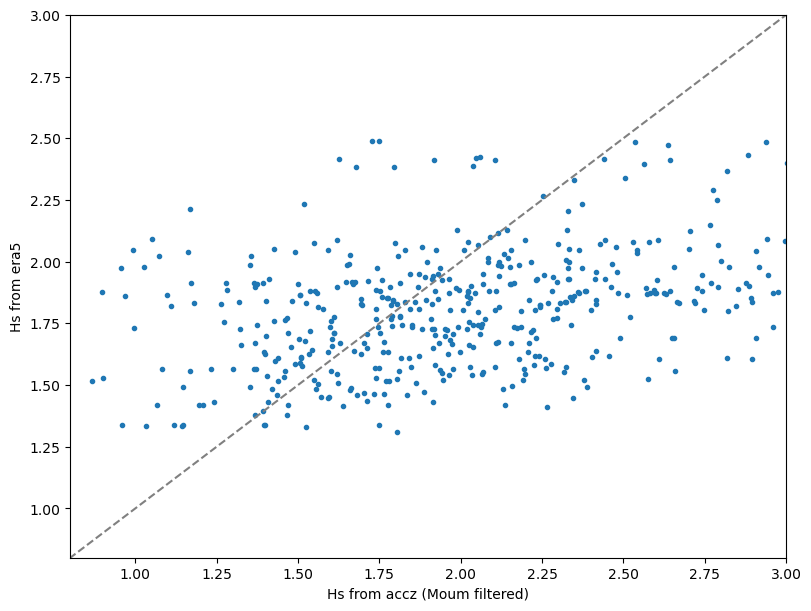

In [128]:
# plt.plot(Hs_df['Hs_band'], Hs_df['era5_swh'],'.',color='tab:blue')
fig = plt.figure(figsize=(8,6), constrained_layout=True)
plt.plot(Hs_df_dmean['Hs_dmean1'], Hs_df_dmean['Hs0'],'.',color='tab:blue')
# plt.colorbar()
plt.plot([0,3],[0,3],'--',color = 'grey')
plt.xlim(0.8,3)
plt.ylim(0.8,3)
plt.xlabel('Hs from accz (Moum filtered)')
plt.ylabel('Hs from era5')

In [246]:
swot_df = pd.read_csv('~/work/OBS/SWOT/swot_swh_timeseries.csv')
swot_df['time'] = pd.to_datetime(swot_df['time'])

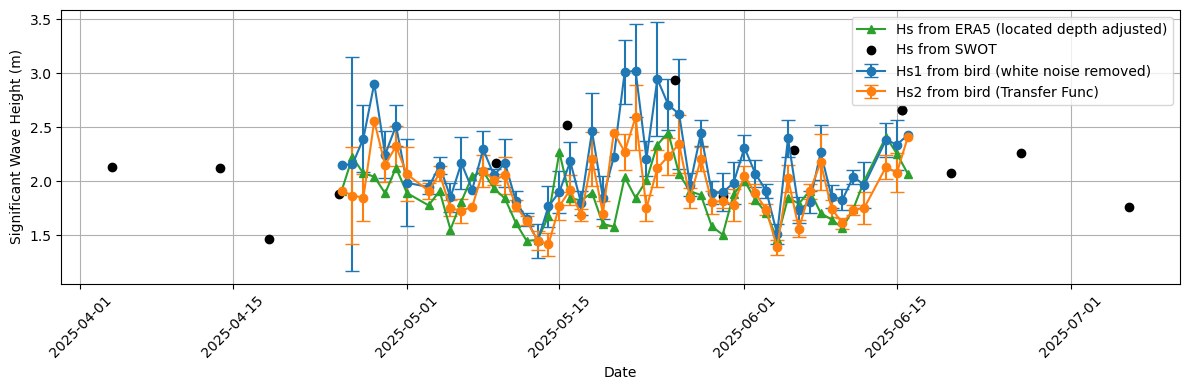

In [247]:
# Convert time to date for grouping
Hs_df_dmean['date'] = Hs_df_dmean['time'].dt.date

# Group by date and calculate daily averages
daily_avg_dmean = Hs_df_dmean.groupby('date').agg({
    'Hs': 'mean',
    'Hs_dmean1': 'mean',
    'Hs0': 'mean',  # Uncomment if you have Hs0 in your DataFrame
    'era5_swh': 'mean',
    'era5_wmp': 'mean',
    'era5_mwd': 'mean',
    'lon': 'mean',
    'lat': 'mean',
    # 'depth': 'mean'
}).reset_index()
# Calculate standard deviation (variance) for each day
# daily_variance = Hs_df_dmean.groupby('date').agg({
#     'Hs': 'std',
#     'Hs_dmean1':'std',
#     'Hs0': 'std',  # Uncomment if you have Hs0 in your DataFrame
#     'era5_swh': 'std'
# }).reset_index()

daily_variance = Hs_df_dmean.groupby('date').agg({
    'Hs': 'sem',
    'Hs_dmean1':'sem',
    'Hs0': 'sem', 
    'era5_swh': 'sem'
}).reset_index()

# Rename columns to make it clear they are standard deviations
daily_variance = daily_variance.rename(columns={
    'Hs': 'Hs_sem',
    'Hs0': 'Hs0_sem',  # Uncomment if you have Hs0 in your DataFrame
    # 'Hs_band': 'Hs_band_std',
    # 'Hs_band2': 'Hs_band2_std',
    'Hs_dmean1': 'Hs_dmean1_sem',
    # 'Hs_interpolated': 'Hs_interpolated_std',
    # 'Hs_stepwize': 'Hs_stepwize_std',
    'era5_swh': 'era5_swh_sem'
})


# Merge the variance data with the average data
daily_avg_dmean = daily_avg_dmean.merge(daily_variance, on='date')
# Calculate number of observations per day
obs_count = Hs_df_dmean.groupby('date').size().reset_index(name='count')
daily_avg_dmean = daily_avg_dmean.merge(obs_count, on='date')

# Calculate correlation between bird-derived Hs and ERA5 Hs
# corr_hs_era5 = Hs_df['Hs_band'].corr(Hs_df['era5_swh'])
# corr_hs0_era5 = Hs_df['Hs0'].corr(Hs_df['era5_swh'])

# Plot daily averages
fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(daily_avg_dmean['date'], daily_avg_dmean['Hs_dmean1'], 
            yerr=daily_avg_dmean['Hs_dmean1_sem'], fmt='o-', label='Hs1 from bird (white noise removed)', capsize=5)

ax.errorbar(daily_avg['date'], daily_avg['Hs_moum_filtered2'], 
            yerr=daily_avg['Hs_moum_filtered2_sem'], fmt='o-', label='Hs2 from bird (Transfer Func)', capsize=5)

# ax.errorbar(daily_avg['date'], daily_avg['Hs_stepwize'], 
#             yerr=daily_avg['Hs_stepwize_std'], fmt='o-', label='Hs from bird (stepwize-filtered)', capsize=5)
# ax.plot(daily_avg['date'], daily_avg['Hs_interpolated'], 'o-', label='Hs from bird (era5-filtered)')
# ax.plot(daily_avg['date'], daily_avg['Hs0'], 's-', label='Hs from ERA5')
ax.plot(daily_avg_dmean['date'], daily_avg_dmean['Hs0'], '^-', label='Hs from ERA5 (located depth adjusted)')
# ax.plot(daily_avg_dmean['date'], daily_avg_dmean['era5_swh'], '^-', label='Hs from ERA5 (located depth adjusted)')

ax.plot(swot_df['time'], swot_df['swh_box'], 'o', label='Hs from SWOT', color='k')
# ax.plot(daily_avg['date'], daily_avg['era5_swh'], 'o-', label='Hs from ERA5 (raw)', color='tab:red')
# ax.plot(daily_avg['date'], daily_avg['Hs0'], '^-', label='Hs adjusted for depth')

# Add count as text above each point
# for i, row in daily_avg.iterrows():
#     ax.annotate(f"n={row['count']}", 
#                 (row['date'], max(row['Hs_moum_filtered1'], row['Hs_moum_filtered1'])+0.1), 
#                 ha='center')

ax.set_xlabel('Date')
ax.set_ylabel('Significant Wave Height (m)')
# ax.set_title(f'Daily Average Significant Wave Height\nCorrelation: {corr_hs_era5:.2f} (raw), {corr_hs0_era5:.2f} (depth-adjusted)')
ax.legend()
ax.grid(True)

# Rotate date labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
# plt.ylim(0,5)

Text(0.5, 1.0, 'Correlation: 0.63')

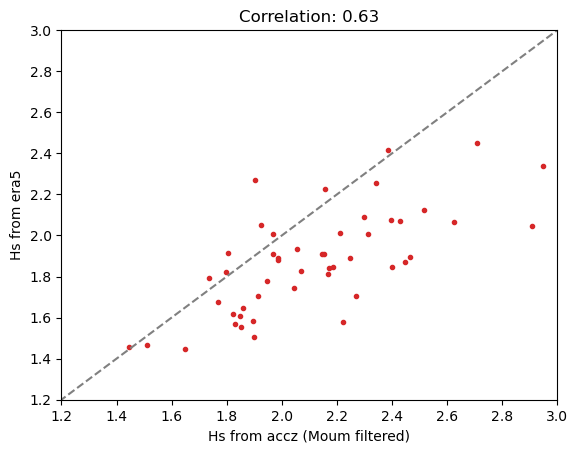

In [156]:
plt.plot(daily_avg_dmean['Hs_dmean1'], daily_avg_dmean['Hs0'],'.',color='tab:red')
# plt.plot(daily_avg['Hs_moum_filtered2'], daily_avg['Hs0'],'.',color='tab:blue',label='Hs from accz transfer function (band-filtered)')
# plt.plot(daily_avg['Hs_moum_filtered2'], daily_avg['Hs0'],'.',color='tab:red',label='Hs from ERA5 (transfer function and Rot)')
# plt.plot(daily_avg['Hs_moum_filtered2'], daily_avg['era5_swh'],'.',color='tab:orange')
plt.plot([1,3],[1,3],'--',color = 'grey')
plt.xlim(1.2,3)
plt.ylim(1.2,3)
# plt.legend()
plt.xlabel('Hs from accz (Moum filtered)')
plt.ylabel('Hs from era5')
cc001 = np.corrcoef(daily_avg_dmean['Hs_dmean1'], daily_avg_dmean['Hs0'])
plt.title(f'Correlation: {cc001[0, 1]:.2f}')

Text(0.5, 1.0, 'Correlation: 0.49')

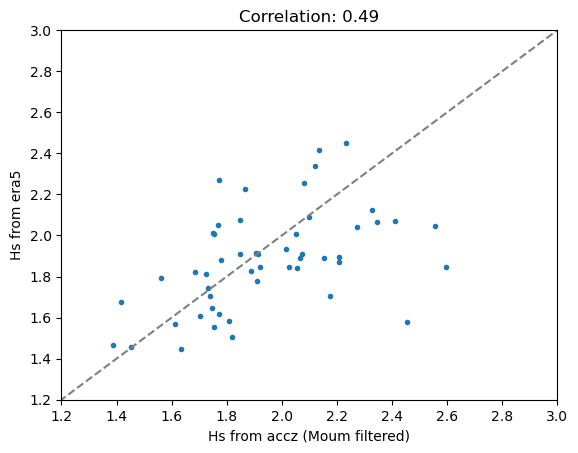

In [157]:
# plt.plot(daily_avg_dmean['Hs_dmean1'], daily_avg_dmean['Hs0'],'.',color='tab:red')
plt.plot(daily_avg['Hs_moum_filtered2'], daily_avg['Hs0'],'.',color='tab:blue',label='Hs from accz transfer function (band-filtered)')
# plt.plot(daily_avg['Hs_moum_filtered2'], daily_avg['Hs0'],'.',color='tab:red',label='Hs from ERA5 (transfer function and Rot)')
# plt.plot(daily_avg['Hs_moum_filtered2'], daily_avg['era5_swh'],'.',color='tab:orange')
plt.plot([1,3],[1,3],'--',color = 'grey')
plt.xlim(1.2,3)
plt.ylim(1.2,3)
# plt.legend()
plt.xlabel('Hs from accz (Moum filtered)')
plt.ylabel('Hs from era5')
# cc001 = np.corrcoef(daily_avg_dmean['Hs_dmean1'], daily_avg_dmean['Hs0'])
cc001 = np.corrcoef(daily_avg['Hs_moum_filtered2'], daily_avg['Hs0'])
plt.title(f'Correlation: {cc001[0, 1]:.2f}')

## sensitivity of the white floor

/tmp/ipykernel_375203/2441908056.py:41: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_375203/2441908056.py:43: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_rot = Pxx_accz_rot/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_375203/2441908056.py:50: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_375203/2441908056.py:52: RuntimeWarning: divide by zero encountered in divide
  Pxx_z_eta_mean_power_low = Pxx_accz_mean_power_low/(2*np.pi*f_accz_detrend)**4
/tmp/ipykernel_375203/2441908056.py:54: RuntimeWarning: invalid value encountered in subtract
  Pxx_z_eta_dmean_power_low = Pxx_z_eta_rot - Pxx_z_eta_mean_power_low
/tmp/ipykernel_375203/2441908056.py:68: RuntimeWarning: divide by zero encountered in divide
  nc1_elev = nc1/(2*np.pi*f_accz_rot)**4
/tmp/ipykernel_375203/2441908056.py:69: RuntimeWarning:

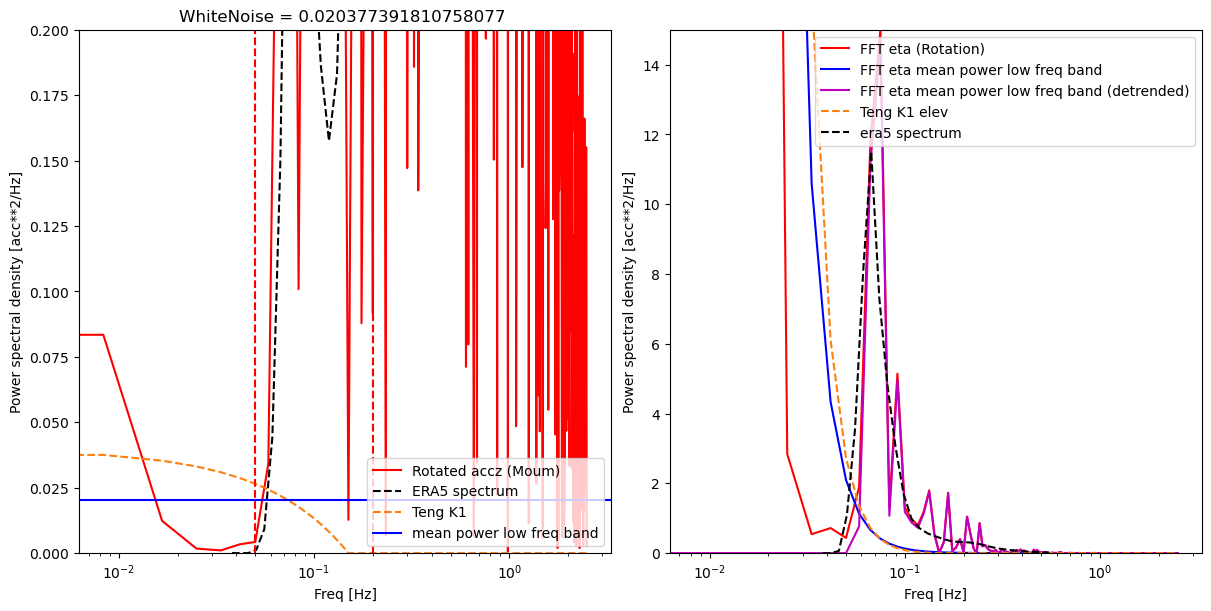

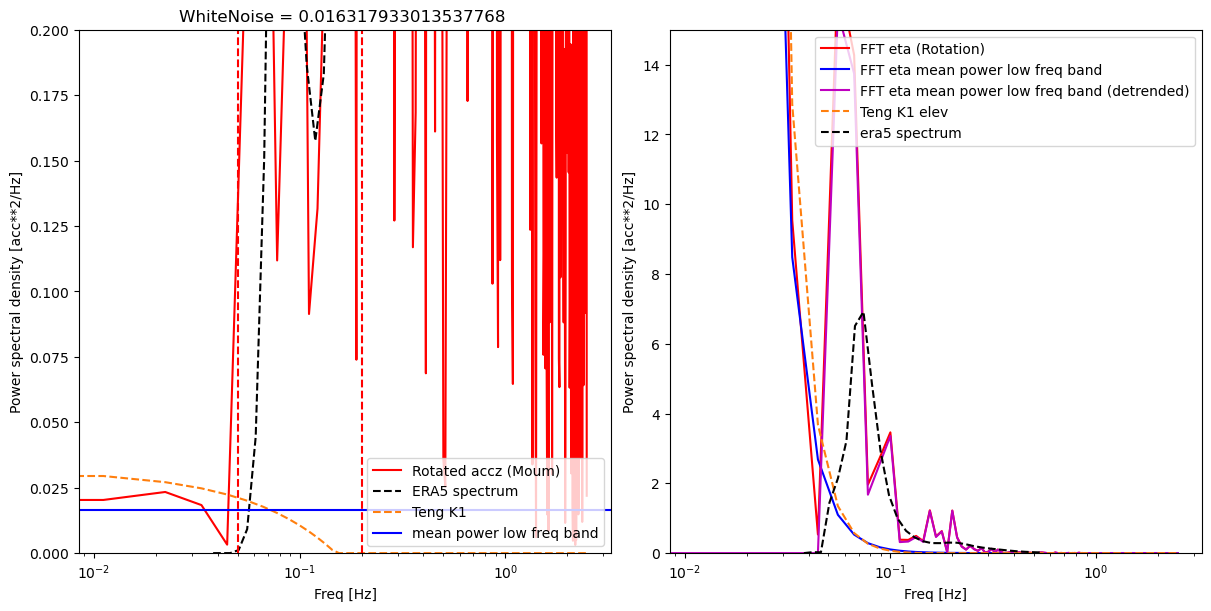

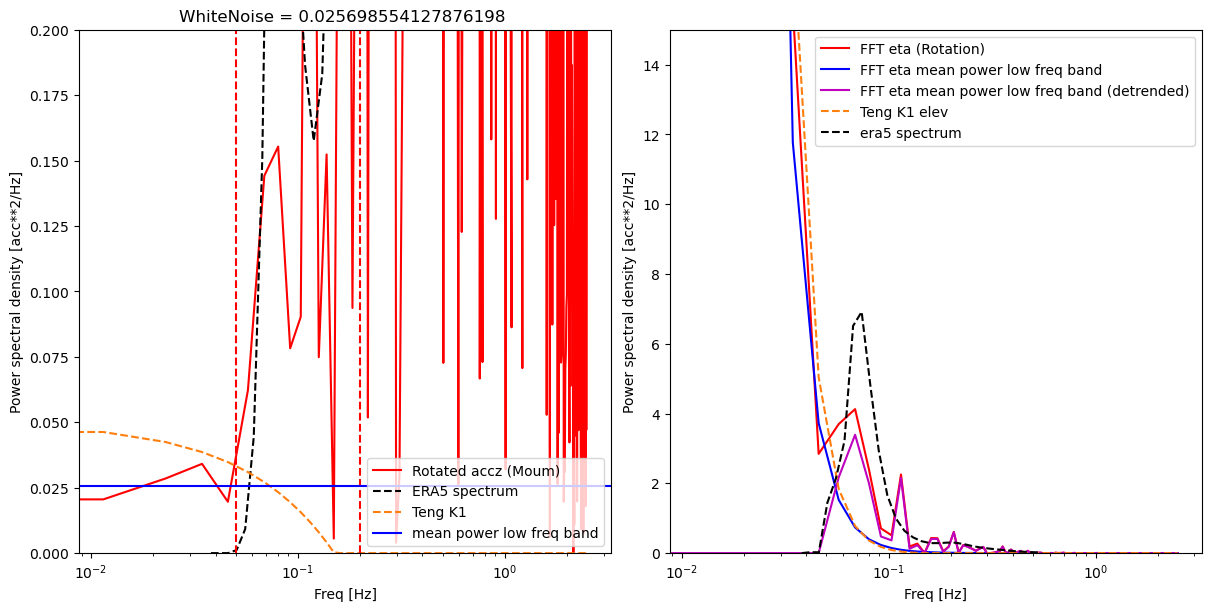

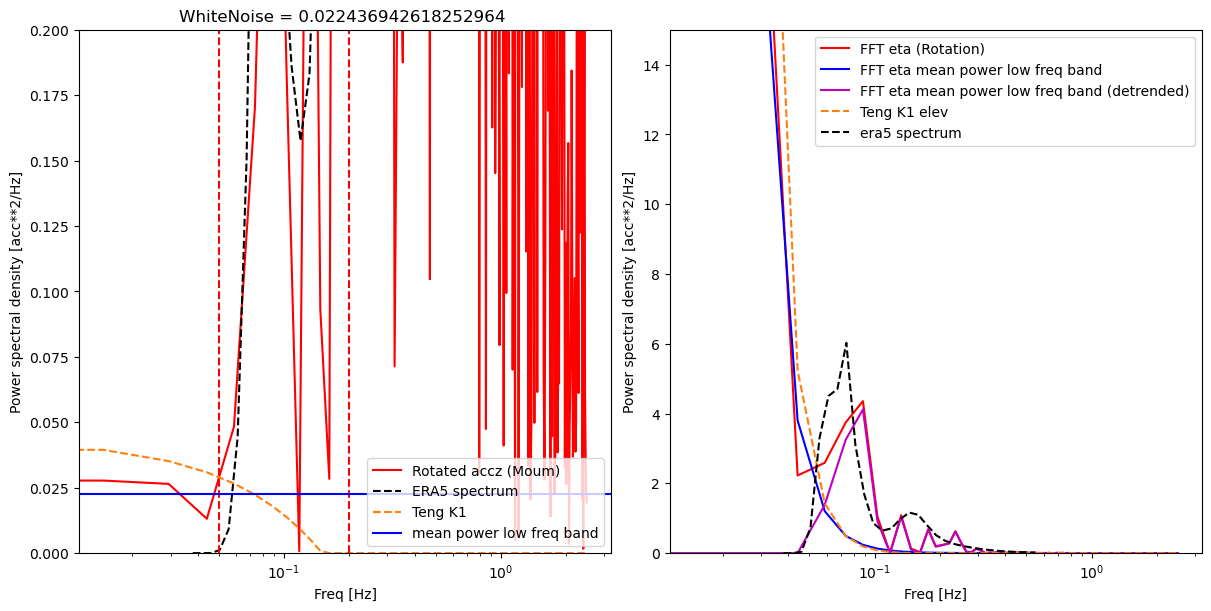

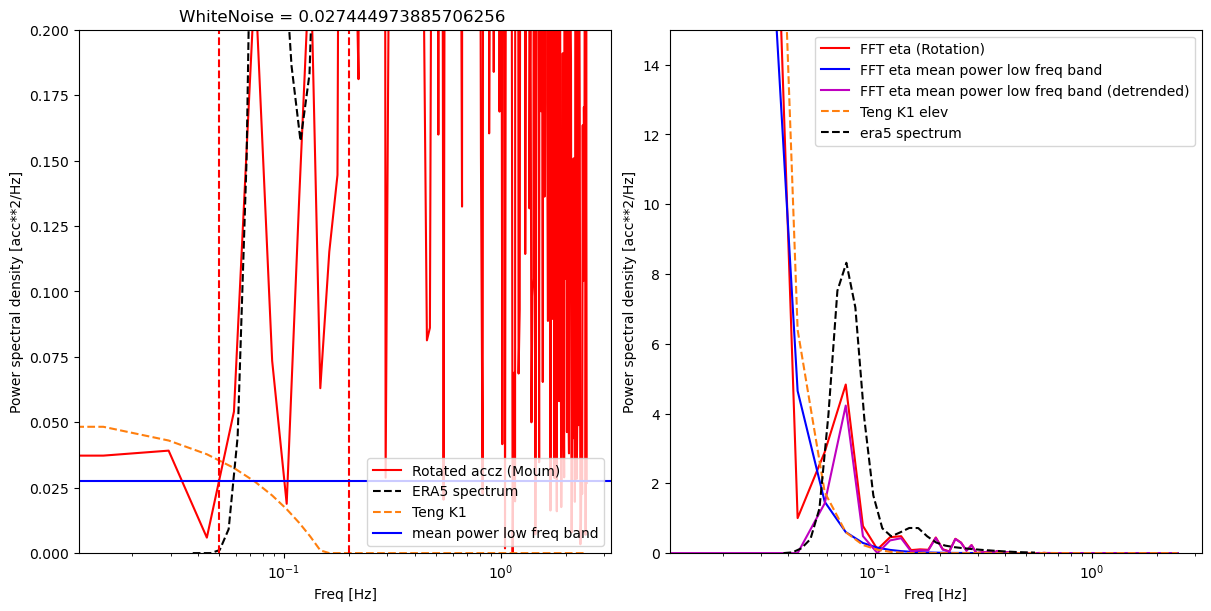

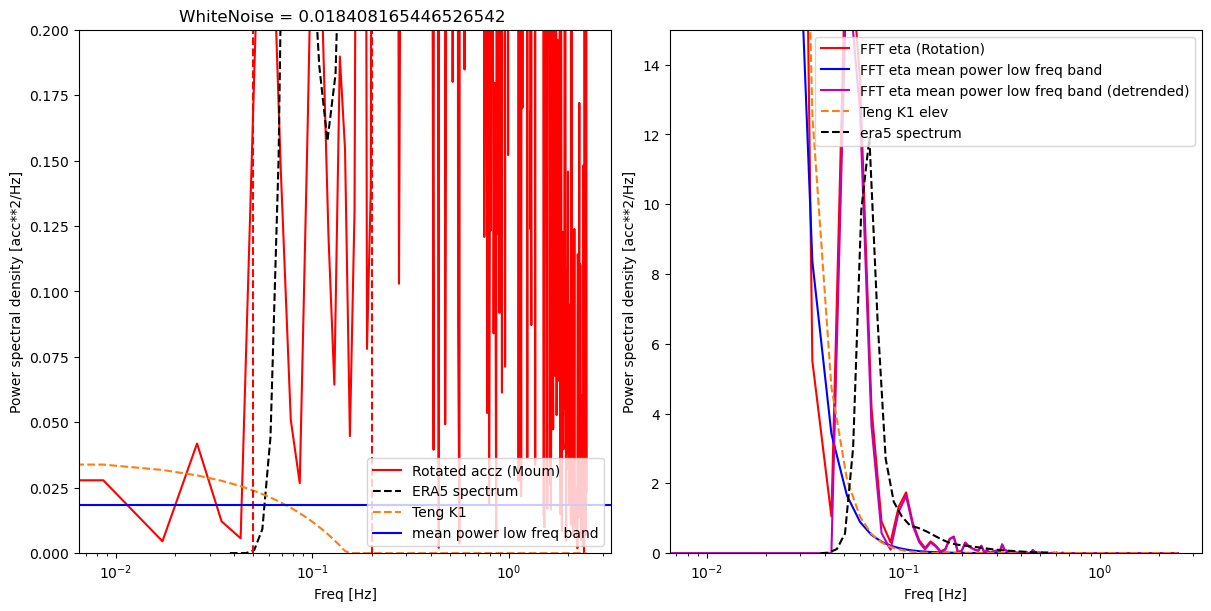

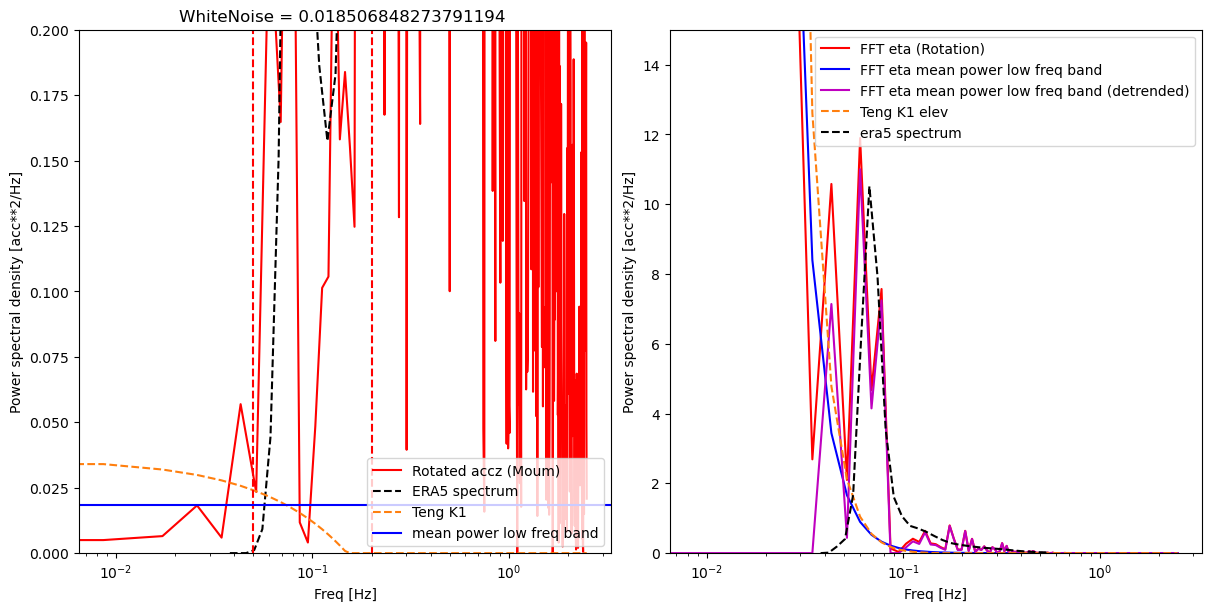

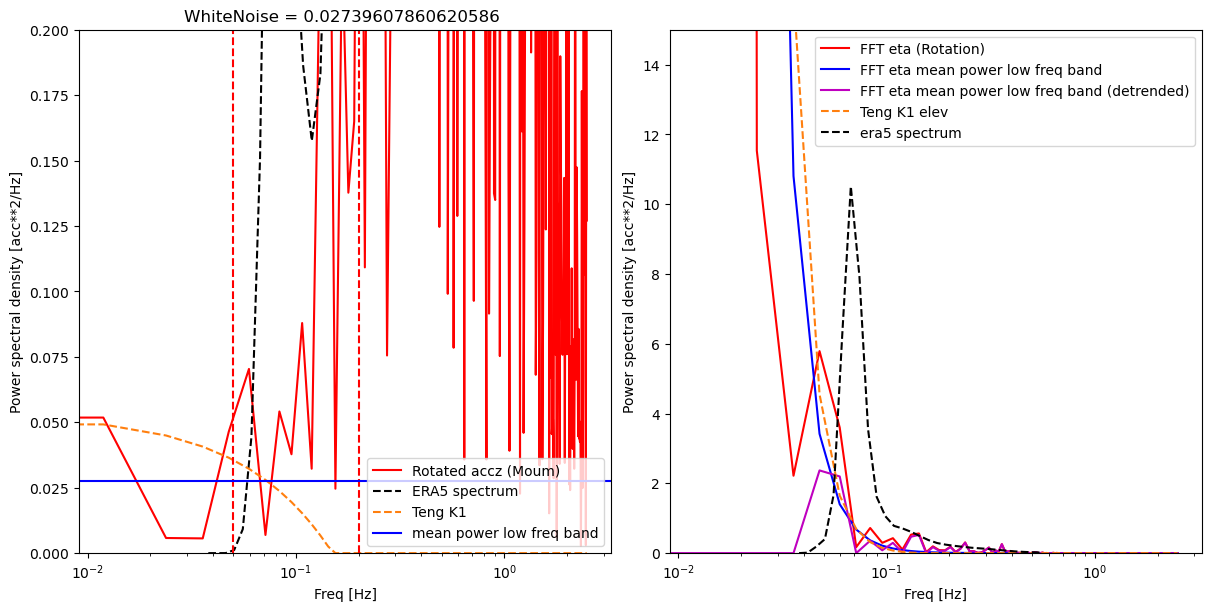

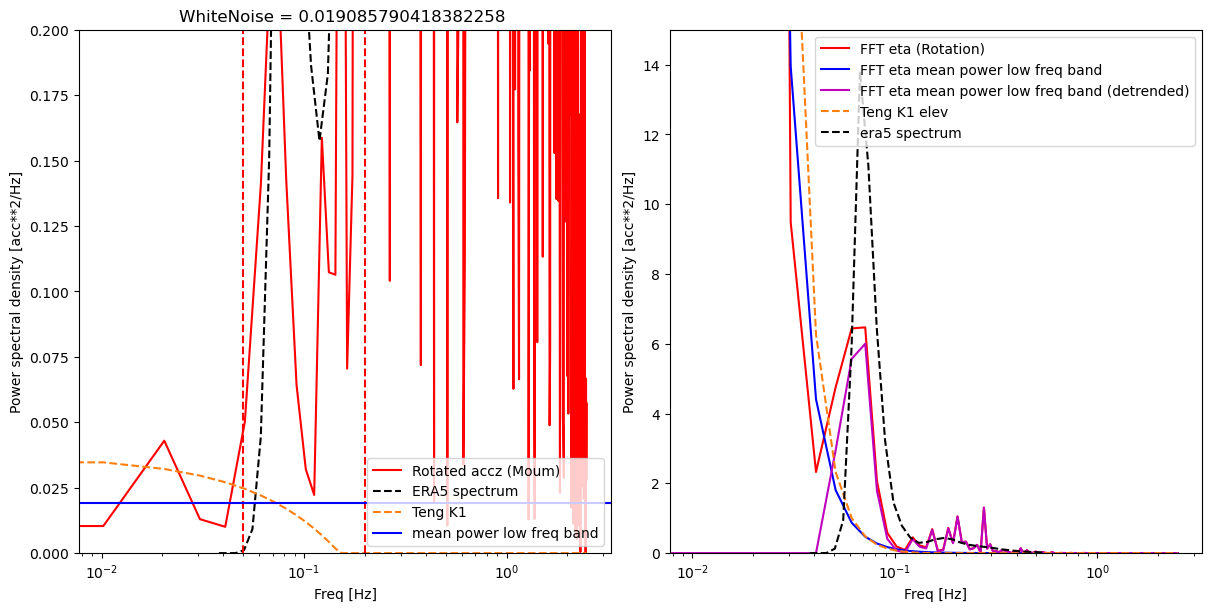

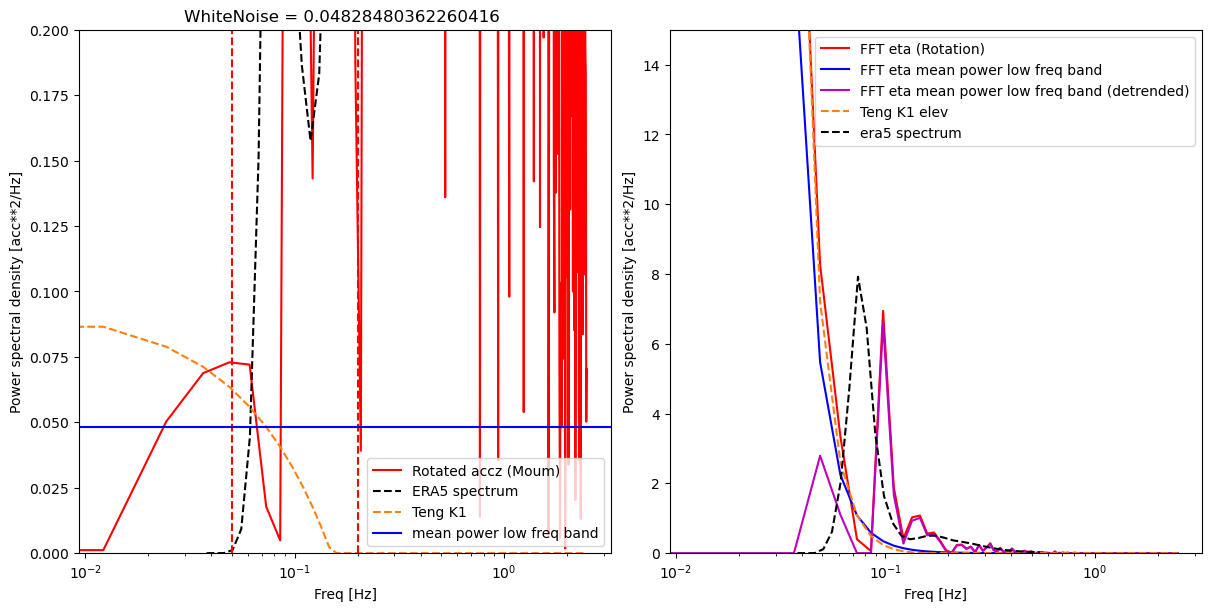

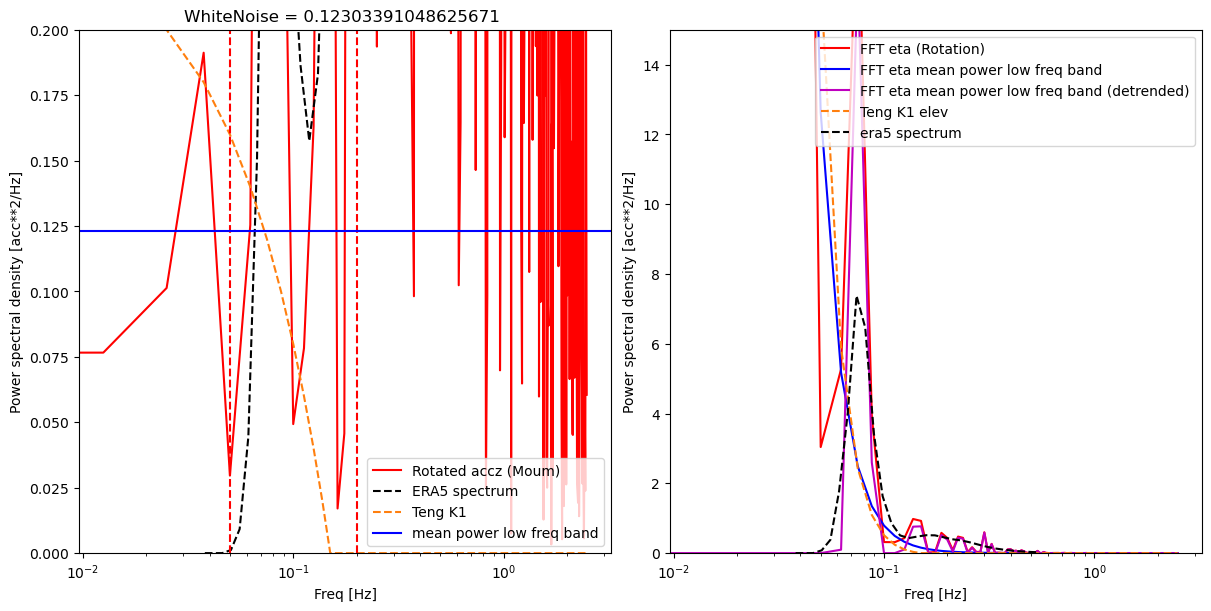

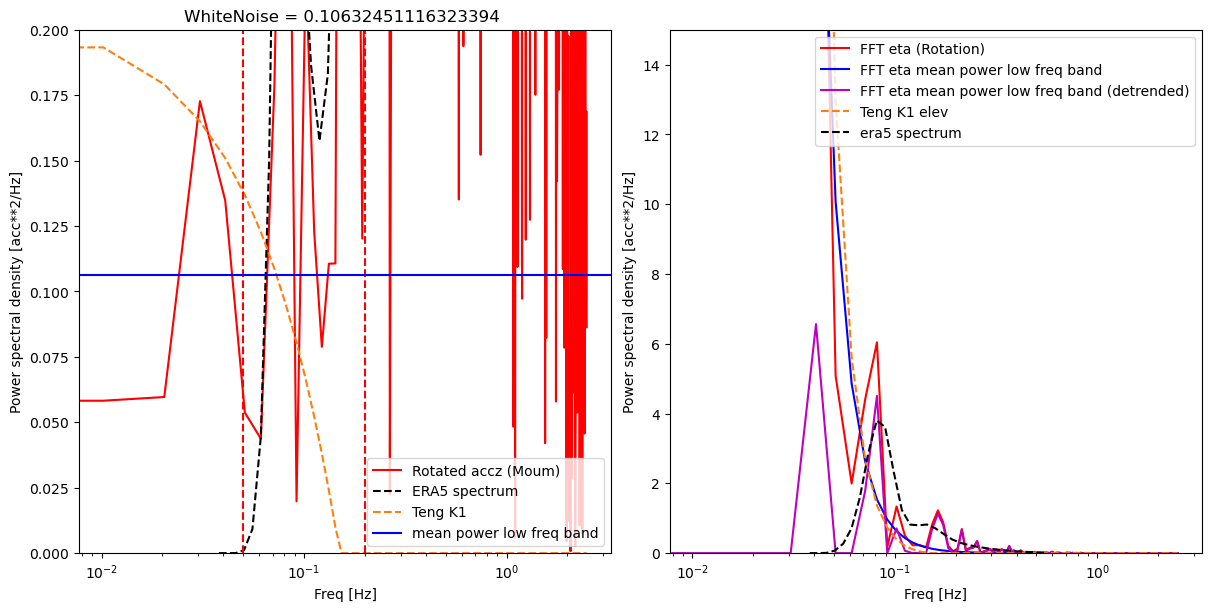

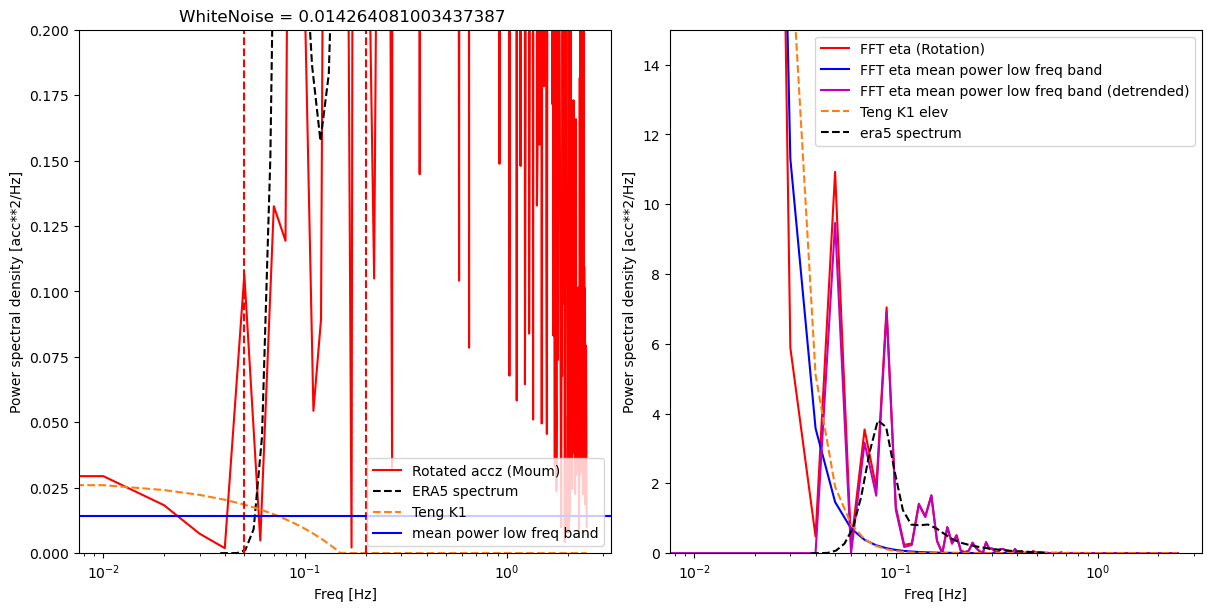

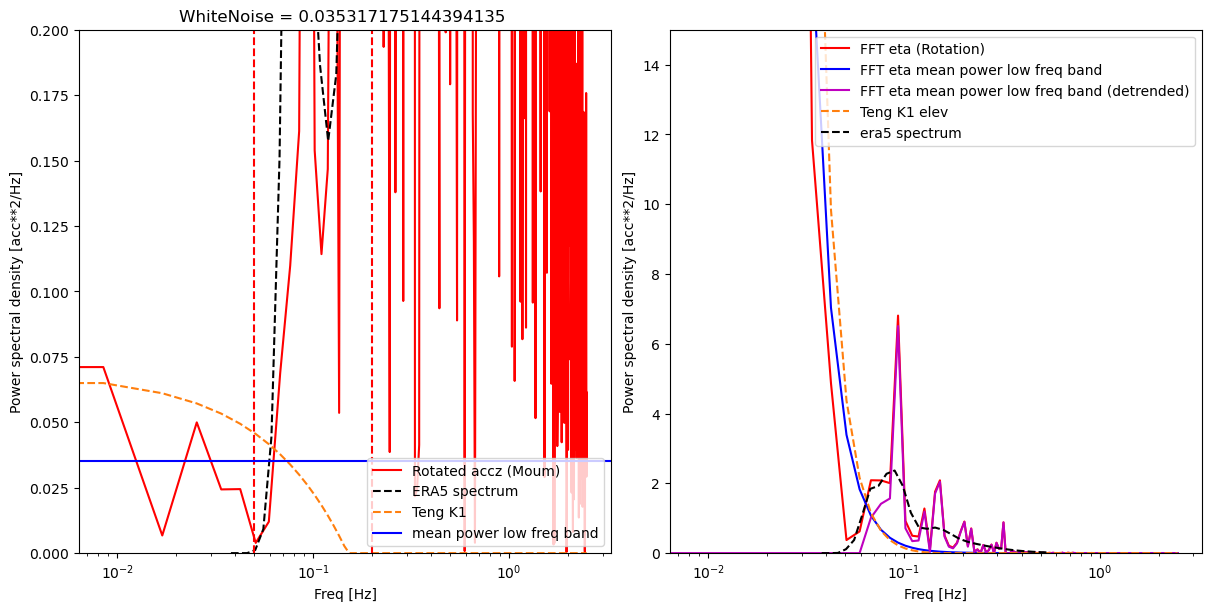

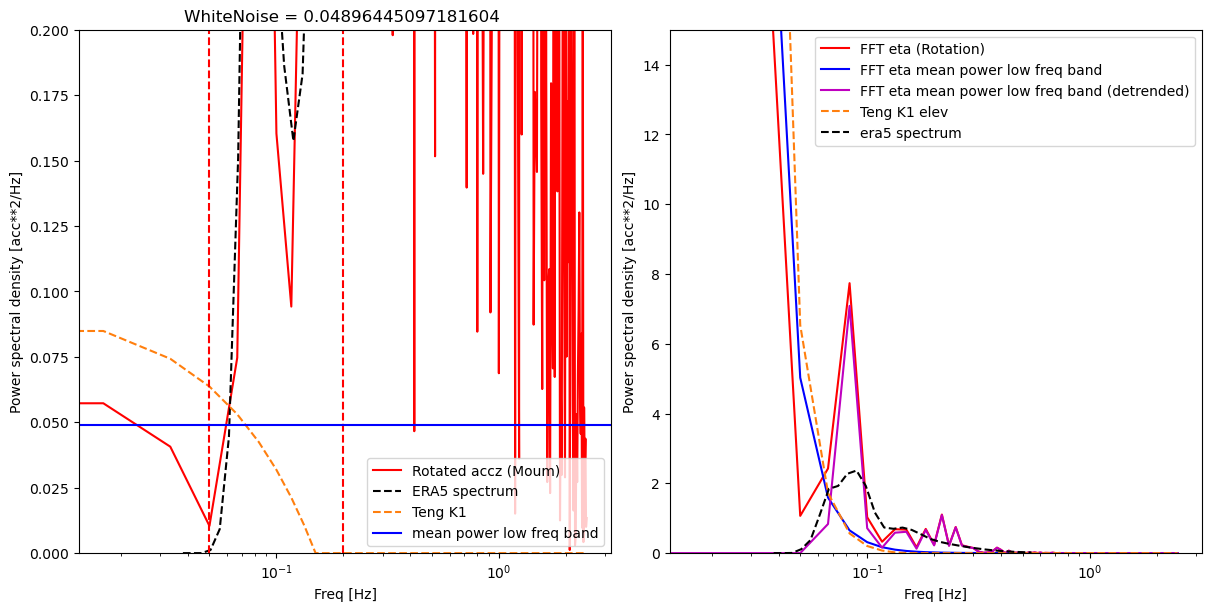

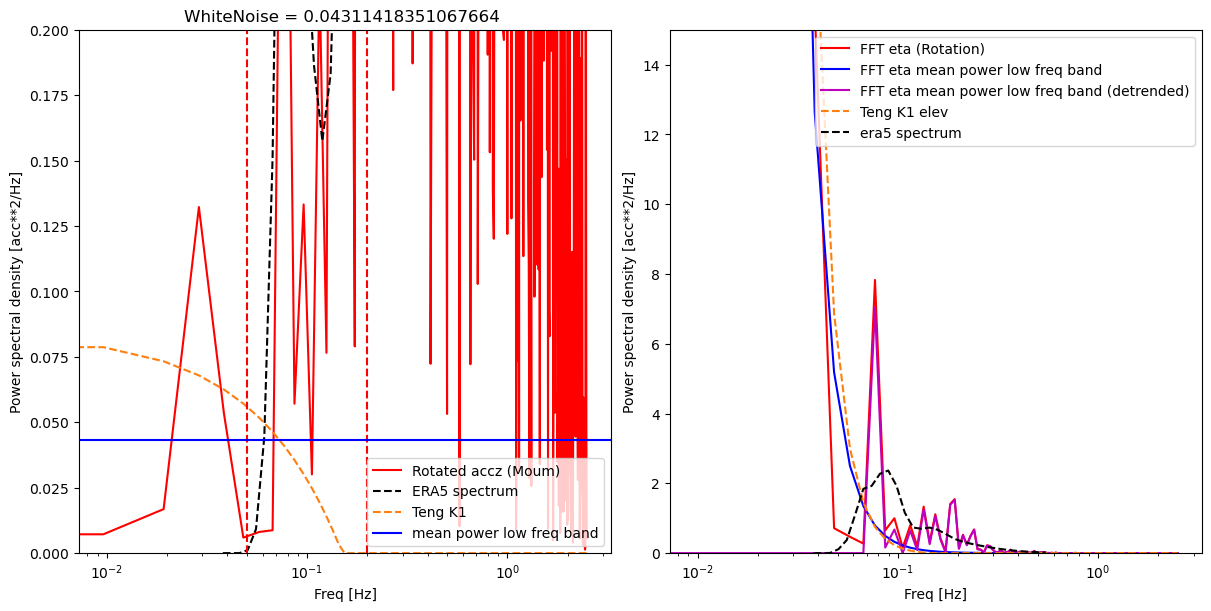

In [257]:
plt_flg = 1

grav0 = 9.81  # m/s^2
# swh_era5_1pt = era5_wave.isel(longitude=3, latitude=4)
# swh_era5_1pt2 = era5_wave.isel(longitude=4, latitude=5)
swh_era5_2 = era5_wave2.isel(longitude=2, latitude=3)
swh_era5_3 = era5_wave3.isel(longitude=4, latitude=6)

# from scipy.signal import welch
sample_rate = 5
order=4
icount=0
for i in rec_list2_ok[0:16]:  ##### MUST START FROM 0
    chunk00 = data_40s_df[data_40s_df["chunk_id"]==i]

    # if (np.max(chunk00['accz'].values)<1500)&(np.min(chunk00['accz'].values)>500):
    # accz_1 = chunk00["accz"].values/1000*9.81
    # accx_1 = chunk00["accx"].values/1000*9.81
    # accy_1 = chunk00["accy"].values/1000*9.81
    accz_1_sub = chunk00['accz'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accx_1_sub = chunk00['accx'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    accy_1_sub = chunk00['accy'].values[rec_list2_ok_start[icount]:rec_list2_ok_end[icount]]/1000*9.81
    
    accz_wave = accz_1_sub - grav0*np.sqrt(1-(accx_1_sub/grav0)**2 - (accy_1_sub/grav0)**2)

    f_accz_detrend, Pxx_accz_detrend = power_spectral_density_fft(signal.detrend(accz_1_sub))
    # f_accx_detrend, Pxx_accx_detrend = power_spectral_density_fft(signal.detrend(accx_1_sub))
    # f_accy_detrend, Pxx_accy_detrend = power_spectral_density_fft(signal.detrend(accy_1_sub))

    f_accz_rot, Pxx_accz_rot = power_spectral_density_fft(signal.detrend(accz_wave)) #(rotation based on Moum et al. 2023)

    # Calculate low frequency components (f < 0.05 Hz) for Moum's method
    f_low_indices = np.where(f_accz_rot < 0.05)[0]
    Pxx_accz_rot_low = Pxx_accz_rot[f_low_indices]
    f_accz_rot_low = f_accz_rot[f_low_indices]

    # Calculate mean power in the low frequency band
    mean_power_low = np.mean(Pxx_accz_rot_low[1:])
    max_power_low = np.max(Pxx_accz_rot_low[1:])

    Pxx_z_eta_d = Pxx_accz_detrend/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_d = np.where(f_accz_detrend>0, Pxx_z_eta_d, 0)
    Pxx_z_eta_rot = Pxx_accz_rot/(2*np.pi*f_accz_detrend)**4
    Pxx_z_eta_rot = np.where(Pxx_z_eta_rot>0, Pxx_z_eta_rot, 0)
    # transfunc = (1-1/(1+(f_accz_detrend/(1/27))**4))**6  # transfer function for 23s filter (Moum et al. 2023)
    # Pxx_z_eta_d_filtered1 = Pxx_z_eta_d * transfunc
    # Pxx_z_eta_d_filtered2 = Pxx_z_eta_moum * transfunc

    Pxx_accz_whitenoise = Pxx_accz_detrend*0+ 0.1
    Pxx_z_eta_whitenoise = Pxx_accz_whitenoise/(2*np.pi*f_accz_detrend)**4
    Pxx_accz_mean_power_low = Pxx_accz_detrend*0+ mean_power_low
    Pxx_z_eta_mean_power_low = Pxx_accz_mean_power_low/(2*np.pi*f_accz_detrend)**4

    Pxx_z_eta_dmean_power_low = Pxx_z_eta_rot - Pxx_z_eta_mean_power_low
    Pxx_z_eta_dmean_power_low = np.where(Pxx_z_eta_dmean_power_low>0, Pxx_z_eta_dmean_power_low, 0)
    Pxx_z_eta_dmean_power_low = np.where(f_accz_rot>0.04, Pxx_z_eta_dmean_power_low, 0)


    K1 = 13 * mean_power_low
    K2 = 18 * mean_power_low
    f_c = 0.15

    fc_lower = np.where(f_accz_rot < f_c)[0]
    nc1 = np.zeros_like(f_accz_rot)
    nc2 = np.zeros_like(f_accz_rot)
    nc1[fc_lower] = K1*(f_c-f_accz_rot[fc_lower])
    nc2[fc_lower] = K2*(f_c-f_accz_rot[fc_lower])
    nc1_elev = nc1/(2*np.pi*f_accz_rot)**4
    nc2_elev = nc2/(2*np.pi*f_accz_rot)**4
    # Pxx_z_eta_d

    mwp_chunk = swh_era5_3.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwp.values
    swh_chunk = swh_era5_3.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').swh.values
    mwd_chunk = swh_era5_3.sel(valid_time = chunk00.iloc[0].original_time,method='nearest').mwd.values

    # # spectrum_chunk = era5_peru_mean.sel(time=chunk00.iloc[0].original_time,method='nearest')
    spectrum_chunk = era5_wave_spectrum_sum_1pt.sel(time=chunk00.iloc[0].original_time,method='nearest')    
    spectrum_chunk_interpolated = spectrum_chunk.interp(frequency=f_accz_detrend, method='linear')

    if icount == 0:
        PSD_acc = [Pxx_accz_detrend]
        f_accz_all = [f_accz_detrend]
        PSD_eta = [Pxx_z_eta_d]
        PSD_eta_wave_all = [Pxx_z_eta_rot]
        PSD_eta_dmean_power_low =[Pxx_z_eta_dmean_power_low]
        # PSD_eta_moum_filtered1_all = [Pxx_z_eta_d_filtered1]
        # PSD_eta_moum_filtered2_all = [Pxx_z_eta_d_filtered2]
        t_april = [chunk00['original_time'].iloc[0]]
        x_april = [chunk00['lon'].iloc[0]]
        y_april = [chunk00['lat'].iloc[0]]
        mwp_all = [mwp_chunk]
        swh_all = [swh_chunk]
        mwd_all = [mwd_chunk]
        chunk_id_all = [i]
    else:
        PSD_acc.append(Pxx_accz_detrend)
        f_accz_all.append(f_accz_detrend)
        PSD_eta.append(Pxx_z_eta_d)
        PSD_eta_wave_all.append(Pxx_z_eta_rot)
        PSD_eta_dmean_power_low.append(Pxx_z_eta_dmean_power_low)
        # PSD_eta_moum_filtered1_all.append(Pxx_z_eta_d_filtered1)
        # PSD_eta_moum_filtered2_all.append(Pxx_z_eta_d_filtered2)
        t_april.append(chunk00['original_time'].iloc[0])
        x_april.append(chunk00['lon'].iloc[0])
        y_april.append(chunk00['lat'].iloc[0])
        mwp_all.append(mwp_chunk)
        swh_all.append(swh_chunk)
        mwd_all.append(mwd_chunk)
        chunk_id_all.append(i)
    icount += 1
    if plt_flg == 1:
        fig = plt.figure(figsize=(12,6),constrained_layout=True)

        gs = fig.add_gridspec(1, 2, width_ratios=[1,1])
        # axs1 = fig.add_subplot(gs[0,0])
        axs2 = fig.add_subplot(gs[0,0])
        axs3 = fig.add_subplot(gs[0,1])
        # axs1.plot(np.arange(len(accz_1_sub))/5,accz_1_sub-9.81,label = 'RAW accz-g')
        # axs1.plot(np.arange(len(accz_wave))/5,accz_wave,label = 'acc wave')
        # axs1.plot(np.arange(len(accz_wave))/5,accz_1_sub-9.81-accz_wave,label = 'RAW_accz-acc_wave')
        # axs1.set_xlabel('Time [s]')
        # axs1.set_ylabel('accz [m/s^2]')
        # axs1.legend()
        # axs1.set_title(f'chunk_id={i}accz_time={chunk00["original_time"].values[0]}')

        # axs2.plot(f_accz, Pxx_accz,label='Rotated accz (FFT)')
        # axs2.plot(f_accz_detrend, Pxx_accz_detrend,'b',label='Non-rot accz (FFT)')
        # axs2.plot(f_accz_ro0, Pxx_accz_ro0,'r',label='Non-rot accz (FFT rotated)')
        # axs2.plot(f_accz_detrend, Pxx_accz_whitenoise,'g',label='whitenoise accz (FFT) = 0.1')
        axs2.plot(f_accz_rot, Pxx_accz_rot,'r',label='Rotated accz (Moum)')
        axs2.plot(acc_spectrum_era5.frequency, acc_spectrum_era5,'--',color='k',label='ERA5 spectrum')
        axs2.plot(f_accz_rot, nc1,'--',color='tab:orange',label='Teng K1')
        # axs2.plot(f_accz_fft[1:], Pxx_accz_fft[1:],label='RAW accz (fft)')
        # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
        axs2.axvline(x=0.05, color='r', linestyle='--')
        axs2.axvline(x=0.2, color='r', linestyle='--')
        axs2.axhline(y=mean_power_low, color='b', label='mean power low freq band')
        # axs2.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
        # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
        axs2.set_xscale('log')
        axs2.set_xlabel('Freq [Hz]')
        axs2.set_ylabel('Power spectral density [acc**2/Hz]')
        axs2.set_title(f'WhiteNoise = {mean_power_low} ')
        # axs2.set_ylim(1e-4,10)
        axs2.set_ylim(0,0.2)
        # axs2.set_yscale('log')
        axs2.legend(loc='lower right')
        # axs22 = axs2.twinx()
        # axs2.plot(da.frequency, mean_power[0].values*(2*np.pi*da.frequency)**4,color = 'g',label='mean_power')
        # To set the color of the tick labels, we need to get the current labels first
        # axs22.tick_params(axis='y', colors='orange')  # This sets the color of the tick marks and labels

        # axs3.plot(f_accz, Pxx_z_eta,label='PSD eta')
        # axs3.plot(f_accz_detrend, Pxx_z_eta_d,label='FFT eta')
        axs3.plot(f_accz_rot, Pxx_z_eta_rot,'r',label='FFT eta (Rotation)')
        # axs3.plot(f_accz_detrend, Pxx_z_eta_d_filtered1,'g',label='FFT eta (transfer function')
        # axs3.plot(f_accz_detrend, Pxx_z_eta_d_filtered2,'b',label='FFT eta (Rotation+transfunc)')
        # axs3.plot(f_accz_ro0, Pxx_z_eta_ro0,'r',label='FFT eta rotated')
        # axs3.plot(f_accz_detrend, Pxx_z_eta_whitenoise,'g',label='FFT eta whitenoise')
        axs3.plot(f_accz_detrend, Pxx_z_eta_mean_power_low,'b',label='FFT eta mean power low freq band')
        axs3.plot(f_accz_detrend, Pxx_z_eta_dmean_power_low,'m',label='FFT eta mean power low freq band (detrended)')
        axs3.plot(f_accz_rot, nc1_elev,'--',color='tab:orange',label='Teng K1 elev')
        # # axs3.plot(f_accx, Pxx_accx,label='RAW accx')
        # # axs3.plot(f_accy, Pxx_accy,label='RAW accy')
        # # axs2.plot(f_welch, pxx_welch+0.2,label='welch')
        # axs3.axvline(x=0.05, color='r', linestyle='--')
        # axs3.axvline(x=0.2, color='r', linestyle='--')
        # # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--',linewidth=2)
        # # axs3.plot(da.frequency, mean_power[0].values,color = 'orange',label='mean_power')
        axs3.plot(spectrum_chunk.frequency, spectrum_chunk,'--',color='k',label='era5 spectrum')
        # axs3.plot(f_accz_detrend, spectrum_chunk_interpolated_normolized*Pxx_z_eta_ro0,'g',label='FFT eta (era5 spectrum filtered)')
        # axs3.plot(f_accz_detrend, spectrum_chunk_interpolated_stepwize,'c',label='Filter (era5 spectrum filtered)')
        # axs3.plot(f_accz_detrend, PSD_eta_ro0_stepwize,'m',label='FFT eta (era5 spectrum stepwize filtered)')
        # # axs3.axvline(x=1/mwp_chunk, color='g', linestyle='--', label='mwp',linewidth=2)
        # # axs3.axhline(y=swh_chunk**2, color='b', linestyle='--', label='swh',linewidth=2)
        # # axs2.plot(f_accz_butt_1s, Pxx_accz_butt_1s/(2*np.pi*f_accz_butt_1s)**4,label='butt_2s filtered')
        axs3.set_xscale('log') 
        axs3.set_xlabel('Freq [Hz]')
        axs3.set_ylabel('Power spectral density [acc**2/Hz]')
        # axs3.set_yscale('log')
        axs3.set_ylim(0,15)
        axs3.legend(loc='upper right')
        # fig.savefig(f'chunk_frequency_100s_all_tags_v4/add_moum_06/chunk_spectrum_accz_{i}.png')
        # plt.close()

## Wind time series

In [259]:
ds_wind = xr.open_dataset('ERA5-download/data_stream-oper_stepType-instant.nc')
ds_wind

<xarray.Dataset>
Dimensions:     (valid_time: 2184, latitude: 21, longitude: 17)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2025-04-01 ... 2025-06-30T23:00:00
  * latitude    (latitude) float64 -5.0 -5.25 -5.5 -5.75 ... -9.5 -9.75 -10.0
  * longitude   (longitude) float64 -82.0 -81.75 -81.5 ... -78.5 -78.25 -78.0
    expver      (valid_time) object ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 ...
    v10         (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-20T22:09 GRIB to CDM+CF via cfgrib-0.9.1...

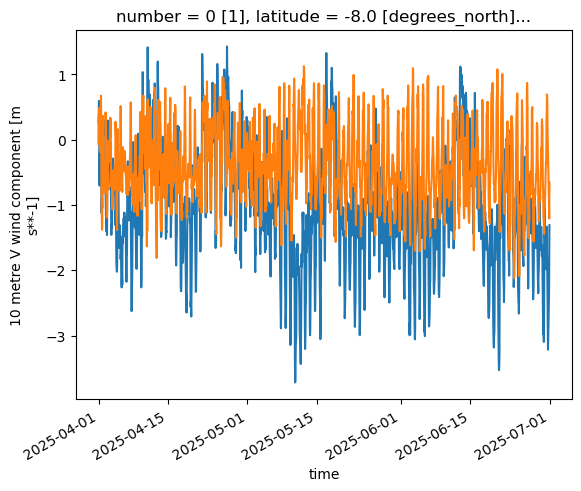

In [262]:
ds_wind.u10.sel(latitude=-8, longitude=-78).plot(label='u10')
ds_wind.v10.sel(latitude=-8, longitude=-78).plot(label='v10')

(20209.0, 20256.0)

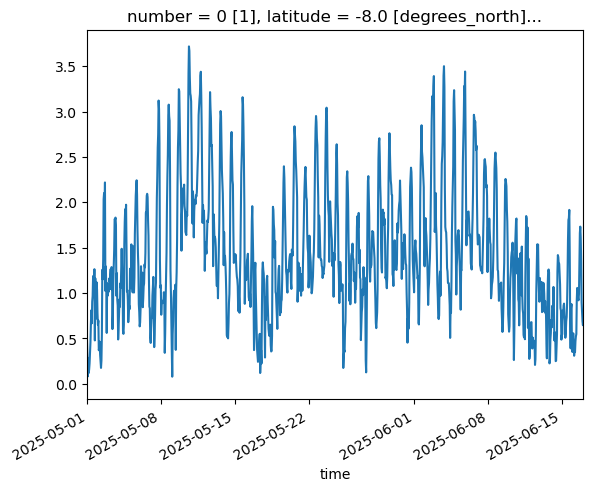

In [268]:
wspd = np.sqrt(ds_wind.u10**2 + ds_wind.v10**2)
wspd.sel(latitude=-8, longitude=-78).plot(label='Wind Speed')
plt.xlim(pd.to_datetime('2025-05-01'), pd.to_datetime('2025-06-17'))

Mean wind speed: 1.36 m/s
Maximum wind speed: 2.43 m/s
Minimum wind speed: 0.53 m/s


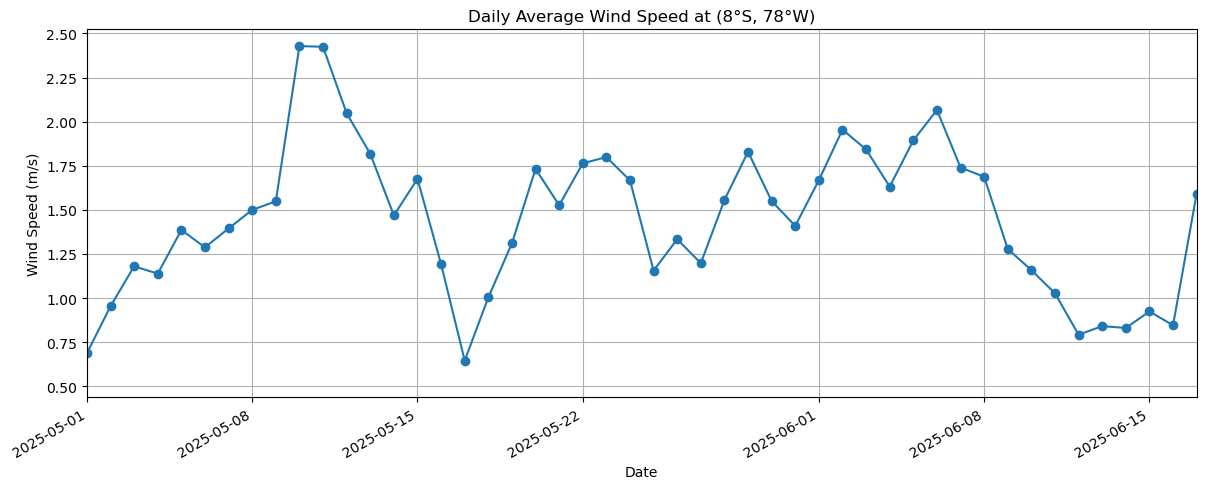

In [267]:
# Calculate daily average wind speed at a specific location (-8, -78)
wspd_location = wspd.sel(latitude=-8, longitude=-78)

# Calculate daily average
wspd_daily = wspd_location.resample(valid_time='1D').mean()

# Plot daily average wind speed
plt.figure(figsize=(12, 5))
wspd_daily.plot(marker='o')
plt.grid(True)
plt.title('Daily Average Wind Speed at (8°S, 78°W)')
plt.ylabel('Wind Speed (m/s)')
plt.xlabel('Date')
plt.tight_layout()
plt.xlim(pd.to_datetime('2025-05-01'), pd.to_datetime('2025-06-17'))

# Calculate overall statistics
print(f"Mean wind speed: {wspd_daily.mean().values:.2f} m/s")
print(f"Maximum wind speed: {wspd_daily.max().values:.2f} m/s")
print(f"Minimum wind speed: {wspd_daily.min().values:.2f} m/s")